# Task 3 — Gender and Usage Classification

**Status:** the fixed primary baseline has completed all five folds for both targets.
This notebook now records the model, pooled evidence, diagnosis, and next hypotheses.

**Owner:** TODO(owner)


## Colab setup — repository and teacher data

Run these cells at the start of each fresh Colab runtime. They are safe to rerun.
The repository supplies `data/processed`, including the one allowed split. The Drive
archive supplies only `data/raw/teacher`. Images are extracted to Colab's local disk
because training directly from Drive is much slower.


In [24]:
from pathlib import Path
import os
import subprocess
import sys
import zipfile

REPO_URL = "https://github.com/TrnLin/MLA2.git"
BRANCH = "task-3-gender-usage-classification"
REPO_DIR = Path("/content/MLA2")
DRIVE_MOUNT = Path("/content/drive")
DRIVE_PROJECT_DIR = DRIVE_MOUNT / "MyDrive/MLA2"
DATA_ZIP = DRIVE_PROJECT_DIR / "data/task3-data.zip"
DRIVE_TASK_DIR = DRIVE_PROJECT_DIR / "task3"


def run_checked(command, *, cwd=None):
    command = [str(part) for part in command]
    print("$", " ".join(command))
    return subprocess.run(command, cwd=cwd, check=True)


In [25]:
try:
    from google.colab import drive
except ImportError as exc:
    raise RuntimeError("This setup cell must run in Google Colab.") from exc

drive.mount(str(DRIVE_MOUNT), force_remount=False)

if (REPO_DIR / ".git").is_dir():
    remote_url = subprocess.check_output(
        ["git", "remote", "get-url", "origin"], cwd=REPO_DIR, text=True
    ).strip()
    if remote_url != REPO_URL:
        raise RuntimeError(f"{REPO_DIR} belongs to a different repository: {remote_url}")
    run_checked(["git", "fetch", "origin", BRANCH], cwd=REPO_DIR)
    run_checked(["git", "switch", BRANCH], cwd=REPO_DIR)
    dirty = subprocess.check_output(
        ["git", "status", "--porcelain"], cwd=REPO_DIR, text=True
    ).strip()
    if dirty:
        print("Local repository changes found; skipped the automatic fast-forward update.")
    else:
        run_checked(["git", "merge", "--ff-only", f"origin/{BRANCH}"], cwd=REPO_DIR)
elif REPO_DIR.exists():
    raise RuntimeError(f"{REPO_DIR} exists but is not a Git repository.")
else:
    run_checked(
        ["git", "clone", "--branch", BRANCH, "--single-branch", REPO_URL, REPO_DIR]
    )

print(f"Repository ready: {REPO_DIR} ({BRANCH})")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
$ git fetch origin task-3-gender-usage-classification
$ git switch task-3-gender-usage-classification
Local repository changes found; skipped the automatic fast-forward update.
Repository ready: /content/MLA2 (task-3-gender-usage-classification)


In [26]:
if not DATA_ZIP.is_file():
    raise FileNotFoundError(
        f"Dataset archive not found at {DATA_ZIP}. Check the Drive folder and file name."
    )

teacher_dir = REPO_DIR / "data/raw/teacher"
required_files = (
    teacher_dir / "train/styles_train.csv",
    teacher_dir / "test/styles_prediction.csv",
)

with zipfile.ZipFile(DATA_ZIP) as archive:
    names = archive.namelist()
    unsafe_names = [
        name for name in names if Path(name).is_absolute() or ".." in Path(name).parts
    ]
    if unsafe_names:
        raise RuntimeError("The dataset archive contains an unsafe path.")
    expected_images = sum(
        name.startswith("data/raw/teacher/") and name.lower().endswith((".jpg", ".jpeg"))
        for name in names
    )
    if expected_images == 0:
        raise RuntimeError("The archive does not contain teacher images in the expected layout.")

    current_images = sum(1 for path in teacher_dir.rglob("*") if path.suffix.lower() in {".jpg", ".jpeg"})
    needs_extract = current_images != expected_images or not all(path.is_file() for path in required_files)
    if needs_extract:
        print(f"Extracting {expected_images:,} teacher images from Drive...")
        archive.extractall(REPO_DIR)
    else:
        print("Teacher data is already extracted; skipping.")

actual_images = sum(1 for path in teacher_dir.rglob("*") if path.suffix.lower() in {".jpg", ".jpeg"})
missing_files = [str(path) for path in required_files if not path.is_file()]
if actual_images != expected_images or missing_files:
    raise RuntimeError(
        f"Dataset check failed: expected {expected_images:,} images, found {actual_images:,}; "
        f"missing files: {missing_files}"
    )

print(f"Teacher data ready: {actual_images:,} images in {teacher_dir}")


Teacher data is already extracted; skipping.
Teacher data ready: 44,441 images in /content/MLA2/data/raw/teacher


In [27]:
os.chdir(REPO_DIR)
os.environ["FASHION_PROJECT_ROOT"] = str(REPO_DIR)
source_dir = str(REPO_DIR / "src")
if source_dir not in sys.path:
    sys.path.insert(0, source_dir)

for output_dir in (
    DRIVE_TASK_DIR / "checkpoints",
    DRIVE_TASK_DIR / "logs",
    DRIVE_TASK_DIR / "results",
):
    output_dir.mkdir(parents=True, exist_ok=True)

from fashion.data import get_samples, load_label_maps, load_splits

splits = load_splits()
label_maps = load_label_maps()
gender_development = get_samples(splits, partition="development", target="gender")
usage_development = get_samples(splits, partition="development", target="usage")

print("Task 3 data is ready.")
print(f"Gender development rows: {len(gender_development):,}")
print(f"Usage development rows:  {len(usage_development):,}")
print(f"Persistent outputs:       {DRIVE_TASK_DIR}")
splits.groupby("partition", observed=True).size().rename("rows").to_frame()


Task 3 data is ready.
Gender development rows: 32,773
Usage development rows:  32,772
Persistent outputs:       /content/drive/MyDrive/MLA2/task3


,rows
partition,
development,32773
holdout,5778
quarantine,61


## 1. Task contract

- Decision: suggest the supplied catalogue target-audience and usage labels from one teacher image.
- Prediction unit: one teacher catalogue image and product ID.
- Outputs: separate `gender` and `usage` labels. The merged official file remains
  `id,gender,articleType,season,usage`.
- In scope: catalogue-assistance suggestions, confidence review, and assignment predictions.
- Out of scope: person identity or gender inference, customer profiling, access, pricing, or
  another high-impact decision.
- Owner and approval date: TODO(owner).


## 2. EDA evidence and method roles

The primary baseline is derived from the saved Notebook 01 evidence, not from a model-name list.
The evidence fixes the following boundaries:

- 32,773 development products form 22,905 family-safe groups, so all model evidence uses the
  five saved family folds rather than a new random split;
- almost all images are 60×80 and only 12 have unusual dimensions, so the baseline uses the
  native `(height=80, width=60)` information instead of inventing detail by upscaling;
- the contact sheet shows one main product at varying sizes and positions, so shared local
  filters and a position-light whole-image summary are appropriate;
- small visible cues include straps, collars, sleeves, shoe outlines, and fabric boundaries, so
  the feature extractor must preserve several spatial regions instead of reducing immediately
  to one global vector;
- 294 grayscale images remain valid and sampled brightness varies strongly, so every image
  converts to RGB and each fold fits its own content-pixel mean and standard deviation;
- the transform-risk figure shows that stretch changes shape and centre crop can remove edge
  content, so only unusual images use aspect-preserving letterbox resize;
- gender ranges from 17,753 examples in its largest class to 543 in its smallest; usage ranges
  from 25,151 `Casual` examples to one `Home` example, so the first loss stays unweighted and
  macro-F1 exposes minority collapse;
- one usage value is truly blank, literal `NA` is a real class, and only 26 of 45 possible
  gender–usage pairs occur, so the two targets start as separate masked models;
- article type agrees with about 78.5% of gender and 90.0% of usage labels under a descriptive
  majority lookup. It is therefore an error slice and shortcut warning, never a model input.

| Role | Method | Purpose |
|---|---|---|
| Lower bounds | Fold-training majority and stratified predictors | Check priors, metrics, masks, and seeds |
| Integrity checks | Bias-only, shuffled-label, tiny-batch overfit | Find broken code or leakage |
| Classical reference | Exact HOG + HSV logistic regression | Measure hand-built shape and colour |
| Primary learnable baseline | Exact small scratch CNN, trained separately per target | Start the parent-child chain |


## 3. Data, masks, and five-fold contract

- Sole split: `data/processed/splits.csv`. Do not create another split.
- CV mode: all five saved family-safe folds.
- OOF rule: every valid development image is predicted once by a model that did not train on
  its fold or family.
- Teacher images only. Optional Task 4 images never enter Task 3.
- Label-mask contract: gender uses `has_gender_label`; usage uses `has_usage_label`.
- The one blank usage row contributes no usage loss or metric. Literal `NA` is a real class.
- Keep all five gender and nine usage logits in every fold, including `Home`.
- Holdout and quarantine targets remain sealed until Notebook 06 after method freeze.
- Product-family grouping is the leakage and bootstrap unit.


## 4. Baseline preprocessing and rationale

| Choice | Exact baseline value | Reason |
|---|---|---|
| Input | `3×80×60` | Matches native image information |
| Geometry | EXIF, RGB, aspect preservation, LANCZOS letterbox only for unusual images | Avoid stretch and crop damage |
| Padding | White before scaling; neutral zero after standardisation | Match catalogue boundary without fitting padding |
| Normalisation | RGB mean/std fitted on current fold-training content pixels | Keep learned preprocessing inside the fold |
| Augmentation | None | Expose the raw train–validation and robustness gap |
| Validation | Deterministic transform only | Make candidate comparisons exact |

`(128,96)`, augmentation, another loss, or another transform is not a mandatory menu. It is a
single-factor child only when an accepted parent's evidence triggers it.


## 5. Lower bounds and classical reference

Lower bounds derive their majority or class prior from each training complement.

Exact classical reference:

- grayscale HOG: 9 orientations, `(8,8)` pixels per cell, `(2,2)` cells per block, `L2-Hys`;
- HSV colour: 16 bins per channel;
- `StandardScaler` fitted inside the training complement;
- multinomial logistic regression: L2, `C=1.0`, `lbfgs`, `max_iter=2000`, no class weights;
- separate gender and usage fits; restore absent fixed-class output columns as zero probability.

The ground-truth article-type lookup stays a shortcut diagnostic. It is not a baseline model.


## 6. Exact primary learnable baseline

Train one fixed design as two separate scratch models:

```text
Conv3x3 3->32   + BatchNorm + ReLU + MaxPool2
Conv3x3 32->64  + BatchNorm + ReLU + MaxPool2
Conv3x3 64->128 + BatchNorm + ReLU + MaxPool2
Conv3x3 128->256 + BatchNorm + ReLU
Adaptive global average pooling
Linear 256->5 or Linear 256->9
```

### Why this depth and spatial reduction follow from the EDA

The three pooling steps follow the observed native image size:

```text
80×60 -> 40×30 -> 20×15 -> 10×7
```

A `10×7` final grid still keeps separate evidence for small product regions. A fourth pool would
reduce these tiny inputs to about `5×3`, making it easier to lose straps, sleeves, collars, and
other edge details seen in the contact sheet. The fourth convolution therefore adds feature
capacity without another spatial reduction. With four `3×3` convolutions and three pools, one
final-grid position sees about a `38×38` source region; global average pooling then combines the
whole set of positions without tying a feature to one fixed product location.

### Honest boundary on the channel counts

The EDA justifies a small native-resolution CNN, three reductions, local-to-global feature
learning, and a bounded scratch capacity. It does **not** prove that `32,64,128,256` is optimal.
Those widths are a predeclared capacity hypothesis. As each pool removes about three quarters
of the spatial positions, the next block gets more feature channels while total activation size
continues to fall. The result is 390,181 trainable parameters for gender and 391,209 for usage.
The first curves decide whether this hypothesis was too small, too large, or trained for too
short a time; the EDA alone does not make that claim.

Batch normalization and ReLU are optimisation controls, not EDA discoveries. No dropout, class
weighting, augmentation, or pretrained weights are added because there is no parent-model
evidence for those changes yet.

Fixed recipe: Kaiming random initialisation, unweighted cross-entropy, AdamW, learning rate
`0.001`, weight decay `0.0001`, batch 128, 30 epochs, cosine decay to `0.00001`, no mixed
precision, no early stopping, final-epoch OOF checkpoint, seed 2753.

The code cell below instantiates the exact submitted architecture from `src/fashion/train/model.py`.
The trained model is the `final_epoch.pt` checkpoint inside each registered fold folder. The
evidence loader verifies that every analysed fold has that checkpoint plus its configuration,
history, metrics, and robustness files.

If curves have not settled at epoch 30, the first child changes only the budget. Do not switch
architecture.


In [28]:
from fashion.train.config import Task3BaselineConfig, baseline_parameter_count
from fashion.train.model import Task3BaselineCNN

baseline_models = {}
for target in ("gender", "usage"):
    config = Task3BaselineConfig(target=target)
    model = Task3BaselineCNN(config)
    baseline_models[target] = model
    print(f"{target}: {baseline_parameter_count(target):,} trainable parameters")
    print(model, "\n")


gender: 390,181 trainable parameters
Task3BaselineCNN(
  (features): Sequential(
    (0): Conv2d(3, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (2): ReLU(inplace=True)
    (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (4): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (5): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (6): ReLU(inplace=True)
    (7): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (8): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
    (9): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (10): ReLU(inplace=True)
    (11): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    (12): Conv2d(128, 256, kernel_size=(3, 3), strid

In [29]:
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display
from PIL import Image


def read_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def load_target_evidence(target):
    target_dir = DRIVE_TASK_DIR / "baseline" / target
    aggregate_dir = target_dir / "aggregate"
    aggregate_files = ("metrics.json", "per_class.csv", "confusion_matrix.csv", "failure_index.csv")
    missing = [name for name in aggregate_files if not (aggregate_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing {target} aggregate files: {missing}")

    latest_by_fold = {}
    for run_dir in sorted(target_dir.glob(f"t3_baseline_{target}_smallcnn_f*")):
        required = [run_dir / name for name in ("config.json", "final_epoch.pt", "metrics.json", "history.csv", "robustness.csv")]
        if not all(path.is_file() for path in required):
            continue
        metrics = read_json(run_dir / "metrics.json")
        latest_by_fold[int(metrics["validation_fold"])] = {
            "run_dir": run_dir,
            "checkpoint": run_dir / "final_epoch.pt",
            "metrics": metrics,
        }
    if set(latest_by_fold) != set(range(5)):
        raise RuntimeError(f"Expected completed folds 0-4 for {target}; found {sorted(latest_by_fold)}")

    histories = []
    robustness = []
    for fold, record in sorted(latest_by_fold.items()):
        history = pd.read_csv(record["run_dir"] / "history.csv").assign(fold=fold)
        robust = pd.read_csv(record["run_dir"] / "robustness.csv").assign(fold=fold)
        histories.append(history)
        robustness.append(robust)

    return {
        "aggregate_dir": aggregate_dir,
        "metrics": read_json(aggregate_dir / "metrics.json"),
        "per_class": pd.read_csv(aggregate_dir / "per_class.csv", keep_default_na=False),
        "confusion": pd.read_csv(aggregate_dir / "confusion_matrix.csv", index_col=0, keep_default_na=False),
        "failures": pd.read_csv(aggregate_dir / "failure_index.csv", keep_default_na=False),
        "folds": latest_by_fold,
        "history": pd.concat(histories, ignore_index=True),
        "robustness": pd.concat(robustness, ignore_index=True),
    }


task3_evidence = {target: load_target_evidence(target) for target in ("gender", "usage")}
print("Loaded completed five-fold evidence for gender and usage.")


Loaded completed five-fold evidence for gender and usage.


## 7. Five-fold baseline evidence

Primary development metric for `gender`: pooled five-fold OOF macro-F1 over all 5 classes.
Primary development metric for `usage`: pooled five-fold OOF macro-F1 over all 9 classes.
OOF means each row was predicted by the one fold model that did not train on
that row or its product family. These are therefore comparison results, not training scores.

| Target | OOF rows | Accuracy | Balanced accuracy | Macro-F1 | Weighted-F1 | MCC | ECE-15 |
|---|---:|---:|---:|---:|---:|---:|---:|
| Gender | 32,773 | 0.8768 | 0.6933 | **0.7118** | 0.8745 | 0.7810 | 0.0756 |
| Usage | 32,772 | 0.8930 | 0.3571 | **0.3738** | 0.8885 | 0.7146 | 0.0672 |

Usage macro-F1 without the one-example `Home` class is **0.4205**. The much higher accuracy
and weighted-F1 values are not enough: they are dominated by the largest classes. The code
below reconstructs the tables and figures from the registered Drive artifacts.

One metric caveat matters. `train_macro_f1` is collected while the model is changing batch by
batch. It is an online training diagnostic, not a second pass over the final epoch model. The
validation and pooled OOF metrics are the evidence used for decisions.


In [30]:
pooled_rows = []
fold_rows = []
class_rows = []
for target, evidence in task3_evidence.items():
    metrics = evidence["metrics"]
    pooled_rows.append({
        "target": target,
        "support": metrics["support"],
        "accuracy": metrics["accuracy"],
        "balanced_accuracy": metrics["balanced_accuracy"],
        "macro_f1": metrics["macro_f1"],
        "weighted_f1": metrics["weighted_f1"],
        "mcc": metrics["mcc"],
        "ece_15": metrics["ece_15"],
        "macro_f1_without_home": metrics.get("macro_f1_without_home", np.nan),
    })
    for fold, record in sorted(evidence["folds"].items()):
        fold_metrics = record["metrics"]
        fold_rows.append({
            "target": target, "fold": fold, "run_id": fold_metrics["run_id"],
            "checkpoint": str(record["checkpoint"]),
            "macro_f1": fold_metrics["macro_f1"],
            "accuracy": fold_metrics["accuracy"],
            "balanced_accuracy": fold_metrics["balanced_accuracy"],
            "nll": fold_metrics["nll"],
            "train_minutes": fold_metrics["train_seconds"] / 60,
        })
    class_frame = evidence["per_class"].copy()
    class_frame.insert(0, "target", target)
    class_rows.append(class_frame)

pooled_summary = pd.DataFrame(pooled_rows)
fold_summary = pd.DataFrame(fold_rows)
class_summary = pd.concat(class_rows, ignore_index=True)
display(pooled_summary.round(4))
display(fold_summary.drop(columns=["run_id", "checkpoint"]).round(4))
display(fold_summary[["target", "fold", "run_id", "checkpoint"]])
display(class_summary.round(4))


,target,support,accuracy,balanced_accuracy,macro_f1,weighted_f1,mcc,ece_15,macro_f1_without_home
0,gender,32773,0.8768,0.6933,0.7118,0.8745,0.7810,0.0756,NaN
1,usage,32772,0.8930,0.3571,0.3738,0.8885,0.7146,0.0672,0.4205


,target,fold,macro_f1,accuracy,balanced_accuracy,nll,train_minutes
0,gender,0,0.6982,0.8733,0.6768,0.5289,7.8465
1,gender,1,0.7068,0.8725,0.7023,0.5490,7.9392
2,gender,2,0.7048,0.8753,0.6843,0.5087,7.9526
3,gender,3,0.7207,0.8822,0.6954,0.5015,7.8812
4,gender,4,0.7279,0.8804,0.7071,0.5304,7.9341
5,usage,0,0.3727,0.8859,0.3602,0.4751,7.8870
6,usage,1,0.3609,0.8926,0.3482,0.4617,7.9151
7,usage,2,0.3757,0.8939,0.3554,0.4537,7.9564
8,usage,3,0.3654,0.8970,0.3550,0.4745,7.9340
9,usage,4,0.3960,0.8955,0.3690,0.4556,7.9481


,target,fold,run_id,checkpoint
0,gender,0,t3_baseline_gender_smallcnn_f0_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
1,gender,1,t3_baseline_gender_smallcnn_f1_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
2,gender,2,t3_baseline_gender_smallcnn_f2_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
3,gender,3,t3_baseline_gender_smallcnn_f3_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
4,gender,4,t3_baseline_gender_smallcnn_f4_s2753_e46cd00ad...,/content/drive/MyDrive/MLA2/task3/baseline/gen...
5,usage,0,t3_baseline_usage_smallcnn_f0_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
6,usage,1,t3_baseline_usage_smallcnn_f1_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
7,usage,2,t3_baseline_usage_smallcnn_f2_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
8,usage,3,t3_baseline_usage_smallcnn_f3_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...
9,usage,4,t3_baseline_usage_smallcnn_f4_s2753_b045863812...,/content/drive/MyDrive/MLA2/task3/baseline/usa...


,target,class_index,class_name,support,predicted_count,precision,recall,f1
0,gender,0,Boys,684,605,0.6628,0.5863,0.6222
1,gender,1,Girls,543,503,0.6083,0.5635,0.5851
2,gender,2,Men,17753,18137,0.9070,0.9267,0.9167
3,gender,3,Unisex,1766,1470,0.6020,0.5011,0.5470
4,gender,4,Women,12027,12058,0.8866,0.8889,0.8878
5,usage,0,Casual,25151,26137,0.9153,0.9512,0.9329
6,usage,1,Ethnic,2183,2040,0.8760,0.8186,0.8463
7,usage,2,Formal,1949,1782,0.8311,0.7599,0.7939
8,usage,3,Home,1,0,0.0000,0.0000,0.0000
9,usage,4,NA,61,7,0.5714,0.0656,0.1176


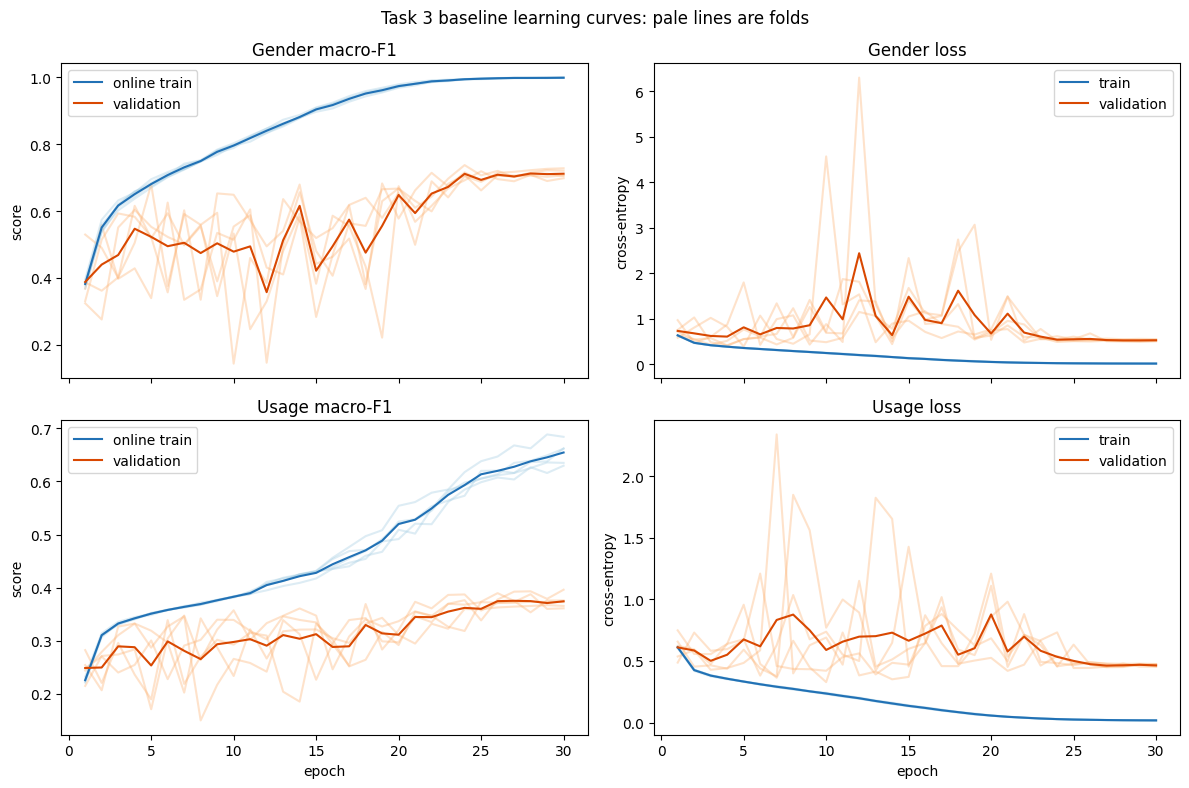

In [31]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_evidence[target]["history"]
    for fold, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} macro-F1")
    axes[row, 1].set_title(f"{target.title()} loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("cross-entropy")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 baseline learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


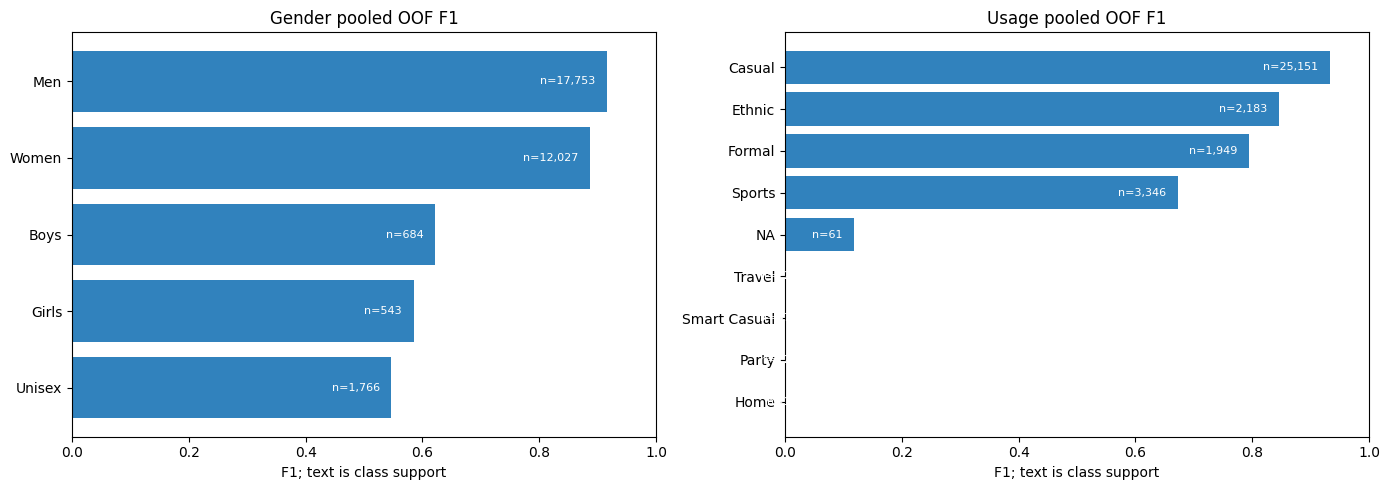

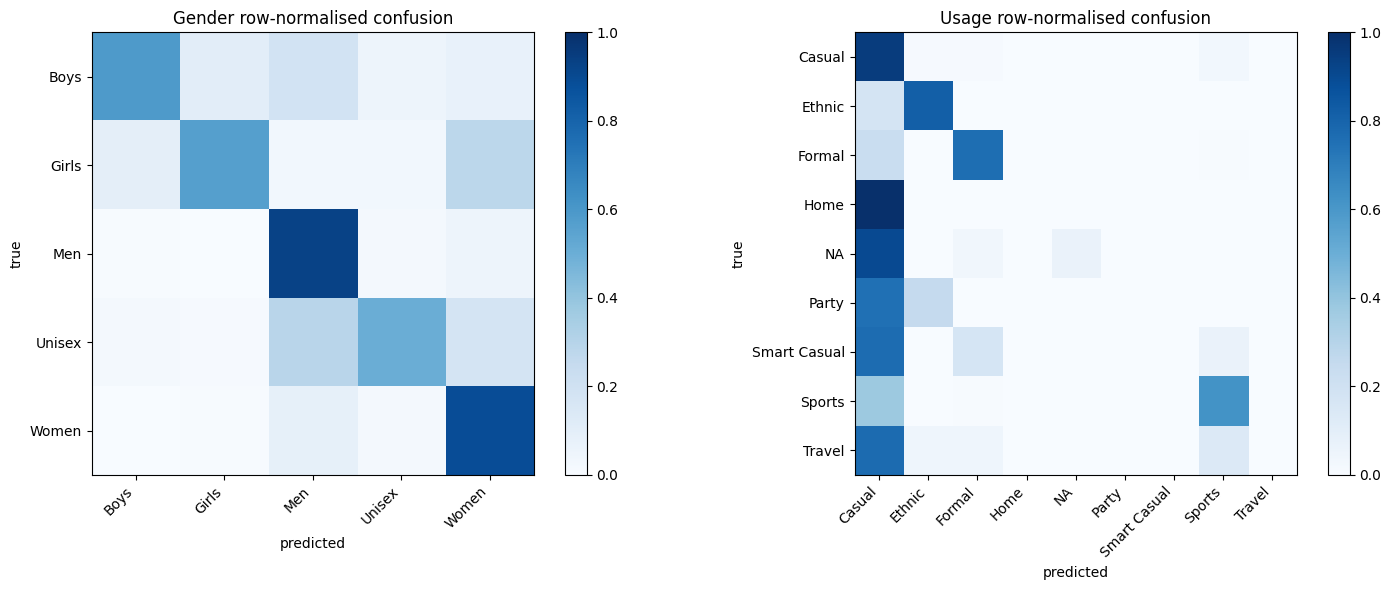

,target,corruption,mean,std
0,gender,brightness_085,-0.2562,0.0297
1,gender,brightness_115,-0.0386,0.0289
2,gender,grayscale,-0.0414,0.0090
3,gender,jpeg_75,-0.0416,0.0143
4,gender,translation_003,-0.1551,0.0029
5,usage,brightness_085,-0.0668,0.0290
6,usage,brightness_115,-0.0287,0.0124
7,usage,grayscale,-0.0135,0.0134
8,usage,jpeg_75,-0.0071,0.0149
9,usage,translation_003,-0.0642,0.0141


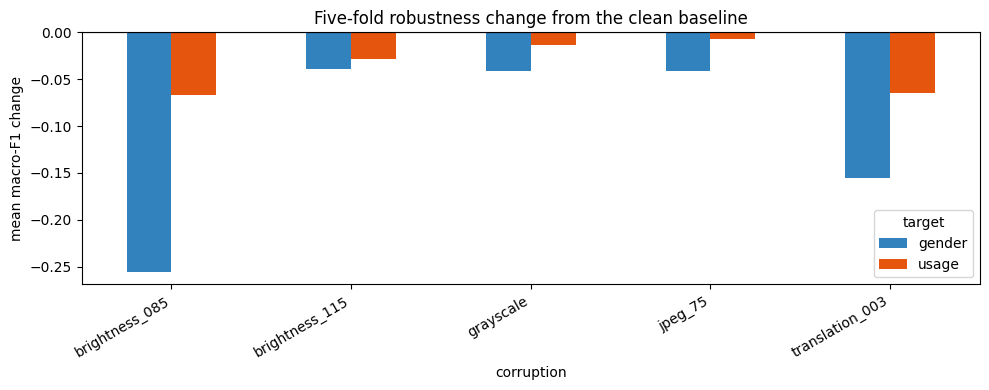

In [32]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = task3_evidence[target]["per_class"].sort_values("f1")
    bars = axis.barh(report["class_name"], report["f1"], color="#3182bd")
    axis.set_xlim(0, 1)
    axis.set_title(f"{target.title()} pooled OOF F1")
    axis.set_xlabel("F1; text is class support")
    for bar, support in zip(bars, report["support"], strict=True):
        axis.text(max(0.01, bar.get_width() - 0.02), bar.get_y() + bar.get_height()/2, f"n={support:,}", ha="right", va="center", color="white", fontsize=8)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_per_class_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_evidence[target]["confusion"].to_numpy(dtype=float)
    normalised = np.divide(confusion, confusion.sum(axis=1, keepdims=True), out=np.zeros_like(confusion), where=confusion.sum(axis=1, keepdims=True) > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Blues")
    labels = task3_evidence[target]["confusion"].index.tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "baseline_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

robust_rows = []
for target, evidence in task3_evidence.items():
    grouped = evidence["robustness"].groupby("corruption")["macro_f1_change"].agg(["mean", "std"]).reset_index()
    grouped.insert(0, "target", target)
    robust_rows.append(grouped)
robustness_summary = pd.concat(robust_rows, ignore_index=True)
display(robustness_summary.round(4))
pivot = robustness_summary.pivot(index="corruption", columns="target", values="mean")
axis = pivot.plot.bar(figsize=(10, 4), color=["#3182bd", "#e6550d"])
axis.axhline(0, color="black", linewidth=0.8)
axis.set_ylabel("mean macro-F1 change")
axis.set_title("Five-fold robustness change from the clean baseline")
plt.xticks(rotation=30, ha="right")
plt.tight_layout()
plt.savefig(FIGURE_DIR / "baseline_robustness.png", dpi=180, bbox_inches="tight")
plt.show()


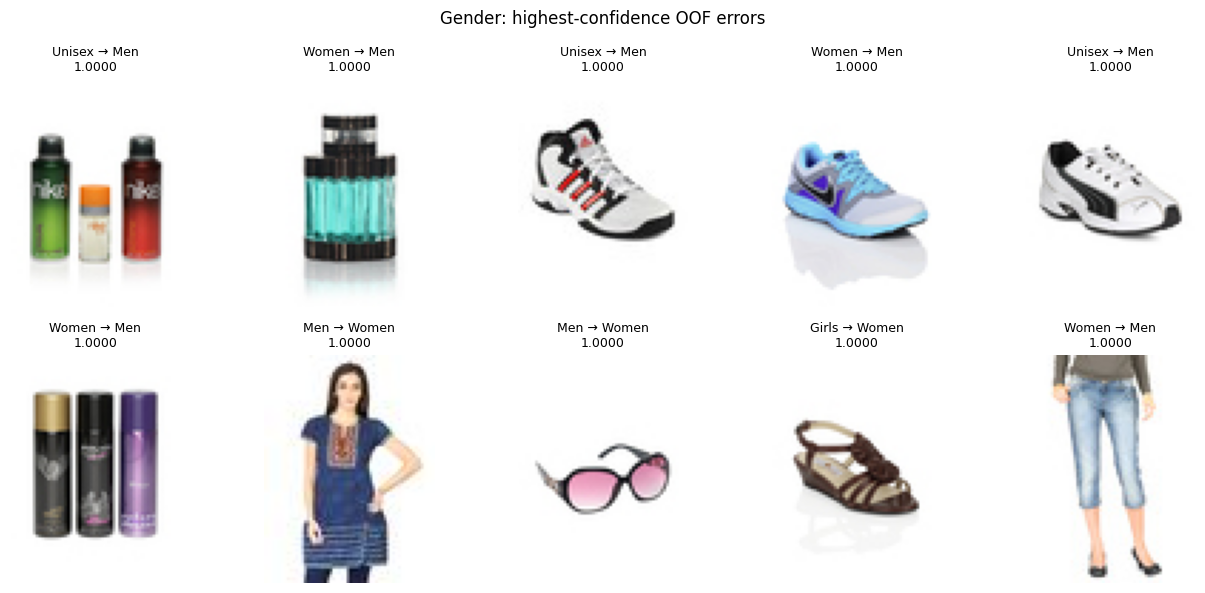

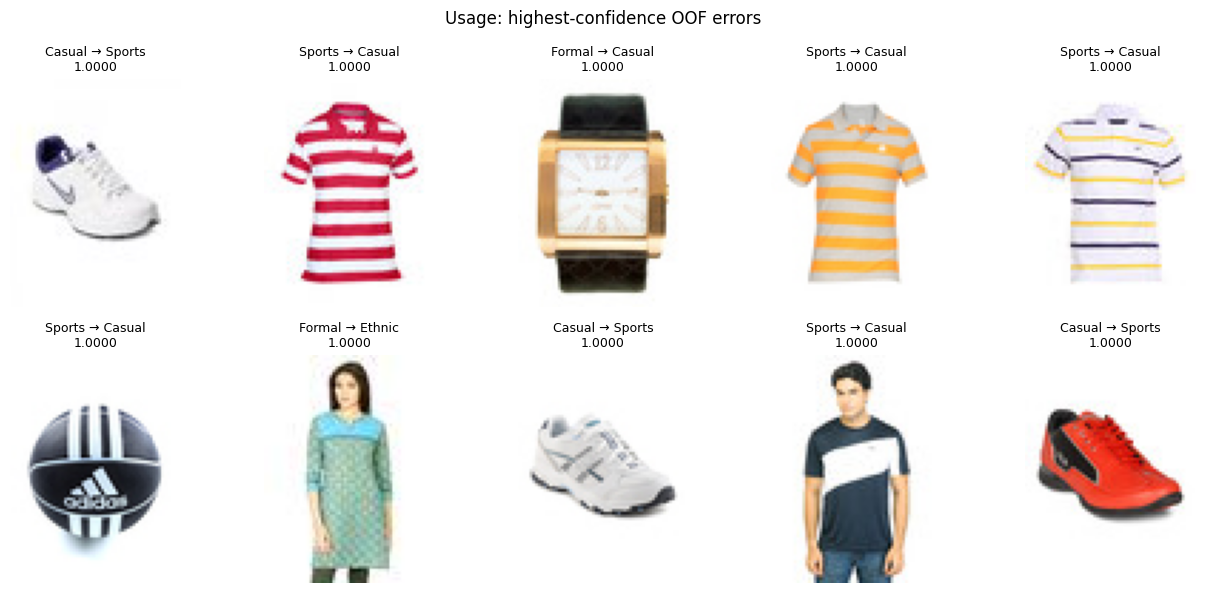

In [33]:
for target, evidence in task3_evidence.items():
    examples = (evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10))
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), examples.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()}: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"baseline_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()


## 8. Gender baseline diagnosis and next gate

**Decision: accept E1 as the reference parent, not as the final model.**

- Pooled OOF macro-F1 is **0.7118**. Fold scores are 0.6982, 0.7068, 0.7048,
  0.7207, and 0.7279: mean 0.7117, standard deviation 0.0109. The result is stable across
  the five family-safe folds.
- The final online training macro-F1 is about 0.999 in every fold while OOF stays near 0.71.
  Final training loss averages about 0.0107. This is strong memorisation evidence.
- Validation loss reaches its minimum at epochs 3–6, then rises, while the best validation
  macro-F1 arrives at epochs 24–30. Early stopping on loss would therefore hurt the frozen
  primary metric. The model becomes more certain before its minority decisions finish improving.
- Men F1 is 0.9167 and Women F1 is 0.8878. Boys, Girls, and Unisex are much weaker at
  0.6222, 0.5851, and 0.5470. Class support explains part, but not all, of this gap.
- The largest error routes are Women→Men (1,026), Men→Women (854), and Unisex→Men
  (516). Gender presentation is often weak or absent in product-only images.
- Mean macro-F1 change is −0.2562 under brightness ×0.85 and −0.1551 under a 3%
  translation. JPEG 75, grayscale, and brightness ×1.15 each cost about 0.04 or less.
- The selected 40 highest-confidence errors all have confidence at least 0.99. The gallery
  contains fragrances, watches, shoes, and other products with weak audience cues. Average
  ECE is only 0.0756, so the mean calibration score hides these extreme local mistakes.

The first eligible child changes only one factor: add mild random brightness during training.
Architecture, input size, loss, optimiser, schedule, seed, folds, and final-epoch rule stay fixed.
Class weighting, translation, more pixels, and a new architecture are not added to this child.


## 9. Usage baseline diagnosis and next gate

**Decision: accept E1 as the reference parent, not as the final model.**

- Pooled OOF macro-F1 is **0.3738**, or **0.4205** without the one-example Home class.
  Fold macro-F1 ranges from 0.3609 to 0.3960, with standard deviation 0.0121.
- Accuracy is 0.8930, but 25,151 of 32,772 valid rows (76.7%) are Casual. Accuracy and
  weighted-F1 mainly describe the large classes and hide rare-class failure.
- Casual, Ethnic, Formal, and Sports reach F1 values of 0.9329, 0.8463, 0.7939, and
  0.6731. NA reaches only 0.1176. Home, Party, Smart Casual, and Travel all score zero.
- The model predicts no Home, Party, or Smart Casual examples. It predicts Travel once,
  incorrectly. It sends 1,255 Sports, 450 Formal, 391 Ethnic, 55 NA, 36 Smart Casual,
  17 Travel, 9 Party, and the one Home row to Casual.
- Final training loss averages about 0.0177, but pooled OOF NLL is 0.4641. Validation loss
  bottoms at epochs 6–13 while the best macro-F1 appears at epochs 26–30. As with gender,
  loss-based early stopping would select the wrong model for the primary metric.
- Mean robustness drops are smaller than gender: −0.0668 for darkening and −0.0642 for
  translation. This does not make Usage strong; its clean macro-F1 is already low.
- The error gallery shows real visual overlap. Sports and Casual shirts or shoes can look
  alike, and business labels such as Formal, Party, and Travel are not always visible from
  one product image. Weighting cannot create missing visual information.

The first eligible child changes only the loss to capped class-balanced cross-entropy. It uses
effective-number weights with `beta=0.999`, mean-one nonzero normalisation, cap 5, and only
the current fold's training counts. `Home` does not select or judge the child. Architecture,
input, augmentation, optimiser, schedule, seed, folds, and checkpoint rule stay fixed.


## 10. First child evidence and decisions

The E2 rules were frozen before training. Like the baseline section, the saved outputs make the
results readable without rerunning Colab. The code reproduces the tables and figures from the
registered Drive artifacts and compares each child with its exact parent. These cells do not
train a model or read the final holdout.


In [ ]:
def load_child_evidence(target, artifact_dir, run_prefix):
    target_dir = DRIVE_TASK_DIR / artifact_dir / target
    aggregate_dir = target_dir / "aggregate"
    aggregate_files = ("metrics.json", "per_class.csv", "confusion_matrix.csv", "failure_index.csv")
    missing = [name for name in aggregate_files if not (aggregate_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing {target} child aggregate files: {missing}")

    latest_by_fold = {}
    for run_dir in sorted(target_dir.glob(f"{run_prefix}_{target}_smallcnn_f*")):
        required = [run_dir / name for name in ("config.json", "final_epoch.pt", "metrics.json", "history.csv", "robustness.csv")]
        if not all(path.is_file() for path in required):
            continue
        metrics = read_json(run_dir / "metrics.json")
        latest_by_fold[int(metrics["validation_fold"])] = {
            "run_dir": run_dir,
            "checkpoint": run_dir / "final_epoch.pt",
            "metrics": metrics,
        }
    if set(latest_by_fold) != set(range(5)):
        raise RuntimeError(f"Expected completed child folds 0-4 for {target}; found {sorted(latest_by_fold)}")

    histories = []
    robustness = []
    for fold, record in sorted(latest_by_fold.items()):
        histories.append(pd.read_csv(record["run_dir"] / "history.csv").assign(fold=fold))
        robustness.append(pd.read_csv(record["run_dir"] / "robustness.csv").assign(fold=fold))

    return {
        "aggregate_dir": aggregate_dir,
        "metrics": read_json(aggregate_dir / "metrics.json"),
        "per_class": pd.read_csv(aggregate_dir / "per_class.csv", keep_default_na=False),
        "confusion": pd.read_csv(aggregate_dir / "confusion_matrix.csv", index_col=0, keep_default_na=False),
        "failures": pd.read_csv(aggregate_dir / "failure_index.csv", keep_default_na=False),
        "folds": latest_by_fold,
        "history": pd.concat(histories, ignore_index=True),
        "robustness": pd.concat(robustness, ignore_index=True),
    }


task3_child_evidence = {
    "gender": load_child_evidence(
        "gender", "experiments/t3_gender_e2_brightness", "t3_gender_e2_brightness"
    ),
    "usage": load_child_evidence(
        "usage", "experiments/t3_usage_e2_class_balanced_ce", "t3_usage_e2_class_balanced_ce"
    ),
}
print("Loaded completed E2 evidence for gender and usage from Drive.")


Loaded completed E2 evidence for gender and usage from Drive.


In [ ]:
comparison_rows = []
for target in ("gender", "usage"):
    parent = task3_evidence[target]["metrics"]
    child = task3_child_evidence[target]["metrics"]
    metric_names = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "nll", "ece_15"]
    if target == "usage":
        metric_names.append("macro_f1_without_home")
    for metric in metric_names:
        comparison_rows.append({
            "target": target,
            "metric": metric,
            "parent": parent[metric],
            "child": child[metric],
            "change": child[metric] - parent[metric],
        })
comparison_table = pd.DataFrame(comparison_rows)
display(comparison_table.round(4))

class_rows = []
for target in ("gender", "usage"):
    parent = task3_evidence[target]["per_class"].set_index("class_name")
    child = task3_child_evidence[target]["per_class"].set_index("class_name")
    for class_name in parent.index:
        class_rows.append({
            "target": target,
            "class_name": class_name,
            "support": int(parent.loc[class_name, "support"]),
            "parent_f1": parent.loc[class_name, "f1"],
            "child_f1": child.loc[class_name, "f1"],
            "f1_change": child.loc[class_name, "f1"] - parent.loc[class_name, "f1"],
        })
class_comparison = pd.DataFrame(class_rows)
display(class_comparison.round(4))

robustness_rows = []
for target in ("gender", "usage"):
    parent = task3_evidence[target]["robustness"].groupby("corruption")["macro_f1_change"].mean()
    child = task3_child_evidence[target]["robustness"].groupby("corruption")["macro_f1_change"].mean()
    for corruption in parent.index:
        robustness_rows.append({
            "target": target,
            "corruption": corruption,
            "parent_change": parent[corruption],
            "child_change": child[corruption],
            "improvement": child[corruption] - parent[corruption],
        })
robustness_comparison = pd.DataFrame(robustness_rows)
display(robustness_comparison.round(4))

gate_table = pd.DataFrame([
    {"target": "gender", "gate": "pooled macro-F1 >= 0.7218", "observed": task3_child_evidence["gender"]["metrics"]["macro_f1"], "passed": task3_child_evidence["gender"]["metrics"]["macro_f1"] >= 0.7218},
    {"target": "usage", "gate": "pooled macro-F1 >= 0.3938", "observed": task3_child_evidence["usage"]["metrics"]["macro_f1"], "passed": task3_child_evidence["usage"]["metrics"]["macro_f1"] >= 0.3938},
    {"target": "usage", "gate": "macro-F1 without Home >= 0.4405", "observed": task3_child_evidence["usage"]["metrics"]["macro_f1_without_home"], "passed": task3_child_evidence["usage"]["metrics"]["macro_f1_without_home"] >= 0.4405},
])
display(gate_table.round(4))


    target                 metric  parent   child  change
0   gender               accuracy  0.8768  0.8730 -0.0038
1   gender      balanced_accuracy  0.6933  0.6767 -0.0166
2   gender               macro_f1  0.7118  0.6989 -0.0129
3   gender            weighted_f1  0.8745  0.8707 -0.0038
4   gender                    nll  0.5237  0.5041 -0.0197
5   gender                 ece_15  0.0756  0.0750 -0.0007
6    usage               accuracy  0.8930  0.8915 -0.0015
7    usage      balanced_accuracy  0.3571  0.3826  0.0255
8    usage               macro_f1  0.3738  0.4082  0.0344
9    usage            weighted_f1  0.8885  0.8876 -0.0009
10   usage                    nll  0.4641  0.3428 -0.1213
11   usage                 ece_15  0.0672  0.0331 -0.0341
12   usage  macro_f1_without_home  0.4205  0.4592  0.0387

    target    class_name  support  parent_f1  child_f1  f1_change
0   gender          Boys      684     0.6222    0.5980    -0.0242
1   gender         Girls      543     0.5851    0.5425    -0.0426
2   gender           Men    17753     0.9167    0.9141    -0.0027
3   gender        Unisex     1766     0.5470    0.5568     0.0098
4   gender         Women    12027     0.8878    0.8831    -0.0046
5    usage        Casual    25151     0.9329    0.9318    -0.0011
6    usage        Ethnic     2183     0.8463    0.8540     0.0077
7    usage        Formal     1949     0.7939    0.7759    -0.0180
8    usage          Home        1     0.0000    0.0000     0.0000
9    usage            NA       61     0.1176    0.2299     0.1122
10   usage         Party       12     0.0000    0.0000     0.0000
11   usage  Smart Casual       47     0.0000    0.0000     0.0000
12   usage        Sports     3346     0.6731    0.6751     0.0020
13   usage        Travel       22     0.0000    0.2069     0.2069

   target                   gate  threshold  observed  passed
0  gender        pooled macro-F1     0.7218    0.6989   False
1   usage        pooled macro-F1     0.3938    0.4082    True
2   usage  macro-F1 without Home     0.4405    0.4592    True

In [ ]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_child_evidence[target]["history"]
    for fold, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} E2 macro-F1")
    axes[row, 1].set_title(f"{target.title()} E2 loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("cross-entropy")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 E2 learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
fold_rows = []
for target in ("gender", "usage"):
    for fold in range(5):
        parent = task3_evidence[target]["folds"][fold]["metrics"]["macro_f1"]
        child = task3_child_evidence[target]["folds"][fold]["metrics"]["macro_f1"]
        fold_rows.append({"target": target, "fold": fold, "parent_macro_f1": parent, "child_macro_f1": child, "change": child - parent})
fold_comparison = pd.DataFrame(fold_rows)
display(fold_comparison.round(4))

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["child_macro_f1"], 0.36, label="E2 child", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} final validation macro-F1")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.18, report["parent_f1"], 0.36, label="parent", color="#9ecae1")
    axis.barh(y + 0.18, report["child_f1"], 0.36, label="E2 child", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_xlabel("pooled OOF F1")
    axis.set_title(f"{target.title()} class comparison")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_child_evidence[target]["confusion"].to_numpy(dtype=float)
    row_totals = confusion.sum(axis=1, keepdims=True)
    normalised = np.divide(confusion, row_totals, out=np.zeros_like(confusion), where=row_totals > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Oranges")
    labels = task3_child_evidence[target]["confusion"].index.astype(str).tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} E2 row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["child_change"], 0.36, label="E2 child", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("mean macro-F1 change from clean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e2_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
for target, evidence in task3_child_evidence.items():
    examples = (evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10))
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), examples.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()} E2: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"e2_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()


### Saved E2 figures

The plotting cells above reproduce these figures from the registered Drive artifacts.

![E2 learning curves](../results/figures/task3/e2_learning_curves.png)

![Parent and E2 fold comparison](../results/figures/task3/e2_fold_macro_f1.png)

![Parent and E2 per-class comparison](../results/figures/task3/e2_per_class_f1_comparison.png)

![E2 normalised confusion matrices](../results/figures/task3/e2_normalised_confusion.png)


### Gender E2 — reject brightness augmentation

Gender E2 reached **0.6989 pooled macro-F1**, down **0.0129** from 0.7118. It missed
the frozen 0.7218 gate by 0.0229. Accuracy fell from 0.8768 to 0.8730 and balanced
accuracy fell from 0.6933 to 0.6767. Final fold macro-F1 values were 0.7279, 0.6774,
0.6740, 0.7260, and 0.6889. Their standard deviation was 0.0263, compared with 0.0109
for E1, so the child was also less stable across folds.
The fold plot makes the instability visible: E2 improves folds 0 and 3, but loses on folds 1,
2, and 4. Its learning curves still drive training macro-F1 close to 1.0 while validation stays
near 0.70 and moves sharply between epochs. Brightness did not reduce memorisation.

| Class | E1 F1 | E2 F1 | Change |
|---|---:|---:|---:|
| Boys | 0.6222 | 0.5980 | -0.0242 |
| Girls | 0.5851 | 0.5425 | -0.0426 |
| Men | 0.9167 | 0.9141 | -0.0026 |
| Unisex | 0.5470 | 0.5568 | +0.0098 |
| Women | 0.8878 | 0.8831 | -0.0047 |

The common-class guard passed, but the primary gate did not. Boys and Girls lost more than
Unisex gained. Even if the robustness table shows better dark-image behaviour, the rule required
both robustness and clean macro-F1. Random brightness therefore changes the input without fixing
the main generalisation error. **E2 is rejected and E1 remains the Gender parent.**

### Usage E2 — accept class-balanced cross-entropy

Usage E2 reached **0.4082 pooled macro-F1**, up **0.0344** from 0.3738, and reached
**0.4592 without Home**, up **0.0387** from 0.4205. Both frozen gates passed. Balanced
accuracy improved from 0.3571 to 0.3826 while ordinary accuracy moved only from 0.8930
to 0.8915. This is the intended trade: better treatment of supported minority classes with
almost no loss on the majority-dominated accuracy.

Calibration also improved: NLL fell from 0.4641 to 0.3428 and ECE fell from 0.0672 to
0.0331. Final fold macro-F1 values were 0.4086, 0.3818, 0.4362, 0.3999, and 0.3950.
Their standard deviation was 0.0203, higher than E1's 0.0121, so the gain is useful but
not equally strong in every fold.
The fold plot shows improvement in four of five folds; only fold 4 is effectively flat. The
learning curves still show a large train-validation gap, but validation macro-F1 rises more
consistently than Gender. This supports keeping the new loss while testing one small
regularisation change next.

| Class | E1 F1 | E2 F1 | Change |
|---|---:|---:|---:|
| Casual | 0.9329 | 0.9318 | -0.0011 |
| Ethnic | 0.8463 | 0.8540 | +0.0077 |
| Formal | 0.7939 | 0.7759 | -0.0180 |
| Home | 0.0000 | 0.0000 | 0.0000 |
| NA | 0.1176 | 0.2299 | +0.1123 |
| Party | 0.0000 | 0.0000 | 0.0000 |
| Smart Casual | 0.0000 | 0.0000 | 0.0000 |
| Sports | 0.6731 | 0.6751 | +0.0020 |
| Travel | 0.0000 | 0.2069 | +0.2069 |

Casual stayed flat and Sports improved, so the no-harm guard passed. The largest gains came
from NA and Travel, but Party, Smart Casual, and the one-row Home class remain unlearned.
Formal also fell by 0.0180. Weighting helped the classes that had some learnable evidence; it
could not invent evidence for tiny classes or remove semantic overlap. **E2 is accepted as the
new Usage parent, but not yet declared final.** The confusion plot confirms the remaining
failure: Home, Party, and Smart Casual still collapse mostly into Casual; Travel is detected only
three times and NA only ten times.


## 11. Next hypotheses

These proposals and gates are frozen before another run. `E1`, `E2`, and `E3` below are
sequential experiment labels, not the research document's evidence-level names. A rejected
change is not stacked: Gender E3 starts from E1. Usage E3 starts from accepted E2.

### Gender E3 hypothesis: mildly weight the supported minority classes

Brightness augmentation did not close the generalisation gap and hurt Boys and Girls. E1 still
has strong support imbalance: Men and Women dominate, while Boys, Girls, and Unisex have mean
F1 0.5848. Usage E2 shows that this loss can help another target, but it does not prove that it
will help Gender. The cap is a safety bound; the largest expected fold weight is only about 1.66.

| Pre-training decision | Frozen value |
|---|---|
| Parent | Gender E1 baseline; do not inherit brightness augmentation |
| One change | Effective-number class-balanced cross-entropy only: `beta=0.999`, mean-one present-class weights, cap `5.0` |
| Everything kept fixed | SmallCNN, `80×60` input, no augmentation, optimiser, schedule, 30 epochs, seed, folds, final checkpoint |
| Primary success gates | Pooled OOF macro-F1 ≥ 0.7218; mean Boys/Girls/Unisex F1 ≥ 0.6048 |
| Paired uncertainty gate | In a fixed 10,000-sample product-family bootstrap, the 95% interval for macro-F1 change is entirely above zero |
| Class no-harm gates | Men F1 ≥ 0.8967; Women F1 ≥ 0.8678; no class has zero recall; each minority predicted count ≤ 1.5× its support |
| Stability and calibration gates | Fold macro-F1 SD ≤ 0.0209; NLL ≤ 0.5437; ECE-15 ≤ 0.0856 |
| Robustness gate | For every tested corruption, mean macro-F1 change is no more than 0.02 worse than E1 |
| Written before training | Yes |
| Current state | Completed; evaluated in Section 12 |

### Usage E3 hypothesis: test mild classifier regularisation

E2 is the accepted parent. Its online training score is much higher than validation, which
suggests overfitting but does not prove the final model memorised the fold. E3 therefore adds
dropout only after global pooling and before the final linear classifier. Finished-model training
metrics will be measured in evaluation mode before making a memorisation claim.

| Pre-training decision | Frozen value |
|---|---|
| Parent | Accepted Usage E2 class-balanced SmallCNN |
| One change | Dropout `p=0.20` after global pooling and before the final linear classifier |
| Everything kept fixed | SmallCNN channels, `80×60` input, E2 loss and weights, no augmentation, optimiser, schedule, 30 epochs, seed, folds, final checkpoint |
| Primary success gates | Pooled OOF macro-F1 ≥ 0.4182; macro-F1 without Home ≥ 0.4692 |
| Paired uncertainty gate | In a fixed 10,000-sample product-family bootstrap, the 95% interval for macro-F1 change is entirely above zero |
| Overall no-harm gate | Accuracy ≥ 0.8815 |
| Class no-harm gates | Casual F1 ≥ 0.9018; Ethnic ≥ 0.8240; Formal ≥ 0.7459; Sports ≥ 0.6451 |
| Minority gates | Mean NA/Travel F1 ≥ 0.1984 and both classes retain non-zero recall |
| Stability and calibration gates | Fold macro-F1 SD ≤ 0.0303; NLL ≤ 0.3628; ECE-15 ≤ 0.0431 |
| Robustness gate | For every tested corruption, mean macro-F1 change is no more than 0.02 worse than E2 |
| Written before training | Yes |
| Current state | Completed; evaluated in Section 12 |

Both next runs keep SmallCNN. A quality-driven architecture test opens only after three seeds
show real underfitting: finished-model train/validation macro-F1 gap ≤ 0.05 in at least four
folds, absolute last-five validation slope < 0.002 per epoch, low training performance, and
errors with learnable image structure rather than tiny support or label ambiguity. The first
architecture candidate would be a scratch low-resolution ResNet-18 with a `3×3` stride-one stem
and no early max-pool. One failed E3 run is not enough to open that test.


## 12. E3 evidence and decisions

Both predeclared E3 children completed all five folds. This section reads their registered
Drive artifacts, compares each child only with its accepted parent, and applies every gate
written in Section 11. No result below is typed into an analysis code cell.


In [2]:
task3_e3_evidence = {
    "gender": load_child_evidence(
        "gender",
        "experiments/t3_gender_e3_class_balanced_ce",
        "t3_gender_e3_class_balanced_ce",
    ),
    "usage": load_child_evidence(
        "usage",
        "experiments/t3_usage_e3_classifier_dropout",
        "t3_usage_e3_classifier_dropout",
    ),
}
task3_e3_parents = {
    "gender": task3_evidence["gender"],
    "usage": task3_child_evidence["usage"],
}

for target in ("gender", "usage"):
    oof_path = task3_e3_evidence[target]["aggregate_dir"] / "oof_predictions.csv"
    if not oof_path.is_file():
        raise FileNotFoundError(f"Missing E3 pooled OOF predictions: {oof_path}")
print("Loaded completed E3 evidence and accepted parents from Drive.")

Loaded completed E3 evidence and accepted parents from Drive.


In [3]:
e3_metric_rows = []
e3_class_rows = []
e3_fold_rows = []
e3_robustness_rows = []
for target in ("gender", "usage"):
    parent = task3_e3_parents[target]
    child = task3_e3_evidence[target]
    metrics = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "nll", "ece_15"]
    if target == "usage":
        metrics.append("macro_f1_without_home")
    for metric in metrics:
        e3_metric_rows.append({
            "target": target,
            "metric": metric,
            "parent": parent["metrics"][metric],
            "e3": child["metrics"][metric],
            "change": child["metrics"][metric] - parent["metrics"][metric],
        })

    parent_classes = parent["per_class"].set_index("class_name")
    child_classes = child["per_class"].set_index("class_name")
    for class_name in parent_classes.index:
        e3_class_rows.append({
            "target": target,
            "class_name": class_name,
            "support": int(parent_classes.loc[class_name, "support"]),
            "parent_f1": parent_classes.loc[class_name, "f1"],
            "e3_f1": child_classes.loc[class_name, "f1"],
            "f1_change": child_classes.loc[class_name, "f1"] - parent_classes.loc[class_name, "f1"],
        })

    for fold in range(5):
        parent_fold = parent["folds"][fold]["metrics"]
        child_fold = child["folds"][fold]["metrics"]
        e3_fold_rows.append({
            "target": target,
            "fold": fold,
            "parent_macro_f1": parent_fold["macro_f1"],
            "e3_macro_f1": child_fold["macro_f1"],
            "change": child_fold["macro_f1"] - parent_fold["macro_f1"],
            "final_train_eval_macro_f1": child_fold["final_train_eval_macro_f1"],
            "final_train_validation_gap": child_fold["final_train_validation_macro_f1_gap"],
        })

    parent_robustness = parent["robustness"].groupby("corruption")["macro_f1_change"].mean()
    child_robustness = child["robustness"].groupby("corruption")["macro_f1_change"].mean()
    for corruption in parent_robustness.index:
        e3_robustness_rows.append({
            "target": target,
            "corruption": corruption,
            "parent_change": parent_robustness[corruption],
            "e3_change": child_robustness[corruption],
            "difference": child_robustness[corruption] - parent_robustness[corruption],
        })

e3_metric_comparison = pd.DataFrame(e3_metric_rows)
e3_class_comparison = pd.DataFrame(e3_class_rows)
e3_fold_comparison = pd.DataFrame(e3_fold_rows)
e3_robustness_comparison = pd.DataFrame(e3_robustness_rows)
display(e3_metric_comparison.round(4))
display(e3_class_comparison.round(4))
display(e3_fold_comparison.round(4))
display(e3_robustness_comparison.round(4))

,target,metric,parent,e3,change
0,gender,accuracy,0.8768,0.8732,-0.0035
1,gender,balanced_accuracy,0.6933,0.6882,-0.0051
2,gender,macro_f1,0.7118,0.7081,-0.0036
3,gender,weighted_f1,0.8745,0.8710,-0.0036
4,gender,nll,0.5237,0.5357,0.0120
5,gender,ece_15,0.0756,0.0789,0.0032
6,usage,accuracy,0.8915,0.8917,0.0002
7,usage,balanced_accuracy,0.3826,0.3853,0.0027
8,usage,macro_f1,0.4082,0.4161,0.0080
9,usage,weighted_f1,0.8876,0.8872,-0.0004


,target,class_name,support,parent_f1,e3_f1,f1_change
0,gender,Boys,684,0.6222,0.6291,0.0069
1,gender,Girls,543,0.5851,0.5620,-0.0231
2,gender,Men,17753,0.9167,0.9130,-0.0037
3,gender,Unisex,1766,0.5470,0.5532,0.0062
4,gender,Women,12027,0.8878,0.8833,-0.0045
5,usage,Casual,25151,0.9318,0.9320,0.0003
6,usage,Ethnic,2183,0.8540,0.8531,-0.0009
7,usage,Formal,1949,0.7759,0.7778,0.0019
8,usage,Home,1,0.0000,0.0000,0.0000
9,usage,NA,61,0.2299,0.2651,0.0352


,target,fold,parent_macro_f1,e3_macro_f1,change,final_train_eval_macro_f1,final_train_validation_gap
0,gender,0,0.6982,0.6833,-0.0149,0.9992,0.3159
1,gender,1,0.7068,0.7238,0.0170,0.9999,0.2760
2,gender,2,0.7048,0.7111,0.0063,0.9991,0.2880
3,gender,3,0.7207,0.7117,-0.0090,0.9992,0.2876
4,gender,4,0.7279,0.7094,-0.0185,0.9998,0.2904
5,usage,0,0.4086,0.4608,0.0522,0.9494,0.4886
6,usage,1,0.3818,0.3867,0.0049,0.9584,0.5717
7,usage,2,0.4362,0.4253,-0.0109,0.9443,0.5190
8,usage,3,0.3999,0.4003,0.0004,0.9507,0.5503
9,usage,4,0.3950,0.3970,0.0019,0.8427,0.4457


,target,corruption,parent_change,e3_change,difference
0,gender,brightness_085,-0.2562,-0.2368,0.0194
1,gender,brightness_115,-0.0386,-0.0389,-0.0003
2,gender,grayscale,-0.0414,-0.0387,0.0027
3,gender,jpeg_75,-0.0416,-0.0331,0.0085
4,gender,translation_003,-0.1551,-0.1647,-0.0095
5,usage,brightness_085,-0.1289,-0.1252,0.0037
6,usage,brightness_115,-0.0316,-0.0355,-0.0039
7,usage,grayscale,-0.0145,-0.0213,-0.0068
8,usage,jpeg_75,-0.0007,0.0020,0.0027
9,usage,translation_003,-0.0869,-0.0858,0.0011


In [4]:
def confusion_macro_f1(confusion):
    true_positives = np.diagonal(confusion, axis1=1, axis2=2)
    support = confusion.sum(axis=2)
    predicted = confusion.sum(axis=1)
    denominator = support + predicted
    per_class = np.divide(
        2 * true_positives,
        denominator,
        out=np.zeros_like(true_positives, dtype=float),
        where=denominator > 0,
    )
    return per_class.mean(axis=1)


def grouped_confusion_entries(group_index, flat_category, width):
    keys, counts = np.unique(group_index * width + flat_category, return_counts=True)
    return keys // width, keys % width, counts


def weighted_group_confusions(weights, group_indices, categories, counts, width):
    result = np.zeros((len(weights), width), dtype=np.int64)
    for category in range(width):
        selected = categories == category
        if selected.any():
            result[:, category] = weights[:, group_indices[selected]] @ counts[selected]
    return result


def paired_family_bootstrap_macro_f1(parent_path, child_path, class_count, *, samples=10_000, seed=2753, batch_size=50):
    columns = ["id", "product_family_group", "true_index", "predicted_index"]
    parent = pd.read_csv(parent_path, usecols=columns, keep_default_na=False).rename(
        columns={"product_family_group": "parent_group", "true_index": "parent_true", "predicted_index": "parent_predicted"}
    )
    child = pd.read_csv(child_path, usecols=columns, keep_default_na=False).rename(
        columns={"product_family_group": "child_group", "true_index": "child_true", "predicted_index": "child_predicted"}
    )
    paired = parent.merge(child, on="id", how="inner", validate="one_to_one")
    if len(paired) != len(parent) or len(paired) != len(child):
        raise ValueError("Parent and child OOF rows do not match one-to-one")
    if not paired["parent_group"].equals(paired["child_group"]):
        raise ValueError("Parent and child product-family groups disagree")
    if not paired["parent_true"].equals(paired["child_true"]):
        raise ValueError("Parent and child labels disagree")

    group_index, groups = pd.factorize(paired["parent_group"], sort=True)
    parent_flat = paired["parent_true"].to_numpy() * class_count + paired["parent_predicted"].to_numpy()
    child_flat = paired["child_true"].to_numpy() * class_count + paired["child_predicted"].to_numpy()
    width = class_count * class_count
    parent_group, parent_category, parent_count = grouped_confusion_entries(
        group_index, parent_flat, width
    )
    child_group, child_category, child_count = grouped_confusion_entries(
        group_index, child_flat, width
    )

    rng = np.random.default_rng(seed)
    deltas = np.empty(samples, dtype=float)
    for start in range(0, samples, batch_size):
        batch = min(batch_size, samples - start)
        draws = rng.integers(0, len(groups), size=(batch, len(groups)), dtype=np.int32)
        offsets = np.arange(batch, dtype=np.int64)[:, None] * len(groups)
        weights = np.bincount(
            (draws + offsets).ravel(), minlength=batch * len(groups)
        ).reshape(batch, len(groups))
        parent_confusion = weighted_group_confusions(
            weights, parent_group, parent_category, parent_count, width
        ).reshape(batch, class_count, class_count)
        child_confusion = weighted_group_confusions(
            weights, child_group, child_category, child_count, width
        ).reshape(batch, class_count, class_count)
        deltas[start:start + batch] = (
            confusion_macro_f1(child_confusion) - confusion_macro_f1(parent_confusion)
        )
    return {
        "rows": len(paired),
        "families": len(groups),
        "samples": samples,
        "seed": seed,
        "mean_delta": deltas.mean(),
        "lower_95": np.quantile(deltas, 0.025),
        "upper_95": np.quantile(deltas, 0.975),
        "probability_positive": np.mean(deltas > 0),
    }


e3_bootstrap = {}
for target in ("gender", "usage"):
    parent_path = task3_e3_parents[target]["aggregate_dir"] / "oof_predictions.csv"
    child_path = task3_e3_evidence[target]["aggregate_dir"] / "oof_predictions.csv"
    e3_bootstrap[target] = paired_family_bootstrap_macro_f1(
        parent_path, child_path, len(label_maps[target]["classes"])
    )
display(pd.DataFrame.from_dict(e3_bootstrap, orient="index").round(4))

,rows,families,samples,seed,mean_delta,lower_95,upper_95,probability_positive
gender,32773,22905,10000,2753,-0.0036,-0.0157,0.0085,0.2749
usage,32772,22904,10000,2753,0.0078,-0.0069,0.0238,0.8454


In [5]:
gate_rows = []


def add_gate(target, gate, observed, rule, passed):
    gate_rows.append({
        "target": target, "gate": gate, "observed": observed, "rule": rule, "passed": bool(passed)
    })


gender_metrics = task3_e3_evidence["gender"]["metrics"]
gender_classes = task3_e3_evidence["gender"]["per_class"].set_index("class_name")
gender_minority = gender_classes.loc[["Boys", "Girls", "Unisex"]]
gender_fold_sd = e3_fold_comparison.query("target == 'gender'")["e3_macro_f1"].std(ddof=1)
gender_robustness_worst = e3_robustness_comparison.query("target == 'gender'")["difference"].min()
add_gate("gender", "pooled OOF macro-F1", gender_metrics["macro_f1"], "≥ 0.7218", gender_metrics["macro_f1"] >= 0.7218)
add_gate("gender", "mean Boys/Girls/Unisex F1", gender_minority["f1"].mean(), "≥ 0.6048", gender_minority["f1"].mean() >= 0.6048)
add_gate("gender", "paired family-bootstrap lower 95% bound", e3_bootstrap["gender"]["lower_95"], "> 0", e3_bootstrap["gender"]["lower_95"] > 0)
add_gate("gender", "Men F1", gender_classes.loc["Men", "f1"], "≥ 0.8967", gender_classes.loc["Men", "f1"] >= 0.8967)
add_gate("gender", "Women F1", gender_classes.loc["Women", "f1"], "≥ 0.8678", gender_classes.loc["Women", "f1"] >= 0.8678)
add_gate("gender", "minimum class recall", gender_classes["recall"].min(), "> 0", gender_classes["recall"].min() > 0)
add_gate("gender", "largest minority predicted/support ratio", (gender_minority["predicted_count"] / gender_minority["support"]).max(), "≤ 1.5", (gender_minority["predicted_count"] / gender_minority["support"]).max() <= 1.5)
add_gate("gender", "fold macro-F1 SD", gender_fold_sd, "≤ 0.0209", gender_fold_sd <= 0.0209)
add_gate("gender", "NLL", gender_metrics["nll"], "≤ 0.5437", gender_metrics["nll"] <= 0.5437)
add_gate("gender", "ECE-15", gender_metrics["ece_15"], "≤ 0.0856", gender_metrics["ece_15"] <= 0.0856)
add_gate("gender", "worst corruption change versus parent", gender_robustness_worst, "≥ -0.02", gender_robustness_worst >= -0.02)

usage_metrics = task3_e3_evidence["usage"]["metrics"]
usage_classes = task3_e3_evidence["usage"]["per_class"].set_index("class_name")
usage_fold_sd = e3_fold_comparison.query("target == 'usage'")["e3_macro_f1"].std(ddof=1)
usage_robustness_worst = e3_robustness_comparison.query("target == 'usage'")["difference"].min()
add_gate("usage", "pooled OOF macro-F1", usage_metrics["macro_f1"], "≥ 0.4182", usage_metrics["macro_f1"] >= 0.4182)
add_gate("usage", "macro-F1 without Home", usage_metrics["macro_f1_without_home"], "≥ 0.4692", usage_metrics["macro_f1_without_home"] >= 0.4692)
add_gate("usage", "paired family-bootstrap lower 95% bound", e3_bootstrap["usage"]["lower_95"], "> 0", e3_bootstrap["usage"]["lower_95"] > 0)
add_gate("usage", "accuracy", usage_metrics["accuracy"], "≥ 0.8815", usage_metrics["accuracy"] >= 0.8815)
for class_name, floor in {"Casual": 0.9018, "Ethnic": 0.8240, "Formal": 0.7459, "Sports": 0.6451}.items():
    add_gate("usage", f"{class_name} F1", usage_classes.loc[class_name, "f1"], f"≥ {floor:.4f}", usage_classes.loc[class_name, "f1"] >= floor)
usage_minority = usage_classes.loc[["NA", "Travel"]]
add_gate("usage", "mean NA/Travel F1", usage_minority["f1"].mean(), "≥ 0.1984", usage_minority["f1"].mean() >= 0.1984)
add_gate("usage", "minimum NA/Travel recall", usage_minority["recall"].min(), "> 0", usage_minority["recall"].min() > 0)
add_gate("usage", "fold macro-F1 SD", usage_fold_sd, "≤ 0.0303", usage_fold_sd <= 0.0303)
add_gate("usage", "NLL", usage_metrics["nll"], "≤ 0.3628", usage_metrics["nll"] <= 0.3628)
add_gate("usage", "ECE-15", usage_metrics["ece_15"], "≤ 0.0431", usage_metrics["ece_15"] <= 0.0431)
add_gate("usage", "worst corruption change versus parent", usage_robustness_worst, "≥ -0.02", usage_robustness_worst >= -0.02)

e3_gate_table = pd.DataFrame(gate_rows)
e3_decisions = e3_gate_table.groupby("target")["passed"].all().rename("accepted").to_frame()
display(e3_gate_table.round({"observed": 4}))
display(e3_decisions)

,target,gate,observed,rule,passed
0,gender,pooled OOF macro-F1,0.7081,≥ 0.7218,False
1,gender,mean Boys/Girls/Unisex F1,0.5814,≥ 0.6048,False
2,gender,paired family-bootstrap lower 95% bound,-0.0157,> 0,False
3,gender,Men F1,0.9130,≥ 0.8967,True
4,gender,Women F1,0.8833,≥ 0.8678,True
5,gender,minimum class recall,0.5062,> 0,True
6,gender,largest minority predicted/support ratio,0.8918,≤ 1.5,True
7,gender,fold macro-F1 SD,0.0149,≤ 0.0209,True
8,gender,NLL,0.5357,≤ 0.5437,True
9,gender,ECE-15,0.0789,≤ 0.0856,True


,accepted
target,
gender,False
usage,False


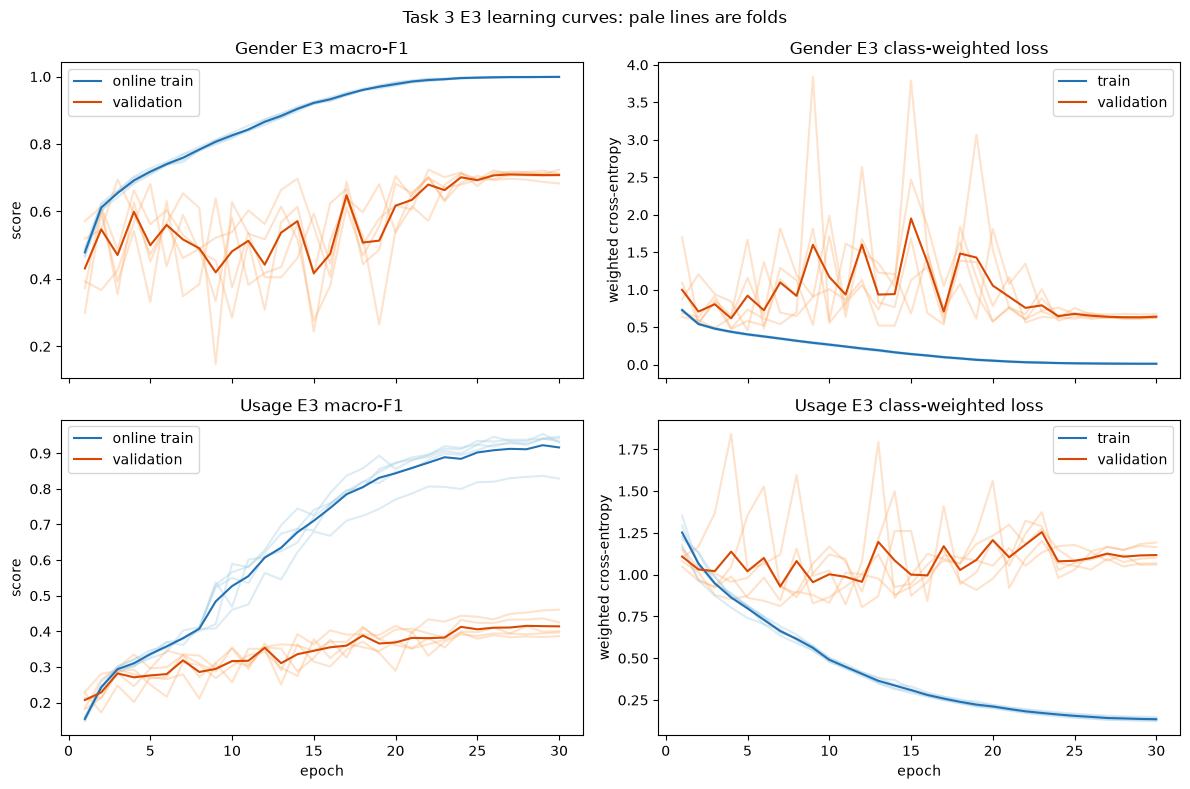

In [6]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_e3_evidence[target]["history"]
    for fold, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} E3 macro-F1")
    axes[row, 1].set_title(f"{target.title()} E3 class-weighted loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("weighted cross-entropy")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 E3 learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e3_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()

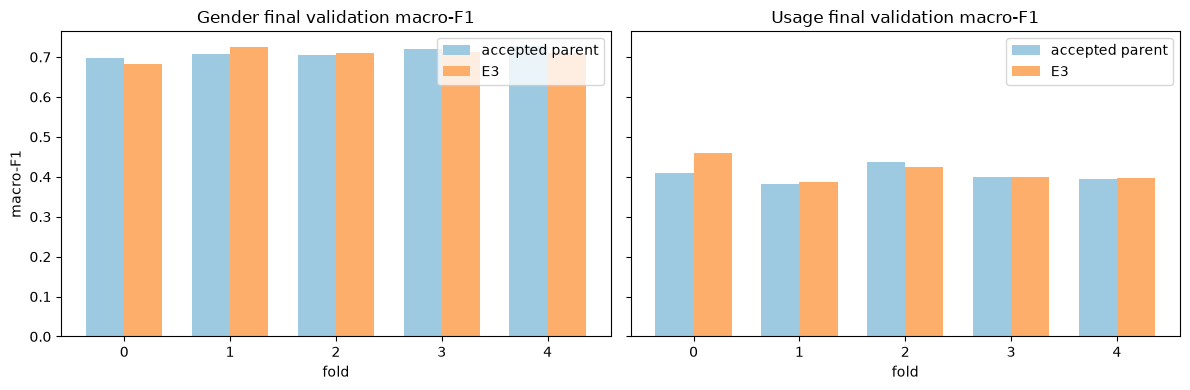

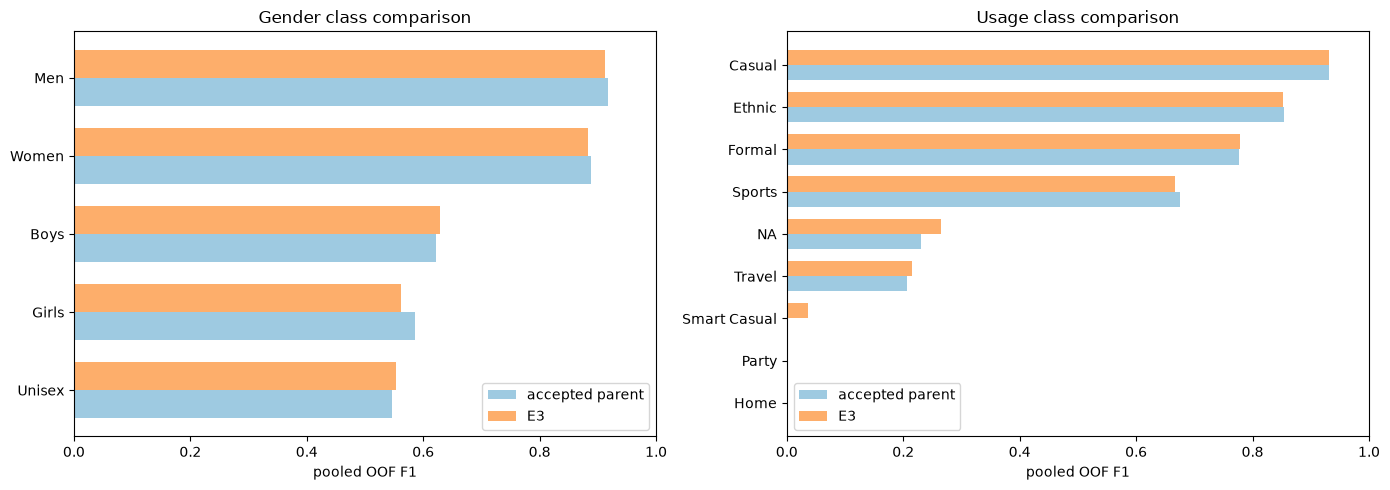

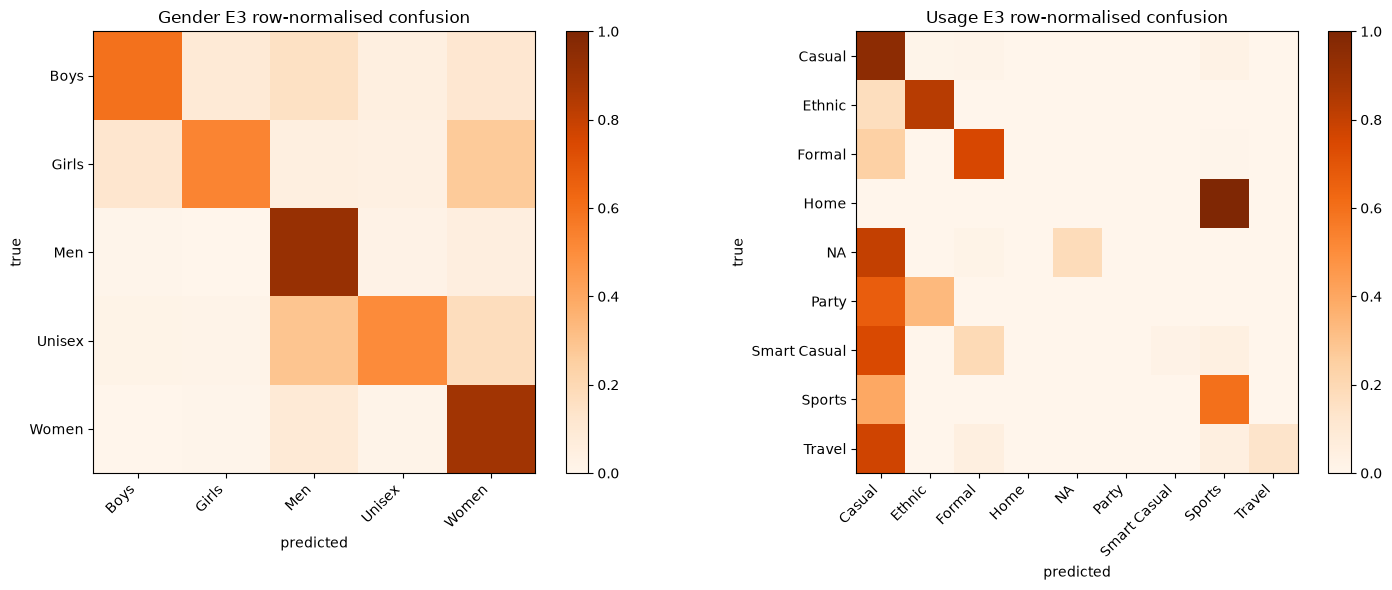

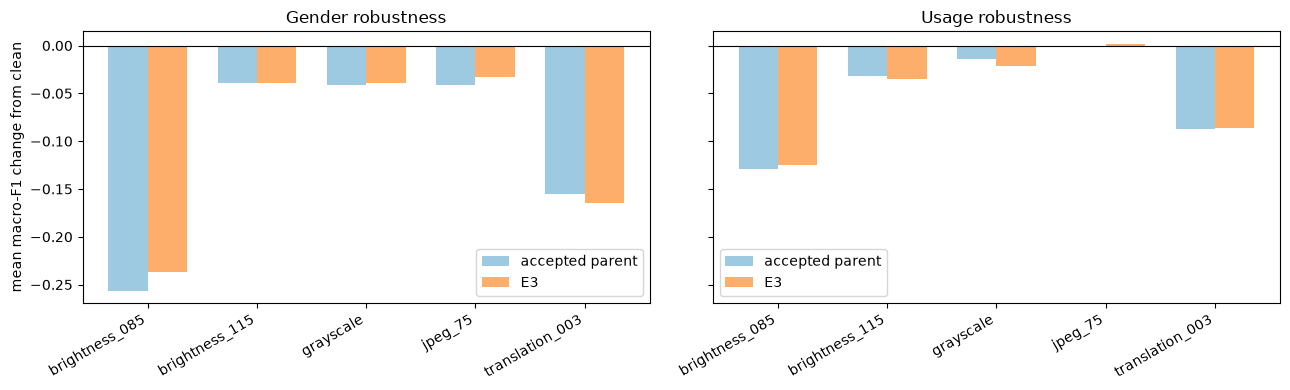

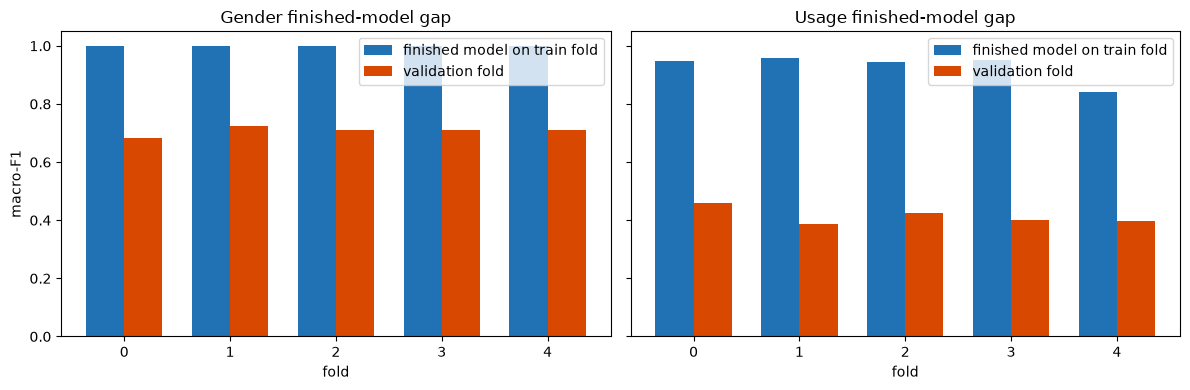

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e3_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="accepted parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e3_macro_f1"], 0.36, label="E3", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} final validation macro-F1")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e3_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = e3_class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.18, report["parent_f1"], 0.36, label="accepted parent", color="#9ecae1")
    axis.barh(y + 0.18, report["e3_f1"], 0.36, label="E3", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_xlabel("pooled OOF F1")
    axis.set_title(f"{target.title()} class comparison")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e3_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_e3_evidence[target]["confusion"].to_numpy(dtype=float)
    row_totals = confusion.sum(axis=1, keepdims=True)
    normalised = np.divide(confusion, row_totals, out=np.zeros_like(confusion), where=row_totals > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Oranges")
    labels = task3_e3_evidence[target]["confusion"].index.astype(str).tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} E3 row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e3_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e3_robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="accepted parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e3_change"], 0.36, label="E3", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("mean macro-F1 change from clean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e3_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e3_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["final_train_eval_macro_f1"], 0.36, label="finished model on train fold", color="#2171b5")
    axis.bar(x + 0.18, part["e3_macro_f1"], 0.36, label="validation fold", color="#d94801")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} finished-model gap")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e3_finished_model_gap.png", dpi=180, bbox_inches="tight")
plt.show()

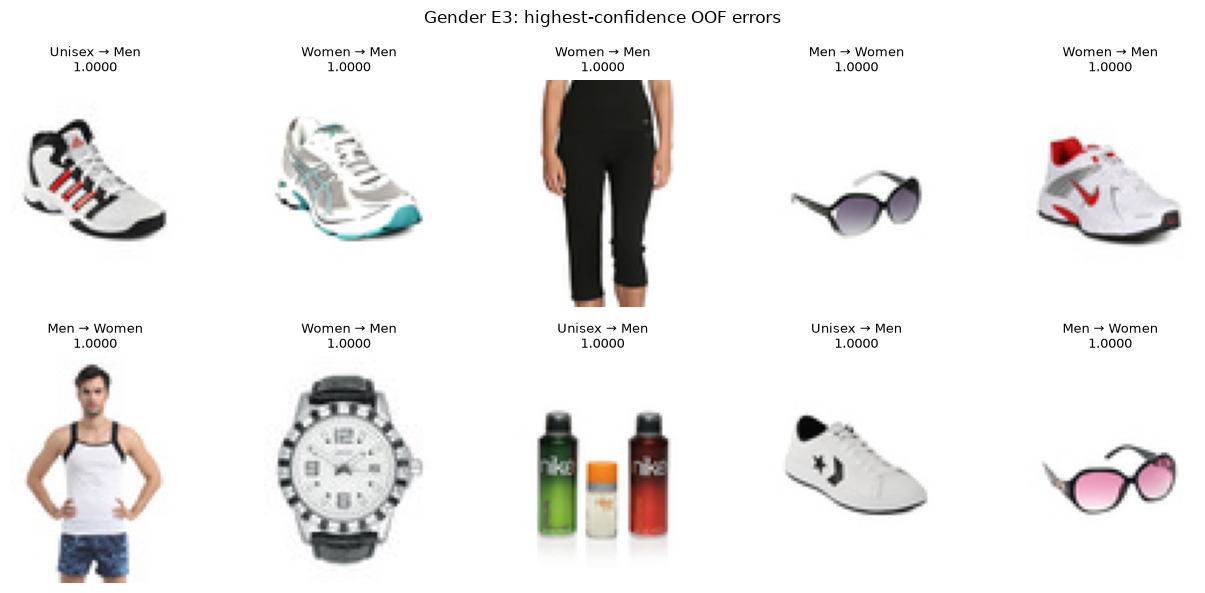

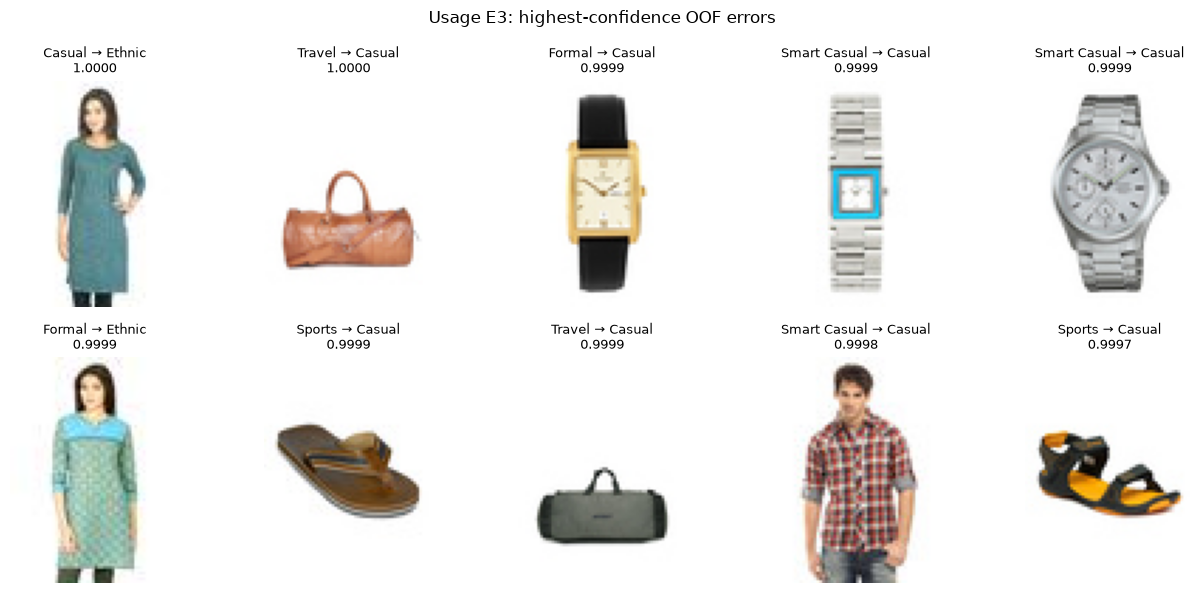

In [8]:
for target, evidence in task3_e3_evidence.items():
    examples = (evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10))
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), examples.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()} E3: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"e3_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()

### E3 result: reject both children under the frozen rules

| Target | Accepted parent macro-F1 | E3 macro-F1 | Primary gate | Decision |
|---|---:|---:|---:|---|
| Gender | 0.7118 | 0.7081 | ≥ 0.7218 | reject |
| Usage | 0.4082 | 0.4161 | ≥ 0.4182 | reject, close but below gate |

#### Gender E3 — reject class-balanced loss

Gender E3 fell about 0.0037 below E1 instead of gaining the required 0.0100. The paired
10,000-sample product-family bootstrap estimated a macro-F1 change of −0.0036 with a 95%
interval from −0.0157 to 0.0085, so the change is not reliably positive. Mean Boys, Girls,
and Unisex F1 was 0.5814, below both the 0.6048 gate and the parent's 0.5848. Boys improved
from 0.6222 to 0.6291 and Unisex from 0.5470 to 0.5532, but Girls fell from 0.5851 to
0.5620. Weighting moved errors among minority classes instead of improving the group.

Men and Women no-harm gates passed, every class retained non-zero recall, fold SD was
0.0149, calibration gates passed, and every corruption stayed within the allowed 0.02
margin. These secondary passes cannot rescue failed primary and paired gates. E1 remains
the accepted Gender parent.

#### Usage E3 — reject dropout, while recording a useful near miss

Usage E3 improved pooled macro-F1 by about 0.0079 to 0.4161, but the frozen gate required
0.4182. Macro-F1 without Home reached 0.4681, just below 0.4692. The family-bootstrap
interval for the change was −0.0069 to 0.0238, so it still includes no improvement.
Accuracy stayed at 0.8917. Casual, Ethnic, Formal, and Sports passed their floors; mean
NA/Travel F1 reached 0.2397 and both retained non-zero recall. Smart Casual moved from zero
to 0.0357, but Home and Party remained at zero. Fold SD was 0.0298, only 0.0005 inside its
limit. NLL, ECE, and robustness all passed. The direction is promising, but the prewritten
rule rejects a small uncertain gain. E2 remains the accepted Usage parent.

#### Capacity decision

The finished Gender models score about 0.999 macro-F1 on their training folds while their
validation folds score 0.6833–0.7238. Finished Usage training scores range from 0.8427 to
0.9584 while validation scores range from 0.3867 to 0.4608. These large gaps show
overfitting, not a model that is too small. They close only the **larger-capacity** gate.
They do not prove that a similarly sized architecture with a better structural bias cannot
generalise better. One parameter-matched residual architecture is therefore allowed; a large
ResNet or architecture sweep remains unjustified.

The E3 loss curves use the corrected sample-weight denominator. They are valid
class-weighted cross-entropy diagnostics, but they are not directly comparable with ordinary
unweighted NLL. Selection still uses pooled OOF macro-F1 and the frozen gates.


### E4 hypotheses — parameter-matched TinyResNet-18-PM

All executed E1–E3 models use the same SmallCNN. That is enough to compare augmentation,
loss weighting, and dropout, but it is not a real architecture comparison. The next child is
therefore one narrow residual network with almost the same parameter count. This tests a
different structural bias, not more capacity.

#### Locked architecture

- 3×3 stem, stride 1, with no early max-pool;
- stages of 12, 24, 48, and 96 channels, with two basic residual blocks per stage;
- downsample only at the first blocks of stages 2–4;
- global average pooling and one target-specific classifier;
- random initialisation only; no pretrained weights.

| Target | Role | Accepted parent | Parent loss kept | TinyResNet parameters | MACs |
|---|---|---|---|---:|---:|
| Gender | controlled architecture benchmark | E1 | ordinary cross-entropy | 394,865 | 94,268,640 |
| Usage | real replacement hypothesis | E2 | effective-number CE, β=0.999, cap=5.0 | 395,253 | 94,269,024 |

**Gender E4 hypothesis.** Delaying spatial reduction and retaining residual paths may preserve
small straps, collars, watch faces, footwear outlines, and other weak target-audience cues better
than SmallCNN's early pooling. Only the model architecture changes from Gender E1.

**Usage E4 hypothesis.** The same residual bias may improve unstable minority usage classes while
retaining the accepted E2 weighting. Only the model architecture changes from Usage E2. Rejected
brightness and dropout changes are not stacked.

Every other control stays fixed: `data/processed/splits.csv`, five folds in order, 80×60 RGB,
fold-only normalisation, seed 2753, batch size 128, AdamW, learning rate 0.001, weight decay
0.0001, cosine schedule, 30 epochs, no augmentation, and the final-epoch checkpoint.

#### Frozen E4 acceptance gates

Every applicable gate must pass.

| Gate | Gender E4 | Usage E4 |
|---|---:|---:|
| pooled OOF macro-F1 | ≥ 0.7218 | ≥ 0.4182 |
| macro-F1 without Home | — | ≥ 0.4692 |
| paired product-family bootstrap lower 95% bound | > 0 | > 0 |
| accuracy | ≥ 0.8668 | ≥ 0.8815 |
| fold macro-F1 SD | ≤ 0.0209 | ≤ 0.0303 |
| folds improved over their matching parent | ≥ 4 of 5 | ≥ 4 of 5 |
| NLL | ≤ 0.5437 | ≤ 0.3628 |
| ECE-15 | ≤ 0.0856 | ≤ 0.0431 |

No-harm guards are also frozen. Gender F1 must be at least Boys 0.6022, Girls 0.5651,
Men 0.8967, Unisex 0.5270, and Women 0.8678; mean Boys/Girls/Unisex F1 must reach 0.6048.
Usage F1 must be at least Casual 0.9118, Ethnic 0.8340, Formal 0.7559, NA 0.2099,
Sports 0.6551, and Travel 0.1869; mean NA/Smart Casual/Travel F1 must reach 0.1556.
Home and Party remain report-only because their supports are 1 and 12. No fold may lose more
than 0.02 macro-F1, and no corruption may be more than 0.02 worse than the exact parent.

Cost gates are ≤ 410,000 parameters, ≤ 105 million MACs, median L4 fold time ≤ 714 seconds
for Gender and ≤ 703 seconds for Usage, batch-one latency ≤ 1.00 ms and ≤ 1.02 ms respectively,
and peak memory ≤ 1.25× the matching parent.

Run seed 2753 first. If any gate fails, stop and retain Gender E1 or Usage E2. If all gates pass,
confirm with matched parent–child runs at seeds 2754 and 2755. A finalist must improve at all
three seeds with mean macro-F1 gain ≥ 0.010.


## 13. E4 evidence and decisions

The two parameter-matched residual children completed five registered folds at seed 2753.
This section loads their saved Drive evidence and compares each one only with its accepted
parent: Gender E1 and Usage E2. It applies the gates written above before looking at E4.


In [1]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image


def find_task3_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src/fashion").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the cloned repository.")


if "REPO_DIR" not in globals() or not (Path(REPO_DIR) / "src/fashion").is_dir():
    REPO_DIR = find_task3_project_root()
else:
    REPO_DIR = Path(REPO_DIR)

local_evidence = REPO_DIR / "results/evidence/task3"
drive_evidence = Path(DRIVE_TASK_DIR) if "DRIVE_TASK_DIR" in globals() else None
if (local_evidence / "experiments/t3_gender_e4_tinyresnet18_pm").is_dir():
    TASK3_E4_EVIDENCE_ROOT = local_evidence
elif drive_evidence is not None and drive_evidence.is_dir():
    TASK3_E4_EVIDENCE_ROOT = drive_evidence
else:
    raise FileNotFoundError(
        "Download the Task 3 evidence from Drive into results/evidence/task3 first."
    )


def read_task3_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def load_task3_experiment_evidence(target, artifact_dir, run_glob):
    target_dir = TASK3_E4_EVIDENCE_ROOT / artifact_dir / target
    aggregate_dir = target_dir / "aggregate"
    aggregate_files = (
        "metrics.json",
        "per_class.csv",
        "confusion_matrix.csv",
        "failure_index.csv",
        "oof_predictions.csv",
    )
    missing = [name for name in aggregate_files if not (aggregate_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing {target} aggregate evidence: {missing}")

    latest_by_fold = {}
    for run_dir in sorted(target_dir.glob(run_glob)):
        required = [run_dir / name for name in ("metrics.json", "history.csv", "robustness.csv")]
        if not all(path.is_file() for path in required):
            continue
        metrics = read_task3_json(run_dir / "metrics.json")
        latest_by_fold[int(metrics["validation_fold"])] = {
            "run_dir": run_dir,
            "metrics": metrics,
        }
    if set(latest_by_fold) != set(range(5)):
        raise RuntimeError(
            f"Expected completed folds 0-4 for {target}; found {sorted(latest_by_fold)}"
        )

    histories = []
    robustness = []
    for fold, record in sorted(latest_by_fold.items()):
        histories.append(pd.read_csv(record["run_dir"] / "history.csv").assign(fold=fold))
        robustness.append(pd.read_csv(record["run_dir"] / "robustness.csv").assign(fold=fold))
    return {
        "aggregate_dir": aggregate_dir,
        "metrics": read_task3_json(aggregate_dir / "metrics.json"),
        "per_class": pd.read_csv(aggregate_dir / "per_class.csv", keep_default_na=False),
        "confusion": pd.read_csv(
            aggregate_dir / "confusion_matrix.csv", index_col=0, keep_default_na=False
        ),
        "failures": pd.read_csv(aggregate_dir / "failure_index.csv", keep_default_na=False),
        "folds": latest_by_fold,
        "history": pd.concat(histories, ignore_index=True),
        "robustness": pd.concat(robustness, ignore_index=True),
    }


task3_e4_parents = {
    "gender": load_task3_experiment_evidence(
        "gender", "baseline", "t3_baseline_gender_smallcnn_f*"
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e2_class_balanced_ce",
        "t3_usage_e2_class_balanced_ce_usage_smallcnn_f*",
    ),
}
task3_e4_evidence = {
    "gender": load_task3_experiment_evidence(
        "gender",
        "experiments/t3_gender_e4_tinyresnet18_pm",
        "t3_gender_e4_tinyresnet18_pm_gender_tinyresnet18pm_f*",
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e4_tinyresnet18_pm",
        "t3_usage_e4_tinyresnet18_pm_usage_tinyresnet18pm_f*",
    ),
}

registry_path = REPO_DIR / "results/runs.csv"
if registry_path.is_file():
    registry = pd.read_csv(registry_path, keep_default_na=False)
    e4_registry = registry[registry["experiment_id"].isin(
        ["t3_gender_tinyresnet18_pm", "t3_usage_tinyresnet18_pm"]
    )]
    if len(e4_registry) != 10 or set(e4_registry["status"]) != {"complete"}:
        raise RuntimeError("The E4 registry does not contain ten completed folds.")
    print("Registry check: ten completed E4 folds.")
print(f"Loaded E4 evidence from: {TASK3_E4_EVIDENCE_ROOT}")


Registry check: ten completed E4 folds.
Loaded E4 evidence from: /home/dinhquan/personal/academic/RMIT/Machine-Learning/MLA2-eda/results/evidence/task3


In [2]:
e4_metric_rows = []
e4_class_rows = []
e4_fold_rows = []
e4_robustness_rows = []
e4_cost_rows = []
for target in ("gender", "usage"):
    parent = task3_e4_parents[target]
    child = task3_e4_evidence[target]
    metrics = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "nll", "ece_15"]
    if target == "usage":
        metrics.append("macro_f1_without_home")
    for metric in metrics:
        e4_metric_rows.append({
            "target": target,
            "metric": metric,
            "parent": parent["metrics"][metric],
            "e4": child["metrics"][metric],
            "change": child["metrics"][metric] - parent["metrics"][metric],
        })

    parent_classes = parent["per_class"].set_index("class_name")
    child_classes = child["per_class"].set_index("class_name")
    for class_name in parent_classes.index:
        e4_class_rows.append({
            "target": target,
            "class_name": class_name,
            "support": int(parent_classes.loc[class_name, "support"]),
            "parent_f1": parent_classes.loc[class_name, "f1"],
            "e4_f1": child_classes.loc[class_name, "f1"],
            "f1_change": child_classes.loc[class_name, "f1"] - parent_classes.loc[class_name, "f1"],
        })

    target_fold_rows = []
    for fold in range(5):
        parent_fold = parent["folds"][fold]["metrics"]
        child_fold = child["folds"][fold]["metrics"]
        row = {
            "target": target,
            "fold": fold,
            "parent_macro_f1": parent_fold["macro_f1"],
            "e4_macro_f1": child_fold["macro_f1"],
            "change": child_fold["macro_f1"] - parent_fold["macro_f1"],
            "final_train_eval_macro_f1": child_fold["final_train_eval_macro_f1"],
            "final_train_validation_gap": child_fold["final_train_validation_macro_f1_gap"],
            "train_seconds": child_fold["train_seconds"],
            "latency_ms_batch_1": child_fold["latency_ms_batch_1"],
            "peak_memory_ratio": child_fold["peak_memory_bytes"] / parent_fold["peak_memory_bytes"],
        }
        target_fold_rows.append(row)
        e4_fold_rows.append(row)

    parent_robustness = parent["robustness"].groupby("corruption")["macro_f1_change"].mean()
    child_robustness = child["robustness"].groupby("corruption")["macro_f1_change"].mean()
    for corruption in parent_robustness.index:
        e4_robustness_rows.append({
            "target": target,
            "corruption": corruption,
            "parent_change": parent_robustness[corruption],
            "e4_change": child_robustness[corruption],
            "difference": child_robustness[corruption] - parent_robustness[corruption],
        })

    target_folds = pd.DataFrame(target_fold_rows)
    e4_cost_rows.append({
        "target": target,
        "parameters": child["metrics"]["parameter_count"],
        "MACs": child["metrics"]["architecture_macs"],
        "median_train_seconds": target_folds["train_seconds"].median(),
        "median_latency_ms": target_folds["latency_ms_batch_1"].median(),
        "maximum_memory_ratio": target_folds["peak_memory_ratio"].max(),
    })

e4_metric_comparison = pd.DataFrame(e4_metric_rows)
e4_class_comparison = pd.DataFrame(e4_class_rows)
e4_fold_comparison = pd.DataFrame(e4_fold_rows)
e4_robustness_comparison = pd.DataFrame(e4_robustness_rows)
e4_cost_comparison = pd.DataFrame(e4_cost_rows)
display(e4_metric_comparison.round(4))
display(e4_class_comparison.round(4))
display(e4_fold_comparison.round(4))
display(e4_robustness_comparison.round(4))
display(e4_cost_comparison.round(4))


,target,metric,parent,e4,change
0,gender,accuracy,0.8768,0.8771,0.0003
1,gender,balanced_accuracy,0.6933,0.6876,-0.0057
2,gender,macro_f1,0.7118,0.7121,0.0003
3,gender,weighted_f1,0.8745,0.8738,-0.0007
4,gender,nll,0.5237,0.6803,0.1566
5,gender,ece_15,0.0756,0.0906,0.0150
6,usage,accuracy,0.8915,0.8799,-0.0116
7,usage,balanced_accuracy,0.3826,0.3582,-0.0244
8,usage,macro_f1,0.4082,0.3878,-0.0204
9,usage,weighted_f1,0.8876,0.8744,-0.0132


,target,class_name,support,parent_f1,e4_f1,f1_change
0,gender,Boys,684,0.6222,0.6467,0.0245
1,gender,Girls,543,0.5851,0.5740,-0.0111
2,gender,Men,17753,0.9167,0.9166,-0.0002
3,gender,Unisex,1766,0.5470,0.5365,-0.0105
4,gender,Women,12027,0.8878,0.8867,-0.0011
5,usage,Casual,25151,0.9318,0.9251,-0.0067
6,usage,Ethnic,2183,0.8540,0.8181,-0.0359
7,usage,Formal,1949,0.7759,0.7524,-0.0235
8,usage,Home,1,0.0000,0.0000,0.0000
9,usage,NA,61,0.2299,0.1687,-0.0612


,target,fold,parent_macro_f1,e4_macro_f1,change,final_train_eval_macro_f1,final_train_validation_gap,train_seconds,latency_ms_batch_1,peak_memory_ratio
0,gender,0,0.6982,0.7030,0.0049,0.9999,0.2969,460.2607,2.5546,1.2751
1,gender,1,0.7068,0.7091,0.0023,1.0000,0.2909,460.8754,2.5664,1.2759
2,gender,2,0.7048,0.7062,0.0014,1.0000,0.2938,467.2740,2.5927,1.2759
3,gender,3,0.7207,0.7235,0.0029,1.0000,0.2765,466.3837,2.5868,1.2759
4,gender,4,0.7279,0.7182,-0.0097,0.9999,0.2817,464.3822,2.5688,1.2759
5,usage,0,0.4086,0.4019,-0.0067,1.0000,0.5981,466.4633,2.5674,1.2759
6,usage,1,0.3818,0.3707,-0.0111,0.9977,0.6270,467.0850,2.5679,1.2759
7,usage,2,0.4362,0.4426,0.0063,0.9977,0.5552,466.6422,2.5514,1.2759
8,usage,3,0.3999,0.3474,-0.0525,0.9978,0.6503,465.4716,2.5785,1.2759
9,usage,4,0.3950,0.3663,-0.0287,0.8878,0.5215,466.5841,2.5744,1.2759


,target,corruption,parent_change,e4_change,difference
0,gender,brightness_085,-0.2562,-0.2418,0.0144
1,gender,brightness_115,-0.0386,-0.0525,-0.0139
2,gender,grayscale,-0.0414,-0.0210,0.0204
3,gender,jpeg_75,-0.0416,-0.0161,0.0255
4,gender,translation_003,-0.1551,-0.2012,-0.0460
5,usage,brightness_085,-0.1289,-0.1064,0.0224
6,usage,brightness_115,-0.0316,-0.0219,0.0097
7,usage,grayscale,-0.0145,0.0077,0.0222
8,usage,jpeg_75,-0.0007,-0.0010,-0.0002
9,usage,translation_003,-0.0869,-0.1357,-0.0488


,target,parameters,MACs,median_train_seconds,median_latency_ms,maximum_memory_ratio
0,gender,394865,94268640,464.3822,2.5688,1.2759
1,usage,395253,94269024,466.5841,2.5679,1.2759


In [3]:
def e4_confusion_macro_f1(confusion):
    true_positives = np.diagonal(confusion, axis1=1, axis2=2)
    support = confusion.sum(axis=2)
    predicted = confusion.sum(axis=1)
    denominator = support + predicted
    per_class = np.divide(
        2 * true_positives,
        denominator,
        out=np.zeros_like(true_positives, dtype=float),
        where=denominator > 0,
    )
    return per_class.mean(axis=1)


def e4_grouped_confusion_entries(group_index, flat_category, width):
    keys, counts = np.unique(group_index * width + flat_category, return_counts=True)
    return keys // width, keys % width, counts


def e4_weighted_group_confusions(weights, group_indices, categories, counts, width):
    result = np.zeros((len(weights), width), dtype=np.int64)
    for category in range(width):
        selected = categories == category
        if selected.any():
            result[:, category] = weights[:, group_indices[selected]] @ counts[selected]
    return result


def e4_paired_family_bootstrap(parent_path, child_path, class_count, *, samples=10_000, seed=2753, batch_size=50):
    columns = ["id", "product_family_group", "true_index", "predicted_index"]
    parent = pd.read_csv(parent_path, usecols=columns, keep_default_na=False).rename(
        columns={"product_family_group": "parent_group", "true_index": "parent_true", "predicted_index": "parent_predicted"}
    )
    child = pd.read_csv(child_path, usecols=columns, keep_default_na=False).rename(
        columns={"product_family_group": "child_group", "true_index": "child_true", "predicted_index": "child_predicted"}
    )
    paired = parent.merge(child, on="id", how="inner", validate="one_to_one")
    if len(paired) != len(parent) or len(paired) != len(child):
        raise ValueError("Parent and child OOF rows do not match one-to-one")
    if not paired["parent_group"].equals(paired["child_group"]):
        raise ValueError("Parent and child product-family groups disagree")
    if not paired["parent_true"].equals(paired["child_true"]):
        raise ValueError("Parent and child labels disagree")

    group_index, groups = pd.factorize(paired["parent_group"], sort=True)
    width = class_count * class_count
    parent_flat = paired["parent_true"].to_numpy() * class_count + paired["parent_predicted"].to_numpy()
    child_flat = paired["child_true"].to_numpy() * class_count + paired["child_predicted"].to_numpy()
    parent_group, parent_category, parent_count = e4_grouped_confusion_entries(
        group_index, parent_flat, width
    )
    child_group, child_category, child_count = e4_grouped_confusion_entries(
        group_index, child_flat, width
    )

    rng = np.random.default_rng(seed)
    deltas = np.empty(samples, dtype=float)
    for start in range(0, samples, batch_size):
        batch = min(batch_size, samples - start)
        draws = rng.integers(0, len(groups), size=(batch, len(groups)), dtype=np.int32)
        offsets = np.arange(batch, dtype=np.int64)[:, None] * len(groups)
        weights = np.bincount(
            (draws + offsets).ravel(), minlength=batch * len(groups)
        ).reshape(batch, len(groups))
        parent_confusion = e4_weighted_group_confusions(
            weights, parent_group, parent_category, parent_count, width
        ).reshape(batch, class_count, class_count)
        child_confusion = e4_weighted_group_confusions(
            weights, child_group, child_category, child_count, width
        ).reshape(batch, class_count, class_count)
        deltas[start:start + batch] = (
            e4_confusion_macro_f1(child_confusion) - e4_confusion_macro_f1(parent_confusion)
        )
    return {
        "rows": len(paired),
        "families": len(groups),
        "samples": samples,
        "seed": seed,
        "mean_delta": deltas.mean(),
        "lower_95": np.quantile(deltas, 0.025),
        "upper_95": np.quantile(deltas, 0.975),
        "probability_positive": np.mean(deltas > 0),
    }


e4_bootstrap = {}
for target in ("gender", "usage"):
    parent_path = task3_e4_parents[target]["aggregate_dir"] / "oof_predictions.csv"
    child_path = task3_e4_evidence[target]["aggregate_dir"] / "oof_predictions.csv"
    class_count = len(task3_e4_evidence[target]["per_class"])
    e4_bootstrap[target] = e4_paired_family_bootstrap(
        parent_path, child_path, class_count
    )
display(pd.DataFrame.from_dict(e4_bootstrap, orient="index").round(4))


,rows,families,samples,seed,mean_delta,lower_95,upper_95,probability_positive
gender,32773,22905,10000,2753,0.0002,-0.0144,0.0154,0.5130
usage,32772,22904,10000,2753,-0.0203,-0.0400,-0.0034,0.0089


In [4]:
e4_gate_rows = []


def add_e4_gate(target, gate, observed, rule, passed):
    e4_gate_rows.append({
        "target": target,
        "gate": gate,
        "observed": observed,
        "rule": rule,
        "passed": bool(passed),
    })


gender_metrics = task3_e4_evidence["gender"]["metrics"]
gender_classes = task3_e4_evidence["gender"]["per_class"].set_index("class_name")
gender_folds = e4_fold_comparison.query("target == 'gender'")
gender_robustness = e4_robustness_comparison.query("target == 'gender'")
gender_cost = e4_cost_comparison.set_index("target").loc["gender"]
add_e4_gate("gender", "pooled OOF macro-F1", gender_metrics["macro_f1"], "≥ 0.7218", gender_metrics["macro_f1"] >= 0.7218)
add_e4_gate("gender", "paired family-bootstrap lower 95% bound", e4_bootstrap["gender"]["lower_95"], "> 0", e4_bootstrap["gender"]["lower_95"] > 0)
add_e4_gate("gender", "accuracy", gender_metrics["accuracy"], "≥ 0.8668", gender_metrics["accuracy"] >= 0.8668)
add_e4_gate("gender", "fold macro-F1 SD", gender_folds["e4_macro_f1"].std(ddof=1), "≤ 0.0209", gender_folds["e4_macro_f1"].std(ddof=1) <= 0.0209)
add_e4_gate("gender", "folds improved", int((gender_folds["change"] > 0).sum()), "≥ 4 of 5", (gender_folds["change"] > 0).sum() >= 4)
add_e4_gate("gender", "worst fold change", gender_folds["change"].min(), "≥ -0.02", gender_folds["change"].min() >= -0.02)
add_e4_gate("gender", "NLL", gender_metrics["nll"], "≤ 0.5437", gender_metrics["nll"] <= 0.5437)
add_e4_gate("gender", "ECE-15", gender_metrics["ece_15"], "≤ 0.0856", gender_metrics["ece_15"] <= 0.0856)
for class_name, floor in {"Boys": 0.6022, "Girls": 0.5651, "Men": 0.8967, "Unisex": 0.5270, "Women": 0.8678}.items():
    observed = gender_classes.loc[class_name, "f1"]
    add_e4_gate("gender", f"{class_name} F1", observed, f"≥ {floor:.4f}", observed >= floor)
gender_minority_mean = gender_classes.loc[["Boys", "Girls", "Unisex"], "f1"].mean()
add_e4_gate("gender", "mean Boys/Girls/Unisex F1", gender_minority_mean, "≥ 0.6048", gender_minority_mean >= 0.6048)
add_e4_gate("gender", "worst corruption change versus parent", gender_robustness["difference"].min(), "≥ -0.02", gender_robustness["difference"].min() >= -0.02)
add_e4_gate("gender", "parameters", gender_cost["parameters"], "≤ 410,000", gender_cost["parameters"] <= 410_000)
add_e4_gate("gender", "MACs", gender_cost["MACs"], "≤ 105,000,000", gender_cost["MACs"] <= 105_000_000)
add_e4_gate("gender", "median L4 fold time", gender_cost["median_train_seconds"], "≤ 714 s", gender_cost["median_train_seconds"] <= 714)
add_e4_gate("gender", "batch-one latency", gender_cost["median_latency_ms"], "≤ 1.00 ms", gender_cost["median_latency_ms"] <= 1.00)
add_e4_gate("gender", "peak memory ratio", gender_cost["maximum_memory_ratio"], "≤ 1.25×", gender_cost["maximum_memory_ratio"] <= 1.25)

usage_metrics = task3_e4_evidence["usage"]["metrics"]
usage_classes = task3_e4_evidence["usage"]["per_class"].set_index("class_name")
usage_folds = e4_fold_comparison.query("target == 'usage'")
usage_robustness = e4_robustness_comparison.query("target == 'usage'")
usage_cost = e4_cost_comparison.set_index("target").loc["usage"]
add_e4_gate("usage", "pooled OOF macro-F1", usage_metrics["macro_f1"], "≥ 0.4182", usage_metrics["macro_f1"] >= 0.4182)
add_e4_gate("usage", "macro-F1 without Home", usage_metrics["macro_f1_without_home"], "≥ 0.4692", usage_metrics["macro_f1_without_home"] >= 0.4692)
add_e4_gate("usage", "paired family-bootstrap lower 95% bound", e4_bootstrap["usage"]["lower_95"], "> 0", e4_bootstrap["usage"]["lower_95"] > 0)
add_e4_gate("usage", "accuracy", usage_metrics["accuracy"], "≥ 0.8815", usage_metrics["accuracy"] >= 0.8815)
add_e4_gate("usage", "fold macro-F1 SD", usage_folds["e4_macro_f1"].std(ddof=1), "≤ 0.0303", usage_folds["e4_macro_f1"].std(ddof=1) <= 0.0303)
add_e4_gate("usage", "folds improved", int((usage_folds["change"] > 0).sum()), "≥ 4 of 5", (usage_folds["change"] > 0).sum() >= 4)
add_e4_gate("usage", "worst fold change", usage_folds["change"].min(), "≥ -0.02", usage_folds["change"].min() >= -0.02)
add_e4_gate("usage", "NLL", usage_metrics["nll"], "≤ 0.3628", usage_metrics["nll"] <= 0.3628)
add_e4_gate("usage", "ECE-15", usage_metrics["ece_15"], "≤ 0.0431", usage_metrics["ece_15"] <= 0.0431)
for class_name, floor in {"Casual": 0.9118, "Ethnic": 0.8340, "Formal": 0.7559, "NA": 0.2099, "Sports": 0.6551, "Travel": 0.1869}.items():
    observed = usage_classes.loc[class_name, "f1"]
    add_e4_gate("usage", f"{class_name} F1", observed, f"≥ {floor:.4f}", observed >= floor)
usage_minority_mean = usage_classes.loc[["NA", "Smart Casual", "Travel"], "f1"].mean()
add_e4_gate("usage", "mean NA/Smart Casual/Travel F1", usage_minority_mean, "≥ 0.1556", usage_minority_mean >= 0.1556)
add_e4_gate("usage", "worst corruption change versus parent", usage_robustness["difference"].min(), "≥ -0.02", usage_robustness["difference"].min() >= -0.02)
add_e4_gate("usage", "parameters", usage_cost["parameters"], "≤ 410,000", usage_cost["parameters"] <= 410_000)
add_e4_gate("usage", "MACs", usage_cost["MACs"], "≤ 105,000,000", usage_cost["MACs"] <= 105_000_000)
add_e4_gate("usage", "median L4 fold time", usage_cost["median_train_seconds"], "≤ 703 s", usage_cost["median_train_seconds"] <= 703)
add_e4_gate("usage", "batch-one latency", usage_cost["median_latency_ms"], "≤ 1.02 ms", usage_cost["median_latency_ms"] <= 1.02)
add_e4_gate("usage", "peak memory ratio", usage_cost["maximum_memory_ratio"], "≤ 1.25×", usage_cost["maximum_memory_ratio"] <= 1.25)

e4_gate_table = pd.DataFrame(e4_gate_rows)
e4_decisions = e4_gate_table.groupby("target").agg(
    accepted=("passed", "all"),
    passed_gates=("passed", "sum"),
    total_gates=("passed", "size"),
)
display(e4_gate_table.round({"observed": 4}))
display(e4_decisions)


,target,gate,observed,rule,passed
0,gender,pooled OOF macro-F1,7.121000e-01,≥ 0.7218,False
1,gender,paired family-bootstrap lower 95% bound,-1.440000e-02,> 0,False
2,gender,accuracy,8.771000e-01,≥ 0.8668,True
3,gender,fold macro-F1 SD,8.600000e-03,≤ 0.0209,True
4,gender,folds improved,4.000000e+00,≥ 4 of 5,True
5,gender,worst fold change,-9.700000e-03,≥ -0.02,True
6,gender,NLL,6.803000e-01,≤ 0.5437,False
7,gender,ECE-15,9.060000e-02,≤ 0.0856,False
8,gender,Boys F1,6.467000e-01,≥ 0.6022,True
9,gender,Girls F1,5.740000e-01,≥ 0.5651,True


,accepted,passed_gates,total_gates
target,,,
gender,False,12,20
usage,False,4,22


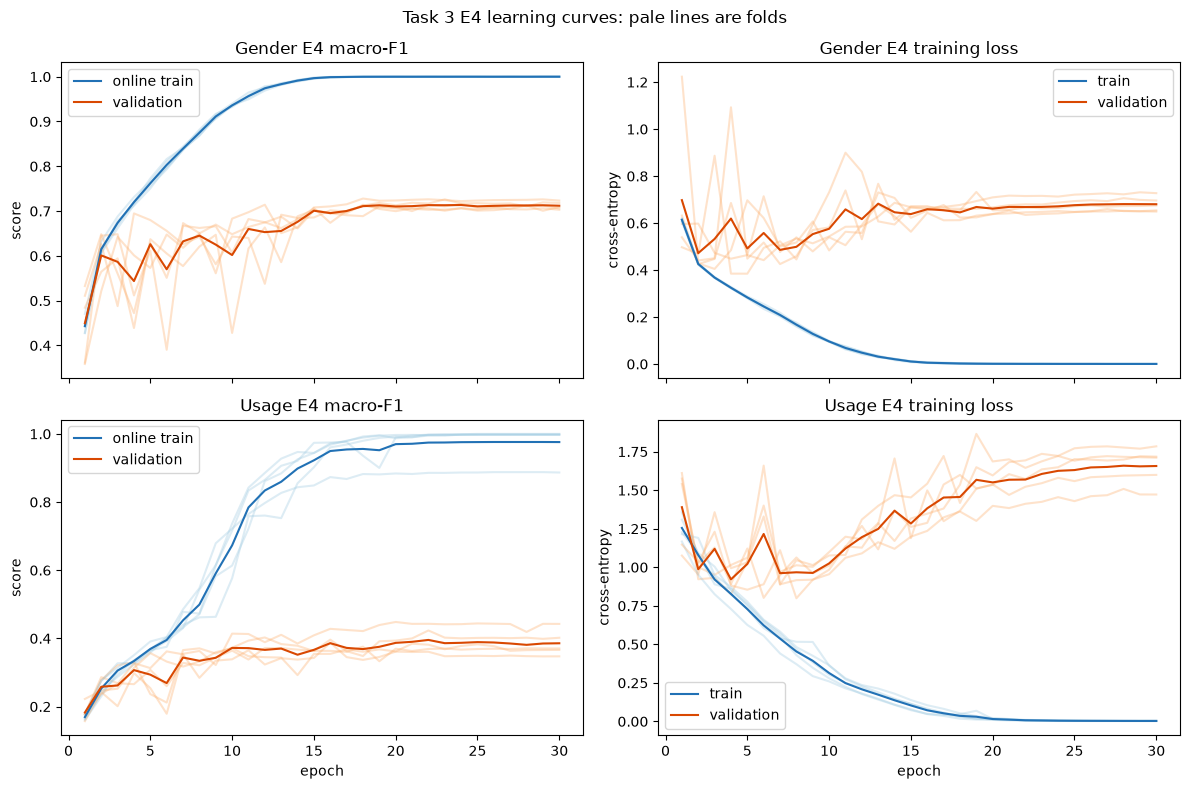

In [5]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_e4_evidence[target]["history"]
    for fold, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} E4 macro-F1")
    axes[row, 1].set_title(f"{target.title()} E4 training loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("cross-entropy")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 E4 learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e4_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


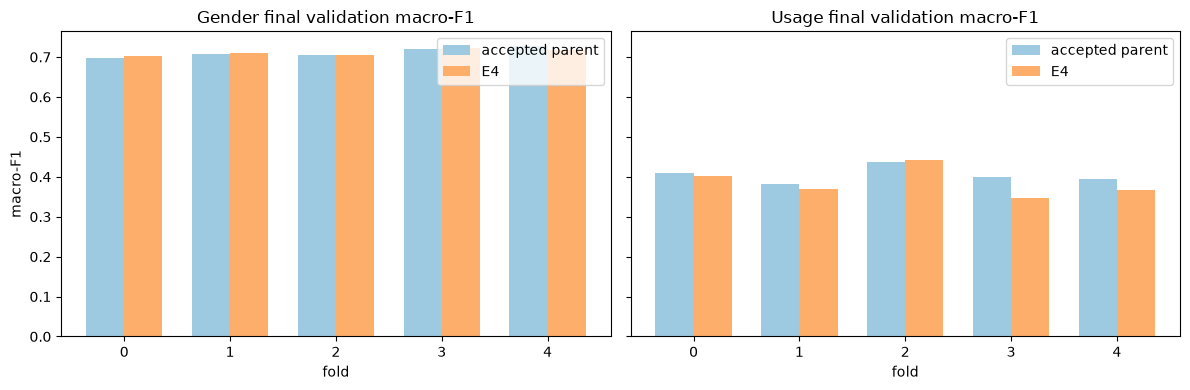

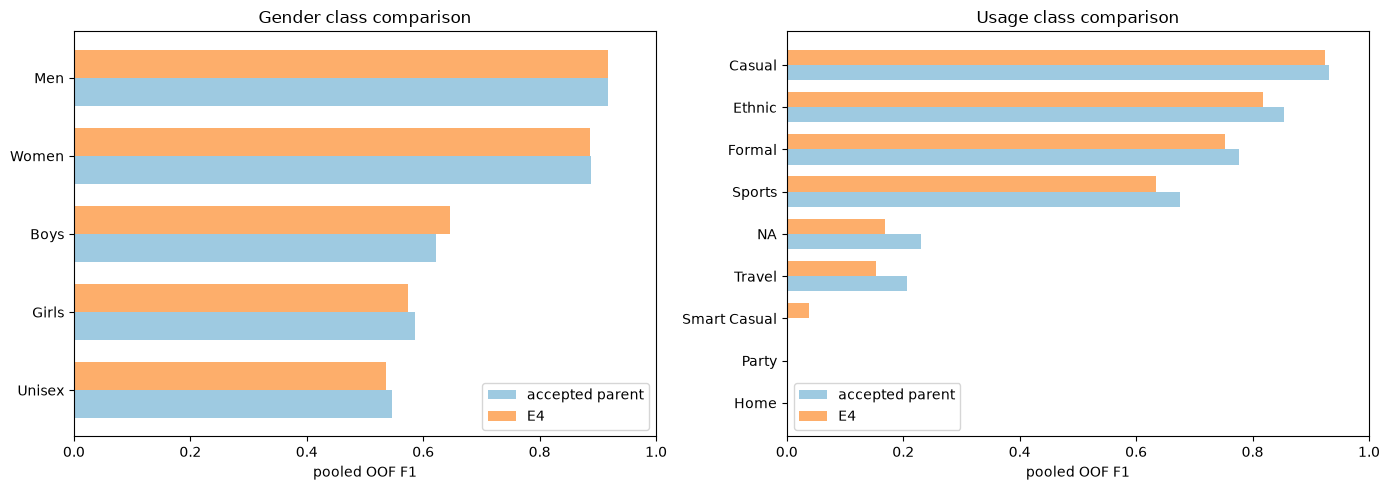

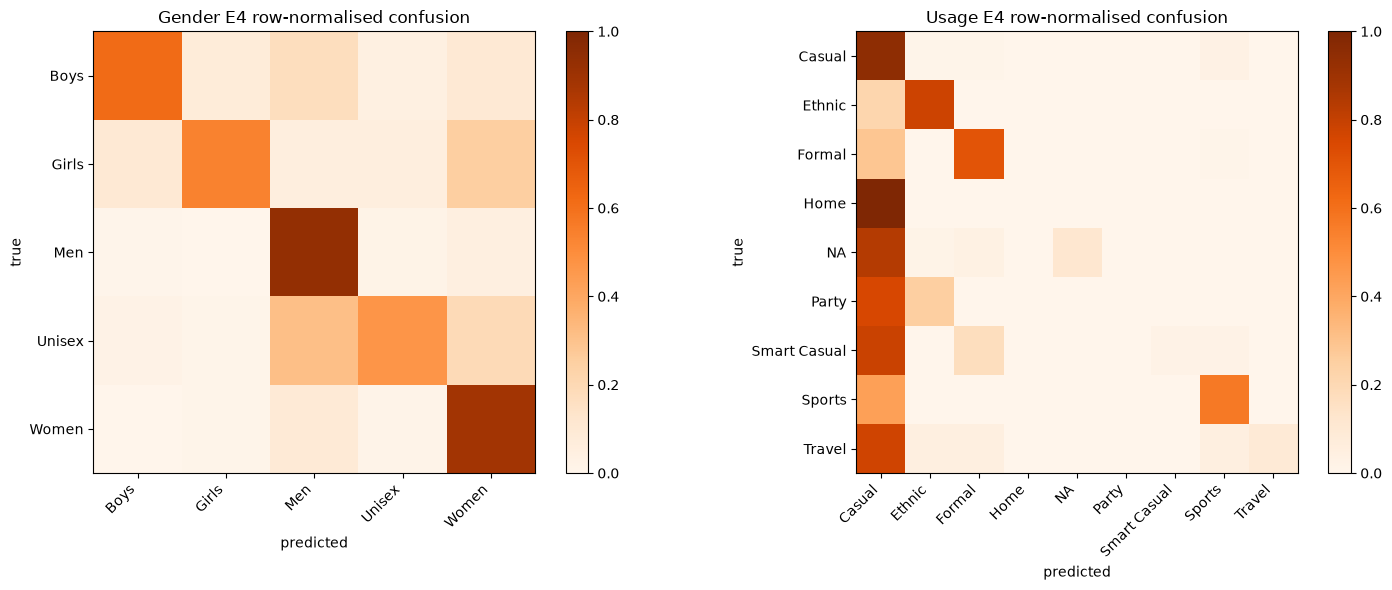

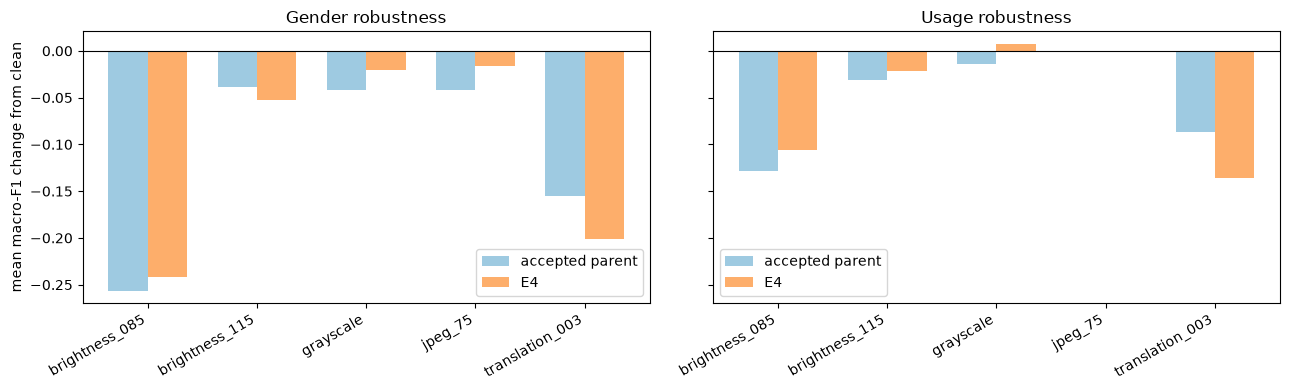

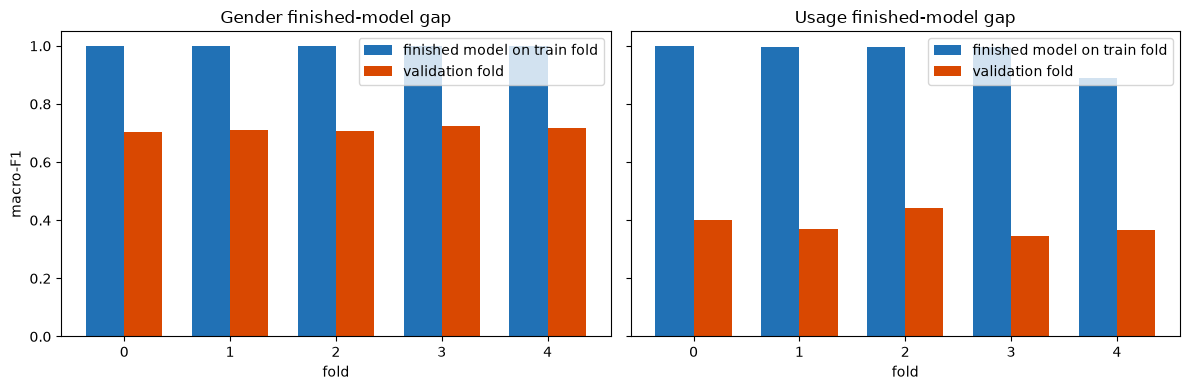

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e4_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="accepted parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e4_macro_f1"], 0.36, label="E4", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} final validation macro-F1")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e4_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = e4_class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.18, report["parent_f1"], 0.36, label="accepted parent", color="#9ecae1")
    axis.barh(y + 0.18, report["e4_f1"], 0.36, label="E4", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_xlabel("pooled OOF F1")
    axis.set_title(f"{target.title()} class comparison")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e4_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_e4_evidence[target]["confusion"].to_numpy(dtype=float)
    row_totals = confusion.sum(axis=1, keepdims=True)
    normalised = np.divide(confusion, row_totals, out=np.zeros_like(confusion), where=row_totals > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Oranges")
    labels = task3_e4_evidence[target]["confusion"].index.astype(str).tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} E4 row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e4_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e4_robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="accepted parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e4_change"], 0.36, label="E4", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("mean macro-F1 change from clean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e4_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e4_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["final_train_eval_macro_f1"], 0.36, label="finished model on train fold", color="#2171b5")
    axis.bar(x + 0.18, part["e4_macro_f1"], 0.36, label="validation fold", color="#d94801")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} finished-model gap")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e4_finished_model_gap.png", dpi=180, bbox_inches="tight")
plt.show()


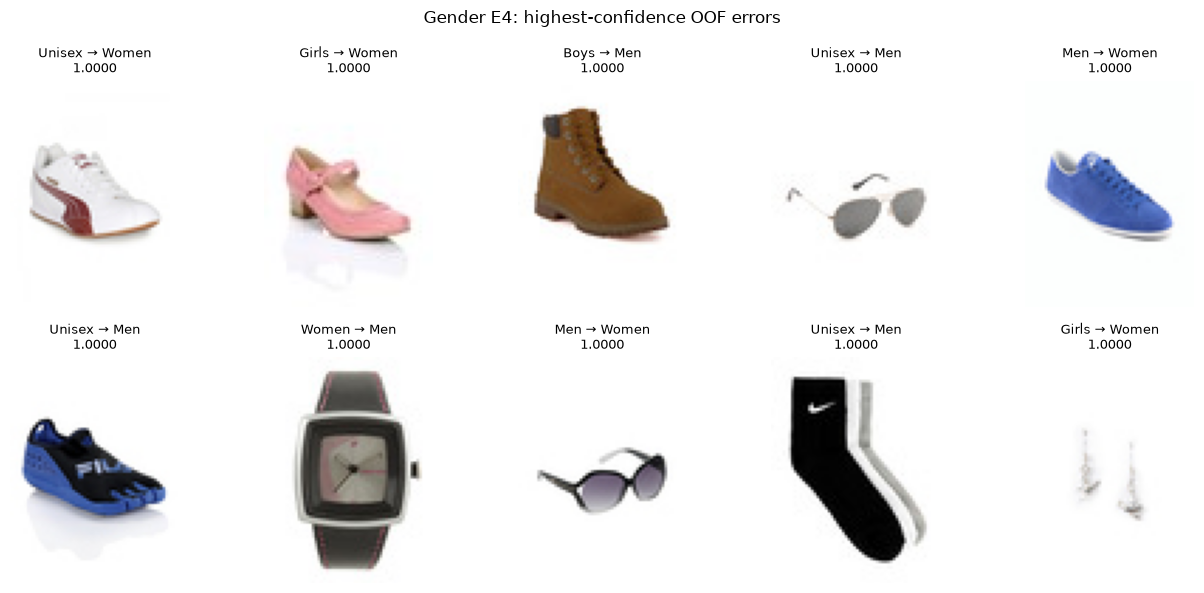

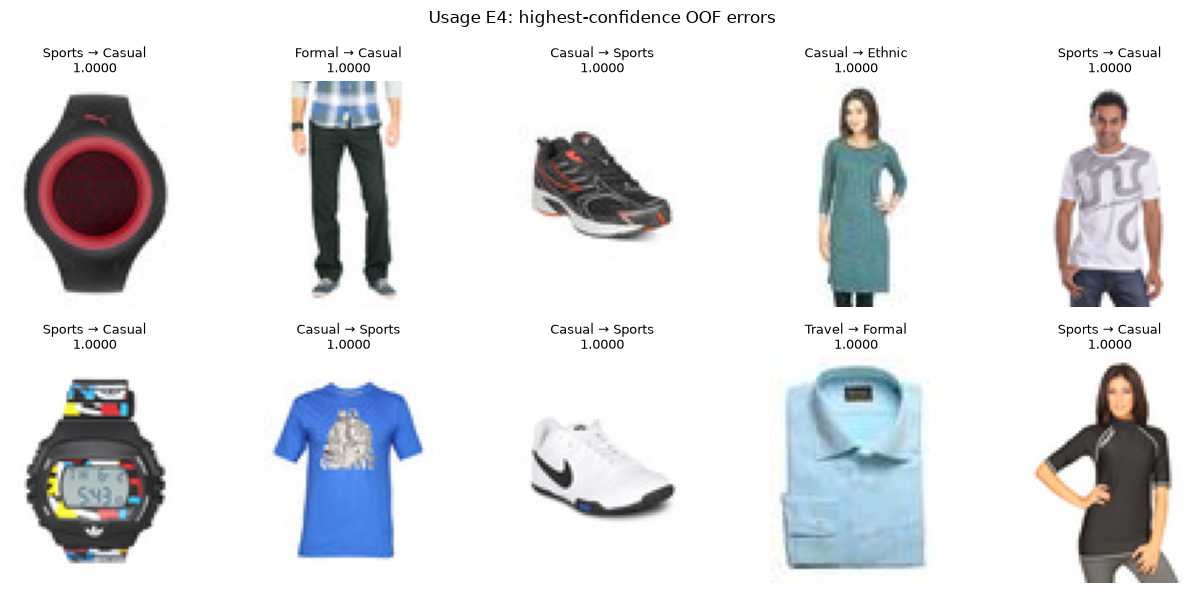

In [7]:
for target, evidence in task3_e4_evidence.items():
    examples = (evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10))
    available = examples[examples["path"].map(lambda value: (REPO_DIR / value).is_file())]
    if len(available) != 10:
        print(
            f"Skipped {target} E4 image gallery: raw teacher images are not present locally. "
            "The saved failure table still contains all selected IDs and scores."
        )
        continue
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), available.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()} E4: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"e4_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()


### E4 result: reject TinyResNet for both targets

| Target | Accepted parent macro-F1 | E4 macro-F1 | Change | Frozen primary gate | Decision |
|---|---:|---:|---:|---:|---|
| Gender | 0.7118 | 0.7121 | +0.0003 | ≥ 0.7218 | reject |
| Usage | 0.4082 | 0.3878 | −0.0204 | ≥ 0.4182 | reject |

#### Gender E4 — a stable but negligible architecture change

TinyResNet improved four of five folds, but only by 0.0014–0.0049. Fold 4 fell by 0.0097,
leaving pooled macro-F1 almost unchanged at 0.7121. The paired 10,000-sample
product-family bootstrap estimated a change of +0.0002 with a 95% interval from −0.0144
to +0.0154. This is not reliable evidence of improvement and misses the required 0.7218.

All five individual class floors passed. Boys improved by 0.0245, but Girls and Unisex fell,
so mean Boys/Girls/Unisex F1 was only 0.5857 instead of the required 0.6048. Accuracy and
fold stability passed. Calibration did not: NLL rose from 0.5237 to 0.6803 and ECE-15 rose
from 0.0756 to 0.0906. Translation robustness was 0.0460 worse than E1, beyond the 0.02
guard. The model met its parameter, MAC, and training-time budgets, but median latency was
2.5688 ms against 1.00 ms and peak memory reached 1.2759× E1 against 1.25×.

#### Usage E4 — clear regression from the accepted E2 parent

Usage macro-F1 fell from 0.4082 to 0.3878, and macro-F1 without Home fell from 0.4592 to
0.4363. Only fold 2 improved. The other four fell, with fold 3 losing 0.0525. Fold SD rose
to 0.0373. The paired bootstrap interval was entirely negative, from −0.0400 to −0.0034,
so this is evidence that E4 is worse, not just an uncertain result.

Casual passed its floor and Smart Casual moved from 0 to 0.0385 F1. Those gains did not
offset lower Ethnic, Formal, NA, Sports, and Travel F1. Mean NA/Smart Casual/Travel F1 was
0.1203 against the 0.1556 gate. Accuracy, NLL, ECE-15, translation robustness, latency, and
memory also failed their frozen guards. Parameters, MACs, and training time passed.

#### Architecture judgement

The parameter match did its job: this was a fair architecture test, not a hidden capacity
increase. Its result is still negative. Gender training macro-F1 was essentially 1.0 while
validation stayed near 0.70–0.72. Usage showed even larger finished-model gaps on four folds.
Residual connections and later spatial reduction therefore did not solve the generalisation
problem. Extra seeds are not allowed because seed 2753 failed several frozen gates.

Gender E1 and Usage E2 remain the accepted parents. E4 is useful as the required real
architecture comparison, but it is not eligible for final selection.


## 14. E5 hypotheses — test the remaining causes directly

E4 rejected one parameter-matched residual network. It did **not** show that architecture no
longer matters. Gender E1 and E4 both have about 390,000 parameters, and both finish near perfect
training macro-F1. The next Gender test must therefore change capacity and downsampling rather
than rearrange roughly the same capacity. Usage has a different diagnosis: its accepted E2 model
is strongly overconfident around ambiguous and conflicting hard labels, so its next test changes
the target distribution rather than the network. The two hypotheses remain separate.

### Gender E5 hypothesis — CompactBlurCNN

#### Reasoning from the observed evidence

Gender E1 finishes with mean training macro-F1 0.9988 and mean validation macro-F1 0.7117, a
0.2871 gap. That is direct evidence of memorisation. The classifier head is not a large dense
head: global average pooling is followed by only a `256→5` linear layer with 1,285 parameters.
The capacity is concentrated earlier. The final `128→256` convolution has 294,912 parameters,
about 76% of E1. E4 retained 394,865 parameters, so its failure rules out that residual layout,
not a lower-capacity architecture. E1 also loses 0.1551 macro-F1 under a small translation. Its
max-pooling may discard or alias the small image regions identified in the EDA.

**Hypothesis.** A much smaller CNN with fixed anti-aliased downsampling will have less capacity to
memorise product-family details and will be less sensitive to small shifts. It should reduce the
train–validation gap while improving clean macro-F1 and translation robustness.

#### Exact one-factor test

The accepted parent is Gender E1 SmallCNN with ordinary cross-entropy. Replace only the model
architecture with `CompactBlurCNN`:

1. `Conv3×3 3→24`, BatchNorm, ReLU, then fixed `3×3` BlurPool with stride 2;
2. `Conv3×3 24→48`, BatchNorm, ReLU, then the same BlurPool;
3. `Conv3×3 48→96`, BatchNorm, ReLU, then the same BlurPool;
4. depthwise `Conv3×3 96→96`, BatchNorm, ReLU;
5. pointwise `Conv1×1 96→128`, BatchNorm, ReLU;
6. adaptive global average pooling and `Linear 128→5`.

BlurPool uses the fixed binomial kernel `[[1,2,1],[2,4,2],[1,2,1]] / 16`. The target design has
67,069 trainable parameters and about 29.5 million MACs. This is about 17.2% of E1's parameters,
while retaining a final spatial grid near `10×8`. It is meaningfully different from E1's large
standard convolutions and max-pooling and from E4's parameter-matched residual blocks.

Hold ordinary cross-entropy, no class weights, no augmentation, no dropout, no label smoothing,
80×60 RGB, fold-only normalisation, batch size 128, AdamW, learning rate 0.001, weight decay
0.0001, cosine decay, 30 final-checkpoint epochs, seed 2753, and the five canonical folds fixed.
Train from scratch and parent every fold directly from Gender E1.

#### Frozen Gender E5 gates

All gates must pass: pooled macro-F1 ≥ 0.7218; paired product-family bootstrap lower 95% bound
> 0; at least four folds improve; worst fold change ≥ −0.02; accuracy ≥ 0.8668; fold macro-F1
SD ≤ 0.0209; mean finished-model train–validation gap ≤ 0.2371; Boys/Girls/Unisex mean F1
≥ 0.6048; class floors Boys 0.6022, Girls 0.5651, Men 0.8967, Unisex 0.5270, and Women
0.8678; NLL ≤ 0.5437; ECE-15 ≤ 0.0856; translation change ≥ −0.1051; and no other corruption
more than 0.02 worse than E1. The architecture must also remain at most 100,000 parameters and
35 million MACs, with batch-one latency ≤ 1.00 ms and peak memory no greater than E1.

Run seed 2753 first. A failed gate rejects only this CompactBlurCNN hypothesis and retains E1; it
does **not** prove that every architecture change is exhausted. The learning curves decide the
next incremental architecture hypothesis: underfitting would support a controlled width increase,
while a smaller gap without a validation gain would point away from capacity and toward missing
visual signal or a different invariance. Only a full pass permits confirmation seeds 2754–2755.

### Usage E5 hypothesis — class-balanced label smoothing

#### Reasoning from the observed evidence

Usage E2 is the accepted parent, but pooled macro-F1 is only 0.4082. Home, Party, and Smart
Casual have zero F1; NA is 0.2299 and Travel is 0.2069. The rare tail creates a real ceiling, yet
it does not explain every error. There are 3,556 E2 OOF errors, including 1,249 Sports→Casual and
479 Formal→Casual errors. E2 also makes 278 wrong predictions with confidence at least 0.99.
The 1,232 rows from 238 product families with conflicting Usage labels are much harder than
consistent families: E2 accuracy is 0.6843 versus 0.8996. E3 dropout improved macro-F1 by 0.0079
and improved NLL and ECE even though it missed the frozen acceptance gates. Together, these
observations support hard-label memorisation as a remaining, testable cause.

**Hypothesis.** Mild label smoothing will reduce unjustified confidence and the train–validation
gap without removing E2's useful rare-class weighting. This should improve mixed-family NLL and
supported minority recall. It cannot solve classes with almost no examples, so Home and Party
remain report-only.

#### Exact one-factor test

The accepted parent is Usage E2 SmallCNN with fold-only effective-number weights (`beta=0.999`,
cap 5.0`). Add only label smoothing with `epsilon=0.05`. For nine classes, the true-class target
is 0.95 and every other target is 0.00625. Preserve the E2 example weight `w_y` and compute
`sum(w_y * soft_target_CE) / sum(w_y)`; do not separately weight each non-target term.

Hold SmallCNN, the fold-only E2 weights, 80×60 RGB, no augmentation, no dropout, AdamW, learning
rate 0.001, weight decay 0.0001, cosine decay, 30 final-checkpoint epochs, seed 2753, and the five
canonical folds fixed. Train from scratch and parent every fold directly from Usage E2.

#### Frozen Usage E5 gates

All gates must pass: macro-F1 ≥ 0.4182; macro-F1 without Home ≥ 0.4692; paired product-family
bootstrap lower 95% bound > 0; at least four folds improve; worst fold change ≥ −0.02; fold SD
≤ 0.0303; accuracy ≥ 0.8815; class floors Casual 0.9118, Ethnic 0.8340, Formal 0.7559, NA
0.2099, Sports 0.6551, and Travel 0.1869; mean NA/Smart Casual/Travel F1 ≥ 0.1556; NLL ≤ 0.3628;
ECE-15 ≤ 0.0431; and no corruption more than 0.02 worse than E2. Home and Party remain
report-only. The diagnostics must also report wrong predictions at confidence ≥ 0.99 and NLL
separately for mixed-label and label-consistent product families.

Run seed 2753 first. A failed gate rejects label smoothing and retains Usage E2. It does not
authorise an unrelated model automatically: the failure pattern must first identify the next
single-factor hypothesis. Only a full pass permits matched confirmation seeds 2754–2755.


## 15. E5 evidence and decisions

Both E5 children completed all five canonical folds at seed 2753. This section loads the saved
artifacts with the same local evidence path used by the baseline and E4 analyses. CompactBlurCNN
is compared only with Gender E1. Label smoothing is compared only with Usage E2. Every decision
uses the gates frozen above before training.


In [ ]:
import json
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
from IPython.display import display
from PIL import Image


def find_task3_project_root(start=None):
    start = Path.cwd() if start is None else Path(start)
    for candidate in (start.resolve(), *start.resolve().parents):
        if (candidate / "src/fashion").is_dir() and (candidate / "notebooks").is_dir():
            return candidate
    raise FileNotFoundError("Run this notebook from inside the cloned repository.")


if "REPO_DIR" not in globals() or not (Path(REPO_DIR) / "src/fashion").is_dir():
    REPO_DIR = find_task3_project_root()
else:
    REPO_DIR = Path(REPO_DIR)

local_evidence = REPO_DIR / "results/evidence/task3"
drive_evidence = Path(DRIVE_TASK_DIR) if "DRIVE_TASK_DIR" in globals() else None
if (local_evidence / "experiments/t3_gender_e5_compact_blur_cnn").is_dir():
    TASK3_E5_EVIDENCE_ROOT = local_evidence
elif drive_evidence is not None and drive_evidence.is_dir():
    TASK3_E5_EVIDENCE_ROOT = drive_evidence
else:
    raise FileNotFoundError(
        "Download the Task 3 evidence from Drive into results/evidence/task3 first."
    )


def read_task3_json(path):
    return json.loads(Path(path).read_text(encoding="utf-8"))


def load_task3_experiment_evidence(target, artifact_dir, run_glob):
    target_dir = TASK3_E5_EVIDENCE_ROOT / artifact_dir / target
    aggregate_dir = target_dir / "aggregate"
    aggregate_files = (
        "metrics.json",
        "per_class.csv",
        "confusion_matrix.csv",
        "failure_index.csv",
        "oof_predictions.csv",
    )
    missing = [name for name in aggregate_files if not (aggregate_dir / name).is_file()]
    if missing:
        raise FileNotFoundError(f"Missing {target} aggregate evidence: {missing}")

    latest_by_fold = {}
    for run_dir in sorted(target_dir.glob(run_glob)):
        required = [run_dir / name for name in ("metrics.json", "history.csv", "robustness.csv")]
        if not all(path.is_file() for path in required):
            continue
        metrics = read_task3_json(run_dir / "metrics.json")
        latest_by_fold[int(metrics["validation_fold"])] = {
            "run_dir": run_dir,
            "metrics": metrics,
        }
    if set(latest_by_fold) != set(range(5)):
        raise RuntimeError(
            f"Expected completed folds 0-4 for {target}; found {sorted(latest_by_fold)}"
        )

    histories = []
    robustness = []
    for fold, record in sorted(latest_by_fold.items()):
        histories.append(pd.read_csv(record["run_dir"] / "history.csv").assign(fold=fold))
        robustness.append(pd.read_csv(record["run_dir"] / "robustness.csv").assign(fold=fold))
    return {
        "aggregate_dir": aggregate_dir,
        "metrics": read_task3_json(aggregate_dir / "metrics.json"),
        "per_class": pd.read_csv(aggregate_dir / "per_class.csv", keep_default_na=False),
        "confusion": pd.read_csv(
            aggregate_dir / "confusion_matrix.csv", index_col=0, keep_default_na=False
        ),
        "failures": pd.read_csv(aggregate_dir / "failure_index.csv", keep_default_na=False),
        "folds": latest_by_fold,
        "history": pd.concat(histories, ignore_index=True),
        "robustness": pd.concat(robustness, ignore_index=True),
    }


task3_e5_parents = {
    "gender": load_task3_experiment_evidence(
        "gender", "baseline", "t3_baseline_gender_smallcnn_f*"
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e2_class_balanced_ce",
        "t3_usage_e2_class_balanced_ce_usage_smallcnn_f*",
    ),
}
task3_e5_evidence = {
    "gender": load_task3_experiment_evidence(
        "gender",
        "experiments/t3_gender_e5_compact_blur_cnn",
        "t3_gender_e5_compact_blur_cnn_gender_compactblurcnn_f*",
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e5_label_smoothing",
        "t3_usage_e5_label_smoothing_usage_smallcnn_f*",
    ),
}

registry_path = REPO_DIR / "results/runs.csv"
if registry_path.is_file():
    registry = pd.read_csv(registry_path, keep_default_na=False)
    e5_registry = registry[registry["experiment_id"].isin(
        ["t3_gender_compact_blur_cnn", "t3_usage_label_smoothing_smallcnn"]
    )]
    if len(e5_registry) != 10 or set(e5_registry["status"]) != {"complete"}:
        print(
            "Registry note: this local mirror does not contain all ten E5 rows. "
            "The saved Drive artifacts still contain five complete folds per target."
        )
    else:
        print("Registry check: ten completed E5 folds.")
print(f"Loaded E5 evidence from: {TASK3_E5_EVIDENCE_ROOT}")


def task3_oof_diagnostics(evidence):
    saved_path = evidence["aggregate_dir"] / "confidence_diagnostics.json"
    if saved_path.is_file():
        return read_task3_json(saved_path)
    predictions = pd.read_csv(
        evidence["aggregate_dir"] / "oof_predictions.csv", keep_default_na=False
    )
    family_label_counts = predictions.groupby("product_family_group")["true_index"].transform("nunique")
    mixed = family_label_counts > 1
    wrong = predictions["true_index"] != predictions["predicted_index"]
    true_probabilities = np.empty(len(predictions), dtype=float)
    for class_index in sorted(predictions["true_index"].unique()):
        probability_column = next(
            column for column in predictions.columns
            if column.startswith(f"probability_{class_index}_")
        )
        selected = predictions["true_index"] == class_index
        true_probabilities[selected] = predictions.loc[selected, probability_column]
    row_nll = -np.log(np.clip(true_probabilities, 1e-12, 1.0))
    return {
        "rows": len(predictions),
        "product_families": predictions["product_family_group"].nunique(),
        "mixed_label_families": predictions.loc[mixed, "product_family_group"].nunique(),
        "mixed_label_rows": int(mixed.sum()),
        "consistent_label_rows": int((~mixed).sum()),
        "wrong_predictions": int(wrong.sum()),
        "wrong_confidence_ge_0_99": int((wrong & predictions["confidence"].ge(0.99)).sum()),
        "mixed_family_nll": float(row_nll[mixed].mean()),
        "consistent_family_nll": float(row_nll[~mixed].mean()),
        "mixed_minus_consistent_nll": float(row_nll[mixed].mean() - row_nll[~mixed].mean()),
    }


task3_e5_diagnostics = {
    target: {
        "parent": task3_oof_diagnostics(task3_e5_parents[target]),
        "e5": task3_oof_diagnostics(task3_e5_evidence[target]),
    }
    for target in ("gender", "usage")
}


In [ ]:
e5_metric_rows = []
e5_class_rows = []
e5_fold_rows = []
e5_robustness_rows = []
e5_cost_rows = []
for target in ("gender", "usage"):
    parent = task3_e5_parents[target]
    child = task3_e5_evidence[target]
    metrics = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "nll", "ece_15"]
    if target == "usage":
        metrics.append("macro_f1_without_home")
    for metric in metrics:
        e5_metric_rows.append({
            "target": target,
            "metric": metric,
            "parent": parent["metrics"][metric],
            "e5": child["metrics"][metric],
            "change": child["metrics"][metric] - parent["metrics"][metric],
        })

    parent_classes = parent["per_class"].set_index("class_name")
    child_classes = child["per_class"].set_index("class_name")
    for class_name in parent_classes.index:
        e5_class_rows.append({
            "target": target,
            "class_name": class_name,
            "support": int(parent_classes.loc[class_name, "support"]),
            "parent_f1": parent_classes.loc[class_name, "f1"],
            "e5_f1": child_classes.loc[class_name, "f1"],
            "f1_change": child_classes.loc[class_name, "f1"] - parent_classes.loc[class_name, "f1"],
        })

    target_fold_rows = []
    for fold in range(5):
        parent_fold = parent["folds"][fold]["metrics"]
        child_fold = child["folds"][fold]["metrics"]
        row = {
            "target": target,
            "fold": fold,
            "parent_macro_f1": parent_fold["macro_f1"],
            "e5_macro_f1": child_fold["macro_f1"],
            "change": child_fold["macro_f1"] - parent_fold["macro_f1"],
            "final_train_eval_macro_f1": child_fold["final_train_eval_macro_f1"],
            "final_train_validation_gap": child_fold["final_train_validation_macro_f1_gap"],
            "train_seconds": child_fold["train_seconds"],
            "latency_ms_batch_1": child_fold["latency_ms_batch_1"],
            "peak_memory_ratio": child_fold["peak_memory_bytes"] / parent_fold["peak_memory_bytes"],
        }
        target_fold_rows.append(row)
        e5_fold_rows.append(row)

    parent_robustness = parent["robustness"].groupby("corruption")["macro_f1_change"].mean()
    child_robustness = child["robustness"].groupby("corruption")["macro_f1_change"].mean()
    for corruption in parent_robustness.index:
        e5_robustness_rows.append({
            "target": target,
            "corruption": corruption,
            "parent_change": parent_robustness[corruption],
            "e5_change": child_robustness[corruption],
            "difference": child_robustness[corruption] - parent_robustness[corruption],
        })

    target_folds = pd.DataFrame(target_fold_rows)
    e5_cost_rows.append({
        "target": target,
        "parameters": child["metrics"]["parameter_count"],
        "MACs": child["metrics"]["architecture_macs"],
        "median_train_seconds": target_folds["train_seconds"].median(),
        "median_latency_ms": target_folds["latency_ms_batch_1"].median(),
        "maximum_memory_ratio": target_folds["peak_memory_ratio"].max(),
        "mean_finished_model_gap": target_folds["final_train_validation_gap"].mean(),
    })

e5_metric_comparison = pd.DataFrame(e5_metric_rows)
e5_class_comparison = pd.DataFrame(e5_class_rows)
e5_fold_comparison = pd.DataFrame(e5_fold_rows)
e5_robustness_comparison = pd.DataFrame(e5_robustness_rows)
e5_cost_comparison = pd.DataFrame(e5_cost_rows)
display(e5_metric_comparison.round(4))
display(e5_class_comparison.round(4))
display(e5_fold_comparison.round(4))
display(e5_robustness_comparison.round(4))
display(e5_cost_comparison.round(4))

e5_confidence_comparison = pd.DataFrame([
    {"target": target, "model": model, **task3_e5_diagnostics[target][model]}
    for target in ("gender", "usage")
    for model in ("parent", "e5")
])
display(e5_confidence_comparison.round(4))


In [ ]:
def e5_confusion_macro_f1(confusion):
    true_positives = np.diagonal(confusion, axis1=1, axis2=2)
    support = confusion.sum(axis=2)
    predicted = confusion.sum(axis=1)
    denominator = support + predicted
    per_class = np.divide(
        2 * true_positives,
        denominator,
        out=np.zeros_like(true_positives, dtype=float),
        where=denominator > 0,
    )
    return per_class.mean(axis=1)


def e5_grouped_confusion_entries(group_index, flat_category, width):
    keys, counts = np.unique(group_index * width + flat_category, return_counts=True)
    return keys // width, keys % width, counts


def e5_weighted_group_confusions(weights, group_indices, categories, counts, width):
    result = np.zeros((len(weights), width), dtype=np.int64)
    for category in range(width):
        selected = categories == category
        if selected.any():
            result[:, category] = weights[:, group_indices[selected]] @ counts[selected]
    return result


def e5_paired_family_bootstrap(parent_path, child_path, class_count, *, samples=10_000, seed=2753, batch_size=50):
    columns = ["id", "product_family_group", "true_index", "predicted_index"]
    parent = pd.read_csv(parent_path, usecols=columns, keep_default_na=False).rename(
        columns={"product_family_group": "parent_group", "true_index": "parent_true", "predicted_index": "parent_predicted"}
    )
    child = pd.read_csv(child_path, usecols=columns, keep_default_na=False).rename(
        columns={"product_family_group": "child_group", "true_index": "child_true", "predicted_index": "child_predicted"}
    )
    paired = parent.merge(child, on="id", how="inner", validate="one_to_one")
    if len(paired) != len(parent) or len(paired) != len(child):
        raise ValueError("Parent and child OOF rows do not match one-to-one")
    if not paired["parent_group"].equals(paired["child_group"]):
        raise ValueError("Parent and child product-family groups disagree")
    if not paired["parent_true"].equals(paired["child_true"]):
        raise ValueError("Parent and child labels disagree")

    group_index, groups = pd.factorize(paired["parent_group"], sort=True)
    width = class_count * class_count
    parent_flat = paired["parent_true"].to_numpy() * class_count + paired["parent_predicted"].to_numpy()
    child_flat = paired["child_true"].to_numpy() * class_count + paired["child_predicted"].to_numpy()
    parent_group, parent_category, parent_count = e5_grouped_confusion_entries(
        group_index, parent_flat, width
    )
    child_group, child_category, child_count = e5_grouped_confusion_entries(
        group_index, child_flat, width
    )

    rng = np.random.default_rng(seed)
    deltas = np.empty(samples, dtype=float)
    for start in range(0, samples, batch_size):
        batch = min(batch_size, samples - start)
        draws = rng.integers(0, len(groups), size=(batch, len(groups)), dtype=np.int32)
        offsets = np.arange(batch, dtype=np.int64)[:, None] * len(groups)
        weights = np.bincount(
            (draws + offsets).ravel(), minlength=batch * len(groups)
        ).reshape(batch, len(groups))
        parent_confusion = e5_weighted_group_confusions(
            weights, parent_group, parent_category, parent_count, width
        ).reshape(batch, class_count, class_count)
        child_confusion = e5_weighted_group_confusions(
            weights, child_group, child_category, child_count, width
        ).reshape(batch, class_count, class_count)
        deltas[start:start + batch] = (
            e5_confusion_macro_f1(child_confusion) - e5_confusion_macro_f1(parent_confusion)
        )
    return {
        "rows": len(paired),
        "families": len(groups),
        "samples": samples,
        "seed": seed,
        "mean_delta": deltas.mean(),
        "lower_95": np.quantile(deltas, 0.025),
        "upper_95": np.quantile(deltas, 0.975),
        "probability_positive": np.mean(deltas > 0),
    }


e5_bootstrap = {}
for target in ("gender", "usage"):
    parent_path = task3_e5_parents[target]["aggregate_dir"] / "oof_predictions.csv"
    child_path = task3_e5_evidence[target]["aggregate_dir"] / "oof_predictions.csv"
    class_count = len(task3_e5_evidence[target]["per_class"])
    e5_bootstrap[target] = e5_paired_family_bootstrap(
        parent_path, child_path, class_count
    )
display(pd.DataFrame.from_dict(e5_bootstrap, orient="index").round(4))


In [ ]:
e5_gate_rows = []


def add_e5_gate(target, gate, observed, rule, passed):
    e5_gate_rows.append({
        "target": target, "gate": gate, "observed": observed,
        "rule": rule, "passed": bool(passed),
    })


gender_metrics = task3_e5_evidence["gender"]["metrics"]
gender_classes = task3_e5_evidence["gender"]["per_class"].set_index("class_name")
gender_folds = e5_fold_comparison.query("target == 'gender'")
gender_robustness = e5_robustness_comparison.query("target == 'gender'")
gender_cost = e5_cost_comparison.set_index("target").loc["gender"]
add_e5_gate("gender", "pooled OOF macro-F1", gender_metrics["macro_f1"], "≥ 0.7218", gender_metrics["macro_f1"] >= 0.7218)
add_e5_gate("gender", "paired family-bootstrap lower 95% bound", e5_bootstrap["gender"]["lower_95"], "> 0", e5_bootstrap["gender"]["lower_95"] > 0)
add_e5_gate("gender", "folds improved", int((gender_folds["change"] > 0).sum()), "≥ 4 of 5", (gender_folds["change"] > 0).sum() >= 4)
add_e5_gate("gender", "worst fold change", gender_folds["change"].min(), "≥ -0.02", gender_folds["change"].min() >= -0.02)
add_e5_gate("gender", "accuracy", gender_metrics["accuracy"], "≥ 0.8668", gender_metrics["accuracy"] >= 0.8668)
add_e5_gate("gender", "fold macro-F1 SD", gender_folds["e5_macro_f1"].std(ddof=1), "≤ 0.0209", gender_folds["e5_macro_f1"].std(ddof=1) <= 0.0209)
add_e5_gate("gender", "mean finished-model gap", gender_cost["mean_finished_model_gap"], "≤ 0.2371", gender_cost["mean_finished_model_gap"] <= 0.2371)
for class_name, floor in {"Boys": 0.6022, "Girls": 0.5651, "Men": 0.8967, "Unisex": 0.5270, "Women": 0.8678}.items():
    observed = gender_classes.loc[class_name, "f1"]
    add_e5_gate("gender", f"{class_name} F1", observed, f"≥ {floor:.4f}", observed >= floor)
gender_minority_mean = gender_classes.loc[["Boys", "Girls", "Unisex"], "f1"].mean()
add_e5_gate("gender", "mean Boys/Girls/Unisex F1", gender_minority_mean, "≥ 0.6048", gender_minority_mean >= 0.6048)
add_e5_gate("gender", "NLL", gender_metrics["nll"], "≤ 0.5437", gender_metrics["nll"] <= 0.5437)
add_e5_gate("gender", "ECE-15", gender_metrics["ece_15"], "≤ 0.0856", gender_metrics["ece_15"] <= 0.0856)
gender_translation = gender_robustness.query("corruption == 'translation_003'").iloc[0]
add_e5_gate("gender", "translation macro-F1 change", gender_translation["e5_change"], "≥ -0.1051", gender_translation["e5_change"] >= -0.1051)
gender_other = gender_robustness.query("corruption != 'translation_003'")
add_e5_gate("gender", "worst other corruption change versus E1", gender_other["difference"].min(), "≥ -0.02", gender_other["difference"].min() >= -0.02)
add_e5_gate("gender", "parameters", gender_cost["parameters"], "≤ 100,000", gender_cost["parameters"] <= 100_000)
add_e5_gate("gender", "MACs", gender_cost["MACs"], "≤ 35,000,000", gender_cost["MACs"] <= 35_000_000)
add_e5_gate("gender", "batch-one latency", gender_cost["median_latency_ms"], "≤ 1.00 ms", gender_cost["median_latency_ms"] <= 1.00)
add_e5_gate("gender", "peak memory ratio", gender_cost["maximum_memory_ratio"], "≤ 1.00× E1", gender_cost["maximum_memory_ratio"] <= 1.00)

usage_metrics = task3_e5_evidence["usage"]["metrics"]
usage_classes = task3_e5_evidence["usage"]["per_class"].set_index("class_name")
usage_folds = e5_fold_comparison.query("target == 'usage'")
usage_robustness = e5_robustness_comparison.query("target == 'usage'")
add_e5_gate("usage", "pooled OOF macro-F1", usage_metrics["macro_f1"], "≥ 0.4182", usage_metrics["macro_f1"] >= 0.4182)
add_e5_gate("usage", "macro-F1 without Home", usage_metrics["macro_f1_without_home"], "≥ 0.4692", usage_metrics["macro_f1_without_home"] >= 0.4692)
add_e5_gate("usage", "paired family-bootstrap lower 95% bound", e5_bootstrap["usage"]["lower_95"], "> 0", e5_bootstrap["usage"]["lower_95"] > 0)
add_e5_gate("usage", "folds improved", int((usage_folds["change"] > 0).sum()), "≥ 4 of 5", (usage_folds["change"] > 0).sum() >= 4)
add_e5_gate("usage", "worst fold change", usage_folds["change"].min(), "≥ -0.02", usage_folds["change"].min() >= -0.02)
add_e5_gate("usage", "fold macro-F1 SD", usage_folds["e5_macro_f1"].std(ddof=1), "≤ 0.0303", usage_folds["e5_macro_f1"].std(ddof=1) <= 0.0303)
add_e5_gate("usage", "accuracy", usage_metrics["accuracy"], "≥ 0.8815", usage_metrics["accuracy"] >= 0.8815)
for class_name, floor in {"Casual": 0.9118, "Ethnic": 0.8340, "Formal": 0.7559, "NA": 0.2099, "Sports": 0.6551, "Travel": 0.1869}.items():
    observed = usage_classes.loc[class_name, "f1"]
    add_e5_gate("usage", f"{class_name} F1", observed, f"≥ {floor:.4f}", observed >= floor)
usage_minority_mean = usage_classes.loc[["NA", "Smart Casual", "Travel"], "f1"].mean()
add_e5_gate("usage", "mean NA/Smart Casual/Travel F1", usage_minority_mean, "≥ 0.1556", usage_minority_mean >= 0.1556)
add_e5_gate("usage", "NLL", usage_metrics["nll"], "≤ 0.3628", usage_metrics["nll"] <= 0.3628)
add_e5_gate("usage", "ECE-15", usage_metrics["ece_15"], "≤ 0.0431", usage_metrics["ece_15"] <= 0.0431)
add_e5_gate("usage", "worst corruption change versus E2", usage_robustness["difference"].min(), "≥ -0.02", usage_robustness["difference"].min() >= -0.02)

e5_gate_table = pd.DataFrame(e5_gate_rows)
display(e5_gate_table.round(4))
display(e5_gate_table.groupby("target")["passed"].agg(passed="sum", total="size", all_passed="all"))


In [ ]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_e5_evidence[target]["history"]
    for fold, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} E5 macro-F1")
    axes[row, 1].set_title(f"{target.title()} E5 training loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("cross-entropy")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 E5 learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e5_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e5_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="accepted parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e5_macro_f1"], 0.36, label="E5", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} final validation macro-F1")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e5_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = e5_class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.18, report["parent_f1"], 0.36, label="accepted parent", color="#9ecae1")
    axis.barh(y + 0.18, report["e5_f1"], 0.36, label="E5", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_xlabel("pooled OOF F1")
    axis.set_title(f"{target.title()} class comparison")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e5_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_e5_evidence[target]["confusion"].to_numpy(dtype=float)
    row_totals = confusion.sum(axis=1, keepdims=True)
    normalised = np.divide(confusion, row_totals, out=np.zeros_like(confusion), where=row_totals > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Oranges")
    labels = task3_e5_evidence[target]["confusion"].index.astype(str).tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} E5 row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e5_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e5_robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="accepted parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e5_change"], 0.36, label="E5", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("mean macro-F1 change from clean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e5_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e5_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["final_train_eval_macro_f1"], 0.36, label="finished model on train fold", color="#2171b5")
    axis.bar(x + 0.18, part["e5_macro_f1"], 0.36, label="validation fold", color="#d94801")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} finished-model gap")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e5_finished_model_gap.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for column, target in enumerate(("gender", "usage")):
    part = e5_confidence_comparison.query("target == @target").set_index("model")
    axes[0, column].bar(
        ["parent", "E5"], part.loc[["parent", "e5"], "wrong_confidence_ge_0_99"],
        color=["#9ecae1", "#fdae6b"],
    )
    axes[0, column].set_title(f"{target.title()}: wrong at confidence ≥ 0.99")
    axes[0, column].set_ylabel("OOF errors")
    x = np.arange(2)
    axes[1, column].bar(x - 0.18, part.loc[["parent", "e5"], "mixed_family_nll"], 0.36, label="mixed-label family", color="#756bb1")
    axes[1, column].bar(x + 0.18, part.loc[["parent", "e5"], "consistent_family_nll"], 0.36, label="consistent family", color="#31a354")
    axes[1, column].set_xticks(x, ["parent", "E5"])
    axes[1, column].set_title(f"{target.title()}: family NLL")
    axes[1, column].set_ylabel("negative log-likelihood")
    axes[1, column].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e5_confidence_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
for target, evidence in task3_e5_evidence.items():
    examples = (evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10))
    available = examples[examples["path"].map(lambda value: (REPO_DIR / value).is_file())]
    if len(available) != 10:
        print(
            f"Skipped {target} E5 image gallery: raw teacher images are not present locally. "
            "The saved failure table still contains all selected IDs and scores."
        )
        continue
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), available.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} → {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()} E5: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"e5_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()


### E5 result: reject both children, but keep the causal findings

| Target | Accepted parent macro-F1 | E5 macro-F1 | Change | Frozen primary gate | Decision |
|---|---:|---:|---:|---:|---|
| Gender | 0.7118 | 0.7069 | -0.0049 | ≥ 0.7218 | reject |
| Usage | 0.4082 | 0.4049 | -0.0033 | ≥ 0.4182 | reject |

#### Gender E5 — less memorisation, but no validation gain

CompactBlurCNN did what its capacity hypothesis predicted on training behaviour. Its mean
finished-model train-validation gap was 0.1654, below the frozen 0.2371 gate and the E1 reference
of 0.2871. It used 67,069 parameters, 29.5 million MACs, 0.827 ms median batch-one latency, and
at most 0.639× E1 peak memory. NLL improved from 0.5237 to 0.3323, ECE-15 improved from 0.0756
to 0.0257, and translation loss improved from -0.1551 to -0.0861.

Those benefits did not transfer to macro-F1. It fell from 0.7118 to 0.7069. Only folds 0 and 3
improved; fold 2 fell by 0.0239. The paired 10,000-sample family bootstrap estimated -0.0049
with a 95% interval from -0.0191 to +0.0095. Girls F1 fell by 0.0667 to 0.5184, which failed its
floor and the minority-mean gate. Dark-image robustness was 0.0783 worse than E1; grayscale and
bright-image robustness also missed the 0.02 guard. The smaller model is calmer, but it did not
learn better minority-class boundaries. Gender E1 remains accepted.

#### Usage E5 — confidence improved, prediction quality did not

Label smoothing cut wrong predictions at confidence at least 0.99 from 278 to 17. On the 238
mixed-label product families, NLL improved from 1.0540 to 0.9173. The mixed-versus-consistent
NLL gap narrowed from 0.7390 to 0.5870. Hard-label overconfidence was therefore real.

The main hypothesis still failed. Macro-F1 fell from 0.4082 to 0.4049 and macro-F1 without Home
fell from 0.4592 to 0.4555. Only folds 3 and 4 improved; fold 2 fell by 0.0294. The bootstrap
interval was -0.0146 to +0.0082. Accuracy rose slightly to 0.8927 and ECE-15 improved to 0.0305,
but NLL worsened to 0.3523 because consistent-family NLL rose from 0.3151 to 0.3303. NA F1 fell
to 0.2000, Smart Casual stayed at zero, and the NA/Smart Casual/Travel mean was only 0.1356.
The mean finished-model gap was still 0.5387. Confidence was treated; class separation was not.
Usage E2 remains accepted.

#### Decision

Do not run confirmation seeds. Both children failed their primary, paired, fold, and minority
gates at seed 2753. Reject only CompactBlurCNN for Gender and epsilon-0.05 label smoothing for
Usage. Keep the findings: Gender benefits from lower capacity and anti-aliased shifts but needs
better minority separation; Usage benefits from softer confidence but needs a change that
improves rare and overlapping class boundaries.

![E5 learning curves](../results/figures/task3/e5_learning_curves.png)

![Parent and E5 fold comparison](../results/figures/task3/e5_fold_macro_f1.png)

![Parent and E5 per-class comparison](../results/figures/task3/e5_per_class_f1_comparison.png)

![E5 normalised confusion matrices](../results/figures/task3/e5_normalised_confusion.png)

![E5 robustness comparison](../results/figures/task3/e5_robustness_comparison.png)

![E5 finished-model gaps](../results/figures/task3/e5_finished_model_gap.png)

![E5 confidence diagnostics](../results/figures/task3/e5_confidence_diagnostics.png)

![Gender E5 high-confidence errors](../results/figures/task3/e5_gender_high_confidence_errors.png)

![Usage E5 high-confidence errors](../results/figures/task3/e5_usage_high_confidence_errors.png)


## 16. E6 hypotheses — isolate pooling and hard-example focus

E5 does not justify stopping. It rules out one compact Gender architecture and one Usage
confidence treatment. The next runs return to the last accepted parent for each target and
change one smaller mechanism. No rejected E5 setting is carried forward.

### Gender E6 — fixed GeM pooling with `p=3`

**Parent:** Gender E1 SmallCNN. **Only changed factor:** replace global average pooling with
fixed generalized-mean pooling, `GeM(x) = mean(max(x, 1e-6)^3)^(1/3)`. The power is fixed, so
the model still has 390,181 trainable parameters. Channels, convolutions, max-pooling blocks,
classifier, cross-entropy, optimiser, schedule, seed, folds, and preprocessing stay unchanged.

The evidence points to this narrow architecture test. E1 reaches strong Men and Women F1 but
misses small minority cues, while E5's much smaller network reduced memorisation and improved
calibration without improving Girls or Unisex. Global average pooling gives every final-grid
location equal weight. Fixed GeM gives stronger activated regions more weight without adding
capacity. If small discriminative regions are being washed out, minority F1 should improve.

Accept only if pooled macro-F1 is at least 0.7218, the paired family bootstrap lower bound is
above zero, at least four folds improve, the worst fold change is no worse than -0.02, and fold
SD is at most 0.0209. Also require minority mean F1 at least 0.6048, Girls at least 0.5851, and
floors Boys 0.6022, Men 0.8967, Unisex 0.5270, Women 0.8678. Keep accuracy at least 0.8668,
NLL at most 0.5437, ECE-15 at most 0.0856, final train-validation gap at most 0.2871, no
corruption more than 0.02 worse than E1, latency at most 1 ms, and memory no higher than E1.

### Usage E6 — class-balanced focal loss with `gamma=1`

**Parent:** accepted Usage E2 SmallCNN. **Only changed factor:** replace weighted cross-entropy
with `sum(w_y * (1-p_y) * -log(p_y)) / sum(w_y)`. Keep E2's fold-only effective-number
weights (`beta=0.999`, cap 5), architecture, preprocessing, no augmentation, no smoothing, no
dropout, optimiser, schedule, seed, and folds.

E2 improved minority weighting, while E5 showed that softening every target mainly fixed
confidence and did not separate rare or overlapping classes. Focal `gamma=1` instead reduces
the contribution of already-easy examples and keeps attention on hard examples. This tests the
remaining loss hypothesis without repeating the failed E4 architecture change.

Accept only if pooled macro-F1 is at least 0.4182, macro-F1 without Home is at least 0.4692,
the paired family bootstrap lower bound is above zero, at least four folds improve, the worst
fold change is no worse than -0.02, and fold SD is at most 0.0303. Require accuracy at least
0.8815; class floors Casual 0.9118, Ethnic 0.8340, Formal 0.7559, NA 0.2099, Sports 0.6551,
Travel 0.1869; minority mean at least 0.1556; and non-zero Smart Casual recall. Keep NLL at
most 0.3628, ECE-15 at most 0.0431, final train-validation gap at most 0.5387, wrong predictions
at confidence at least 0.99 no more than 278, mixed-family NLL at most 1.0740, consistent-family
NLL at most 0.3351, and no corruption more than 0.02 worse than E2. Home and Party remain
report-only because their support is too small for a stable acceptance gate.


## 17. E6 evidence and decisions

Both E6 children completed all five canonical folds at seed 2753. This section reads the saved
Drive evidence through the same local cache used above. Gender GeM is compared only with Gender
E1. Usage focal loss is compared only with Usage E2. The paired test resamples complete product
families, so several images from one product never appear as independent evidence.


In [ ]:
TASK3_E6_EVIDENCE_ROOT = TASK3_E5_EVIDENCE_ROOT

task3_e6_parents = {
    "gender": task3_e5_parents["gender"],
    "usage": task3_e5_parents["usage"],
}
task3_e6_evidence = {
    "gender": load_task3_experiment_evidence(
        "gender",
        "experiments/t3_gender_e6_gem_p3",
        "t3_gender_e6_gem_p3_gender_smallcnngem3_f*",
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e6_focal_gamma1",
        "t3_usage_e6_focal_gamma1_usage_smallcnn_f*",
    ),
}

task3_e6_diagnostics = {
    target: {
        "parent": task3_oof_diagnostics(task3_e6_parents[target]),
        "e6": task3_oof_diagnostics(task3_e6_evidence[target]),
    }
    for target in ("gender", "usage")
}
e6_bootstrap = {
    target: e5_paired_family_bootstrap(
        task3_e6_parents[target]["aggregate_dir"] / "oof_predictions.csv",
        task3_e6_evidence[target]["aggregate_dir"] / "oof_predictions.csv",
        len(task3_e6_evidence[target]["per_class"]),
    )
    for target in ("gender", "usage")
}
print(f"Loaded E6 evidence from: {TASK3_E6_EVIDENCE_ROOT}")
display(pd.DataFrame.from_dict(e6_bootstrap, orient="index").round(4))


In [ ]:
e6_metric_rows = []
e6_class_rows = []
e6_fold_rows = []
e6_robustness_rows = []
e6_cost_rows = []

for target in ("gender", "usage"):
    parent = task3_e6_parents[target]
    child = task3_e6_evidence[target]
    metrics = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "nll", "ece_15", "brier"]
    if target == "usage":
        metrics.append("macro_f1_without_home")
    for metric in metrics:
        e6_metric_rows.append({
            "target": target,
            "metric": metric,
            "parent": parent["metrics"][metric],
            "e6": child["metrics"][metric],
            "change": child["metrics"][metric] - parent["metrics"][metric],
        })

    parent_classes = parent["per_class"].set_index("class_name")
    child_classes = child["per_class"].set_index("class_name")
    for class_name in parent_classes.index:
        e6_class_rows.append({
            "target": target,
            "class_name": class_name,
            "support": int(parent_classes.loc[class_name, "support"]),
            "parent_f1": parent_classes.loc[class_name, "f1"],
            "e6_f1": child_classes.loc[class_name, "f1"],
            "f1_change": child_classes.loc[class_name, "f1"] - parent_classes.loc[class_name, "f1"],
        })

    target_folds = []
    for fold in range(5):
        parent_fold = parent["folds"][fold]["metrics"]
        child_fold = child["folds"][fold]["metrics"]
        row = {
            "target": target,
            "fold": fold,
            "parent_macro_f1": parent_fold["macro_f1"],
            "e6_macro_f1": child_fold["macro_f1"],
            "change": child_fold["macro_f1"] - parent_fold["macro_f1"],
            "final_train_eval_macro_f1": child_fold["final_train_eval_macro_f1"],
            "final_train_validation_gap": child_fold["final_train_validation_macro_f1_gap"],
            "train_seconds": child_fold["train_seconds"],
            "latency_ms_batch_1": child_fold["latency_ms_batch_1"],
            "peak_memory_ratio": child_fold["peak_memory_bytes"] / parent_fold["peak_memory_bytes"],
        }
        target_folds.append(row)
        e6_fold_rows.append(row)

    parent_robustness = parent["robustness"].groupby("corruption")["macro_f1_change"].mean()
    child_robustness = child["robustness"].groupby("corruption")["macro_f1_change"].mean()
    for corruption in parent_robustness.index:
        e6_robustness_rows.append({
            "target": target,
            "corruption": corruption,
            "parent_change": parent_robustness[corruption],
            "e6_change": child_robustness[corruption],
            "difference": child_robustness[corruption] - parent_robustness[corruption],
        })

    target_folds = pd.DataFrame(target_folds)
    e6_cost_rows.append({
        "target": target,
        "parameters": child["metrics"]["parameter_count"],
        "median_train_seconds": target_folds["train_seconds"].median(),
        "median_latency_ms": target_folds["latency_ms_batch_1"].median(),
        "maximum_memory_ratio": target_folds["peak_memory_ratio"].max(),
        "mean_finished_model_gap": target_folds["final_train_validation_gap"].mean(),
        "fold_macro_f1_sd": target_folds["e6_macro_f1"].std(ddof=1),
    })

e6_metric_comparison = pd.DataFrame(e6_metric_rows)
e6_class_comparison = pd.DataFrame(e6_class_rows)
e6_fold_comparison = pd.DataFrame(e6_fold_rows)
e6_robustness_comparison = pd.DataFrame(e6_robustness_rows)
e6_cost_comparison = pd.DataFrame(e6_cost_rows)
e6_confidence_comparison = pd.DataFrame([
    {"target": target, "model": model, **task3_e6_diagnostics[target][model]}
    for target in ("gender", "usage")
    for model in ("parent", "e6")
])

display(e6_metric_comparison.round(4))
display(e6_class_comparison.round(4))
display(e6_fold_comparison.round(4))
display(e6_robustness_comparison.round(4))
display(e6_cost_comparison.round(4))
display(e6_confidence_comparison.round(4))

gender_classes = e6_class_comparison.query("target == 'gender'").set_index("class_name")
gender_folds = e6_fold_comparison.query("target == 'gender'")
gender_robustness = e6_robustness_comparison.query("target == 'gender'")
gender_cost = e6_cost_comparison.query("target == 'gender'").iloc[0]
usage_classes = e6_class_comparison.query("target == 'usage'").set_index("class_name")
usage_folds = e6_fold_comparison.query("target == 'usage'")
usage_robustness = e6_robustness_comparison.query("target == 'usage'")
usage_cost = e6_cost_comparison.query("target == 'usage'").iloc[0]
usage_diagnostics = e6_confidence_comparison.query("target == 'usage' and model == 'e6'").iloc[0]

e6_gate_results = pd.DataFrame([
    {"target": "gender", "gate": "pooled macro-F1 >= 0.7218", "passed": task3_e6_evidence["gender"]["metrics"]["macro_f1"] >= 0.7218},
    {"target": "gender", "gate": "paired family lower 95% bound > 0", "passed": e6_bootstrap["gender"]["lower_95"] > 0},
    {"target": "gender", "gate": "at least four folds improve", "passed": int((gender_folds["change"] > 0).sum()) >= 4},
    {"target": "gender", "gate": "worst fold change >= -0.02", "passed": gender_folds["change"].min() >= -0.02},
    {"target": "gender", "gate": "fold SD <= 0.0209", "passed": gender_cost["fold_macro_f1_sd"] <= 0.0209},
    {"target": "gender", "gate": "minority and class floors", "passed": (
        gender_classes.loc[["Boys", "Girls", "Unisex"], "e6_f1"].mean() >= 0.6048
        and gender_classes.loc["Girls", "e6_f1"] >= 0.5851
        and gender_classes.loc["Boys", "e6_f1"] >= 0.6022
        and gender_classes.loc["Men", "e6_f1"] >= 0.8967
        and gender_classes.loc["Unisex", "e6_f1"] >= 0.5270
        and gender_classes.loc["Women", "e6_f1"] >= 0.8678
    )},
    {"target": "gender", "gate": "accuracy/NLL/ECE/gap", "passed": (
        task3_e6_evidence["gender"]["metrics"]["accuracy"] >= 0.8668
        and task3_e6_evidence["gender"]["metrics"]["nll"] <= 0.5437
        and task3_e6_evidence["gender"]["metrics"]["ece_15"] <= 0.0856
        and gender_cost["mean_finished_model_gap"] <= 0.2871
    )},
    {"target": "gender", "gate": "robustness guard", "passed": gender_robustness["difference"].min() >= -0.02},
    {"target": "gender", "gate": "latency <= 1 ms", "passed": gender_cost["median_latency_ms"] <= 1.0},
    {"target": "gender", "gate": "memory no higher than E1", "passed": gender_cost["maximum_memory_ratio"] <= 1.0},
    {"target": "usage", "gate": "pooled macro-F1 >= 0.4182", "passed": task3_e6_evidence["usage"]["metrics"]["macro_f1"] >= 0.4182},
    {"target": "usage", "gate": "macro-F1 without Home >= 0.4692", "passed": task3_e6_evidence["usage"]["metrics"]["macro_f1_without_home"] >= 0.4692},
    {"target": "usage", "gate": "paired family lower 95% bound > 0", "passed": e6_bootstrap["usage"]["lower_95"] > 0},
    {"target": "usage", "gate": "at least four folds improve", "passed": int((usage_folds["change"] > 0).sum()) >= 4},
    {"target": "usage", "gate": "worst fold and SD guards", "passed": usage_folds["change"].min() >= -0.02 and usage_cost["fold_macro_f1_sd"] <= 0.0303},
    {"target": "usage", "gate": "supported-class and tail floors", "passed": (
        usage_classes.loc["Casual", "e6_f1"] >= 0.9118
        and usage_classes.loc["Ethnic", "e6_f1"] >= 0.8340
        and usage_classes.loc["Formal", "e6_f1"] >= 0.7559
        and usage_classes.loc["NA", "e6_f1"] >= 0.2099
        and usage_classes.loc["Sports", "e6_f1"] >= 0.6551
        and usage_classes.loc["Travel", "e6_f1"] >= 0.1869
        and usage_classes.loc[["NA", "Smart Casual", "Travel"], "e6_f1"].mean() >= 0.1556
        and task3_e6_evidence["usage"]["metrics"]["per_class"][6]["recall"] > 0
    )},
    {"target": "usage", "gate": "accuracy/NLL/ECE/gap/confidence", "passed": (
        task3_e6_evidence["usage"]["metrics"]["accuracy"] >= 0.8815
        and task3_e6_evidence["usage"]["metrics"]["nll"] <= 0.3628
        and task3_e6_evidence["usage"]["metrics"]["ece_15"] <= 0.0431
        and usage_cost["mean_finished_model_gap"] <= 0.5387
        and usage_diagnostics["wrong_confidence_ge_0_99"] <= 278
        and usage_diagnostics["mixed_family_nll"] <= 1.0740
        and usage_diagnostics["consistent_family_nll"] <= 0.3351
    )},
    {"target": "usage", "gate": "robustness guard", "passed": usage_robustness["difference"].min() >= -0.02},
])
display(e6_gate_results)


In [ ]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    history = task3_e6_evidence[target]["history"]
    epoch_summary = history.groupby("epoch")[["train_macro_f1", "validation_macro_f1"]].mean()
    axis.plot(epoch_summary.index, epoch_summary["train_macro_f1"], label="train", color="#2171b5")
    axis.plot(epoch_summary.index, epoch_summary["validation_macro_f1"], label="validation", color="#d94801")
    axis.set_xlabel("epoch")
    axis.set_title(f"{target.title()} E6 mean learning curve")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e6_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e6_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e6_macro_f1"], 0.36, label="E6", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} fold comparison")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e6_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = e6_class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.18, report["parent_f1"], 0.36, label="parent", color="#9ecae1")
    axis.barh(y + 0.18, report["e6_f1"], 0.36, label="E6", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_xlabel("pooled OOF F1")
    axis.set_title(f"{target.title()} class comparison")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e6_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_e6_evidence[target]["confusion"].to_numpy(dtype=float)
    row_totals = confusion.sum(axis=1, keepdims=True)
    normalised = np.divide(confusion, row_totals, out=np.zeros_like(confusion), where=row_totals > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Oranges")
    labels = task3_e6_evidence[target]["confusion"].index.astype(str).tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} E6 row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e6_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e6_robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e6_change"], 0.36, label="E6", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("mean macro-F1 change from clean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e6_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e6_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["final_train_eval_macro_f1"], 0.36, label="train fold", color="#2171b5")
    axis.bar(x + 0.18, part["e6_macro_f1"], 0.36, label="validation fold", color="#d94801")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} finished-model gap")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e6_finished_model_gap.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for column, target in enumerate(("gender", "usage")):
    part = e6_confidence_comparison.query("target == @target").set_index("model")
    axes[0, column].bar(
        ["parent", "E6"],
        part.loc[["parent", "e6"], "wrong_confidence_ge_0_99"],
        color=["#9ecae1", "#fdae6b"],
    )
    axes[0, column].set_title(f"{target.title()}: wrong at confidence >= 0.99")
    axes[0, column].set_ylabel("OOF errors")
    x = np.arange(2)
    axes[1, column].bar(x - 0.18, part.loc[["parent", "e6"], "mixed_family_nll"], 0.36, label="mixed-label family", color="#756bb1")
    axes[1, column].bar(x + 0.18, part.loc[["parent", "e6"], "consistent_family_nll"], 0.36, label="consistent family", color="#31a354")
    axes[1, column].set_xticks(x, ["parent", "E6"])
    axes[1, column].set_title(f"{target.title()}: family NLL")
    axes[1, column].set_ylabel("negative log-likelihood")
    axes[1, column].legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e6_confidence_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()


### E6 result: Gender improves; Usage focal loss is rejected

| Target | Parent macro-F1 | E6 macro-F1 | Change | Paired family 95% interval | Decision |
|---|---:|---:|---:|---:|---|
| Gender | 0.7118 | 0.7335 | +0.0218 | +0.0084 to +0.0349 | strongest performance benchmark; frozen memory guard failed |
| Usage | 0.4082 | 0.4094 | +0.0012 | -0.0106 to +0.0145 | reject |

#### Gender E6 — a real gain, but memorisation remains

GeM improved four of five folds and every class. The largest F1 gains over E1 were Unisex
(+0.0424) and Boys (+0.0338). Accuracy rose from 0.8768 to 0.8932, NLL fell from 0.5237 to
0.4325, and all five corruption scores improved. The product-family bootstrap lower bound is
above zero, so the gain is not explained by treating related images as independent rows.

This does not fix overfitting. Finished training macro-F1 is still 0.99995 and the mean
train-validation gap is 0.2666. Unisex recall is only 0.5181; 514 Unisex rows become Men and
288 become Women. Mixed-label-family NLL worsened from 1.5753 to 1.6275 even while
consistent-family NLL improved. GeM helps visual summarisation, but it cannot resolve conflicting
or visually unclear labels.

One frozen resource gate failed: peak memory was 476.0 MB versus at most 450.5 MB for E1, about
5.7% higher. We do not rewrite that gate after seeing the result. Therefore E6 is recorded as
the strongest completed Gender performance benchmark, not a fully accepted parent. E1 remains
the clean architecture parent for the next one-factor test, while E7 must beat E6 to become a
finalist.

#### Usage E6 — confidence improved, class separation did not

Focal loss reduced wrong predictions at confidence at least 0.99 from 278 to 21. Mixed-label
family NLL improved from 1.0540 to 0.8800. It also made Smart Casual recall non-zero and raised
Travel F1 from 0.2069 to 0.2222.

Those changes did not produce a reliable prediction gain. Pooled macro-F1 rose only 0.0012,
macro-F1 without Home rose only 0.0014, and the paired interval crosses zero. Only three folds
improved over E2. E6 is also below the best completed Usage score, E3 at 0.4161. Casual, Ethnic,
Formal, NA, and Sports F1 all fell relative to E2. Dark-image robustness was 0.0320 worse than
E2, breaking the frozen robustness guard. Home and Party remain at zero F1. Focal loss is
rejected and Usage E2 remains the accepted parent.

![E6 learning curves](../results/figures/task3/e6_learning_curves.png)

![E6 fold comparison](../results/figures/task3/e6_fold_macro_f1.png)

![E6 class comparison](../results/figures/task3/e6_per_class_f1_comparison.png)

![E6 confusion matrices](../results/figures/task3/e6_normalised_confusion.png)

![E6 robustness](../results/figures/task3/e6_robustness_comparison.png)

![E6 finished-model gaps](../results/figures/task3/e6_finished_model_gap.png)

![E6 confidence diagnostics](../results/figures/task3/e6_confidence_diagnostics.png)


## 18. E7 hypotheses — change the feature representation

E6 closes the remaining small-mechanism tests. Gender GeM proves that how spatial evidence is
summarised matters, but the same SmallCNN still memorises the training folds. Usage focal loss
proves that confidence can improve without better class boundaries. The next tests therefore
change the backbone itself. No E6 loss or pooling setting is stacked into E7.
Run Usage TinyConvNeXt-18 first because Usage is still the weaker target. Run Gender
TinyHRNet-20 second if time allows.

### Gender E7 — TinyHRNet-20

**Hypothesis.** Gender cues need fine local detail and whole-item context at the same time.
A small high-resolution network should improve minority boundaries because it keeps a detailed
branch alive while repeatedly exchanging features with lower-resolution context branches. This
tests a different representation, not another width, dropout, pooling, or loss adjustment.

The scratch model is fixed as:

1. stem: `3x3, 3->20, stride 1`, then `3x3, 20->20, stride 2`;
2. two residual blocks at `20x40x30`;
3. parallel `20x40x30` and `40x20x15` branches with two exchange units;
4. add an `80x10x8` branch, then one block per branch and one three-way exchange;
5. global-average-pool all three branches, concatenate 140 values, and use `Linear 140->5`.

Use BatchNorm and ReLU, 374,445 parameters, about 104.1 million MACs, ordinary Gender E1
cross-entropy, and no GeM, dropout, extra augmentation, attention, or pretrained weights. This
is derived from the multi-resolution idea in the
[HRNet paper](https://openaccess.thecvf.com/content_CVPR_2019/html/Sun_Deep_High-Resolution_Representation_Learning_for_Human_Pose_Estimation_CVPR_2019_paper.html)
and the lightweight design evidence in
[Lite-HRNet](https://openaccess.thecvf.com/content/CVPR2021/html/Yu_Lite-HRNet_A_Lightweight_High-Resolution_Network_CVPR_2021_paper.html).

Freeze two decisions before training:

- The architecture hypothesis must beat E1 with a paired family lower bound above zero, improve
  at least four E1 folds, and lose no E1 fold by more than 0.02.
- A finalist must also reach pooled macro-F1 at least 0.7435, which is E6 plus 0.0100; beat E6
  with a paired lower bound above zero; keep mean Boys/Girls/Unisex F1 at least 0.6013, Men
  F1 at least 0.9188, Women F1 at least 0.8950, and fold SD at most 0.0209; keep the mean
  train-validation gap at most 0.2666, NLL at most 0.4525, ECE-15 at most 0.0842, and
  mixed-family NLL at most 1.6475; lose no corruption by more than 0.02; and stay within
  410,000 parameters, 110 million MACs, 720 seconds per fold, and 1.25 GiB peak memory.
  The 1.25 GiB limit is E7's new architecture budget; it does not erase E6's failed frozen
  memory gate.

### Usage E7 — TinyConvNeXt-18

**Hypothesis.** Usage errors are dominated by broad garment shape, texture, and context that the
old three-block SmallCNN does not separate. A size-matched ConvNeXt-style model should improve
supported boundaries using large depthwise kernels and hierarchical features. This tests
representation while keeping E2's successful class weighting unchanged.

The scratch model is fixed as:

1. widths `[18, 36, 72, 144]` and depths `[1, 1, 3, 1]`;
2. `3x3` stride-1 stem and learned `2x2` stride-2 transitions;
3. each block uses a `7x7` depthwise convolution, channels-last LayerNorm, `4x` pointwise
   expansion, GELU, pointwise contraction, layer scale `1e-6`, and a residual connection;
4. global average pooling, LayerNorm, and `Linear 144->9`.

Use 384,345 parameters, about 95.3 million MACs, Usage E2 effective-number weights, and no focal
loss, smoothing, dropout, attention, extra augmentation, or pretrained weights. This follows the
large-kernel modern ConvNet design in the
[ConvNeXt paper](https://openaccess.thecvf.com/content/CVPR2022/html/Liu_A_ConvNet_for_the_2020s_CVPR_2022_paper).

Freeze two decisions before training:

- The architecture hypothesis must beat E2 with a paired family lower bound above zero, improve
  at least four E2 folds, and lose no E2 fold by more than 0.02.
- A finalist must reach pooled macro-F1 at least 0.4262, macro-F1 without Home at least 0.4782,
  and paired lower bounds above zero against both E2 and the best completed Usage model E3.
  Keep fold SD at most 0.0303 and E2-minus-0.01 class floors: Casual 0.9218, Ethnic 0.8440,
  Formal 0.7659, NA 0.2199, Sports 0.6651, and Travel 0.1969. Also require non-zero Smart
  Casual recall, no corruption more than 0.02 worse than E2, at most 410,000 parameters,
  105 million MACs, 720 seconds per fold, and 1.25 GiB peak memory. Home and Party remain
  report-only because one and twelve rows cannot support stable gates.

A plain Vision Transformer is not opened: training from scratch on this dataset is a poor match
for its data needs. An ArticleType-assisted multi-task head is reserved as a later single-factor
hypothesis only if TinyConvNeXt clearly beats E2 but misses the finalist gate mainly on minority
classes. Do not automatically combine TinyHRNet with GeM: test that single factor later only if
plain TinyHRNet beats E1 and approaches E6. E7 trains each target separately and still uses
only the canonical five folds.


## 19. E7 evidence and decisions

Both scratch architecture children completed all five canonical folds at seed 2753. This section reads their saved Drive evidence from the ignored local cache. Gender TinyHRNet is compared with its clean E1 parent and the stronger E6 GeM benchmark. Usage TinyConvNeXt is compared with its accepted E2 parent and the best completed E3 score. Product-family bootstraps keep related products together.


In [ ]:
TASK3_E7_EVIDENCE_ROOT = TASK3_E5_EVIDENCE_ROOT

task3_e7_parents = {
    "gender": load_task3_experiment_evidence(
        "gender", "baseline", "t3_baseline_gender_smallcnn_f*"
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e2_class_balanced_ce",
        "t3_usage_e2_class_balanced_ce_usage_smallcnn_f*",
    ),
}
task3_e7_best = {
    "gender": load_task3_experiment_evidence(
        "gender",
        "experiments/t3_gender_e6_gem_p3",
        "t3_gender_e6_gem_p3_gender_smallcnngem3_f*",
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e3_classifier_dropout",
        "t3_usage_e3_classifier_dropout_usage_smallcnn_f*",
    ),
}
task3_e7_evidence = {
    "gender": load_task3_experiment_evidence(
        "gender",
        "experiments/t3_gender_e7_tinyhrnet20",
        "t3_gender_e7_tinyhrnet20_gender_tinyhrnet20_f*",
    ),
    "usage": load_task3_experiment_evidence(
        "usage",
        "experiments/t3_usage_e7_tinyconvnext18",
        "t3_usage_e7_tinyconvnext18_usage_tinyconvnext18_f*",
    ),
}

task3_e7_diagnostics = {
    target: {
        "parent": task3_oof_diagnostics(task3_e7_parents[target]),
        "best": task3_oof_diagnostics(task3_e7_best[target]),
        "e7": task3_oof_diagnostics(task3_e7_evidence[target]),
    }
    for target in ("gender", "usage")
}
e7_bootstrap = {}
for target in ("gender", "usage"):
    child_path = task3_e7_evidence[target]["aggregate_dir"] / "oof_predictions.csv"
    class_count = len(task3_e7_evidence[target]["per_class"])
    e7_bootstrap[target] = {
        "vs_parent": e5_paired_family_bootstrap(
            task3_e7_parents[target]["aggregate_dir"] / "oof_predictions.csv",
            child_path,
            class_count,
        ),
        "vs_best": e5_paired_family_bootstrap(
            task3_e7_best[target]["aggregate_dir"] / "oof_predictions.csv",
            child_path,
            class_count,
        ),
    }

e7_bootstrap_table = pd.DataFrame([
    {"target": target, "comparison": comparison, **result}
    for target, comparisons in e7_bootstrap.items()
    for comparison, result in comparisons.items()
])
print(f"Loaded E7 evidence from: {TASK3_E7_EVIDENCE_ROOT}")
display(e7_bootstrap_table.round(4))


In [ ]:
e7_metric_rows = []
e7_class_rows = []
e7_fold_rows = []
e7_robustness_rows = []
e7_cost_rows = []

for target in ("gender", "usage"):
    parent = task3_e7_parents[target]
    best = task3_e7_best[target]
    child = task3_e7_evidence[target]
    metrics = ["accuracy", "balanced_accuracy", "macro_f1", "weighted_f1", "nll", "ece_15", "brier"]
    if target == "usage":
        metrics.append("macro_f1_without_home")
    for metric in metrics:
        e7_metric_rows.append({
            "target": target,
            "metric": metric,
            "parent": parent["metrics"][metric],
            "best_previous": best["metrics"][metric],
            "e7": child["metrics"][metric],
            "change_vs_parent": child["metrics"][metric] - parent["metrics"][metric],
            "change_vs_best": child["metrics"][metric] - best["metrics"][metric],
        })

    parent_classes = parent["per_class"].set_index("class_name")
    best_classes = best["per_class"].set_index("class_name")
    child_classes = child["per_class"].set_index("class_name")
    for class_name in parent_classes.index:
        e7_class_rows.append({
            "target": target,
            "class_name": str(class_name),
            "support": int(parent_classes.loc[class_name, "support"]),
            "parent_f1": parent_classes.loc[class_name, "f1"],
            "best_previous_f1": best_classes.loc[class_name, "f1"],
            "e7_f1": child_classes.loc[class_name, "f1"],
            "change_vs_parent": child_classes.loc[class_name, "f1"] - parent_classes.loc[class_name, "f1"],
            "change_vs_best": child_classes.loc[class_name, "f1"] - best_classes.loc[class_name, "f1"],
        })

    target_folds = []
    for fold in range(5):
        parent_fold = parent["folds"][fold]["metrics"]
        child_fold = child["folds"][fold]["metrics"]
        row = {
            "target": target,
            "fold": fold,
            "parent_macro_f1": parent_fold["macro_f1"],
            "e7_macro_f1": child_fold["macro_f1"],
            "change": child_fold["macro_f1"] - parent_fold["macro_f1"],
            "final_train_eval_macro_f1": child_fold["final_train_eval_macro_f1"],
            "final_train_validation_gap": child_fold["final_train_validation_macro_f1_gap"],
            "train_seconds": child_fold["train_seconds"],
            "latency_ms_batch_1": child_fold["latency_ms_batch_1"],
            "peak_memory_gib": child_fold["peak_memory_bytes"] / (1024 ** 3),
        }
        target_folds.append(row)
        e7_fold_rows.append(row)

    parent_robustness = parent["robustness"].groupby("corruption")["macro_f1_change"].mean()
    child_robustness = child["robustness"].groupby("corruption")["macro_f1_change"].mean()
    for corruption in parent_robustness.index:
        e7_robustness_rows.append({
            "target": target,
            "corruption": corruption,
            "parent_change": parent_robustness[corruption],
            "e7_change": child_robustness[corruption],
            "difference": child_robustness[corruption] - parent_robustness[corruption],
        })

    target_folds = pd.DataFrame(target_folds)
    e7_cost_rows.append({
        "target": target,
        "parameters": child["metrics"]["parameter_count"],
        "MACs": child["metrics"]["architecture_macs"],
        "median_train_seconds": target_folds["train_seconds"].median(),
        "maximum_train_seconds": target_folds["train_seconds"].max(),
        "median_latency_ms": target_folds["latency_ms_batch_1"].median(),
        "maximum_memory_gib": target_folds["peak_memory_gib"].max(),
        "mean_finished_model_gap": target_folds["final_train_validation_gap"].mean(),
        "fold_macro_f1_sd": target_folds["e7_macro_f1"].std(ddof=1),
    })

e7_metric_comparison = pd.DataFrame(e7_metric_rows)
e7_class_comparison = pd.DataFrame(e7_class_rows)
e7_fold_comparison = pd.DataFrame(e7_fold_rows)
e7_robustness_comparison = pd.DataFrame(e7_robustness_rows)
e7_cost_comparison = pd.DataFrame(e7_cost_rows)
e7_confidence_comparison = pd.DataFrame([
    {"target": target, "model": model, **task3_e7_diagnostics[target][model]}
    for target in ("gender", "usage")
    for model in ("parent", "best", "e7")
])

gender_confusion = task3_e7_evidence["gender"]["confusion"]
e7_gender_taxonomy = pd.DataFrame([
    {"confusion": f"{true_label} -> {predicted_label}", "count": int(gender_confusion.loc[true_label, predicted_label])}
    for true_label, predicted_label in [
        ("Boys", "Men"), ("Men", "Boys"), ("Girls", "Women"),
        ("Women", "Girls"), ("Unisex", "Men"), ("Unisex", "Women"),
    ]
])

display(e7_metric_comparison.round(4))
display(e7_class_comparison.round(4))
display(e7_fold_comparison.round(4))
display(e7_robustness_comparison.round(4))
display(e7_cost_comparison.round(4))
display(e7_confidence_comparison.round(4))
display(e7_gender_taxonomy)


In [ ]:
e7_gate_rows = []


def add_e7_gate(target, gate, observed, rule, passed):
    e7_gate_rows.append({
        "target": target,
        "gate": gate,
        "observed": observed,
        "rule": rule,
        "passed": bool(passed),
    })


gender_metrics = task3_e7_evidence["gender"]["metrics"]
gender_classes = task3_e7_evidence["gender"]["per_class"].set_index("class_name")
gender_folds = e7_fold_comparison.query("target == 'gender'")
gender_robustness = e7_robustness_comparison.query("target == 'gender'")
gender_cost = e7_cost_comparison.set_index("target").loc["gender"]
add_e7_gate("gender", "architecture: paired lower bound vs E1", e7_bootstrap["gender"]["vs_parent"]["lower_95"], "> 0", e7_bootstrap["gender"]["vs_parent"]["lower_95"] > 0)
add_e7_gate("gender", "architecture: folds improved vs E1", int((gender_folds["change"] > 0).sum()), ">= 4 of 5", (gender_folds["change"] > 0).sum() >= 4)
add_e7_gate("gender", "architecture: worst fold change vs E1", gender_folds["change"].min(), ">= -0.02", gender_folds["change"].min() >= -0.02)
add_e7_gate("gender", "finalist: pooled macro-F1", gender_metrics["macro_f1"], ">= 0.7435", gender_metrics["macro_f1"] >= 0.7435)
add_e7_gate("gender", "finalist: paired lower bound vs E6", e7_bootstrap["gender"]["vs_best"]["lower_95"], "> 0", e7_bootstrap["gender"]["vs_best"]["lower_95"] > 0)
gender_minority_mean = gender_classes.loc[["Boys", "Girls", "Unisex"], "f1"].mean()
add_e7_gate("gender", "Boys/Girls/Unisex mean F1", gender_minority_mean, ">= 0.6013", gender_minority_mean >= 0.6013)
add_e7_gate("gender", "Men and Women F1 floors", min(gender_classes.loc["Men", "f1"], gender_classes.loc["Women", "f1"]), "Men >= 0.9188; Women >= 0.8950", gender_classes.loc["Men", "f1"] >= 0.9188 and gender_classes.loc["Women", "f1"] >= 0.8950)
add_e7_gate("gender", "fold macro-F1 SD", gender_cost["fold_macro_f1_sd"], "<= 0.0209", gender_cost["fold_macro_f1_sd"] <= 0.0209)
add_e7_gate("gender", "mean finished-model gap", gender_cost["mean_finished_model_gap"], "<= 0.2666", gender_cost["mean_finished_model_gap"] <= 0.2666)
add_e7_gate("gender", "NLL", gender_metrics["nll"], "<= 0.4525", gender_metrics["nll"] <= 0.4525)
add_e7_gate("gender", "ECE-15", gender_metrics["ece_15"], "<= 0.0842", gender_metrics["ece_15"] <= 0.0842)
add_e7_gate("gender", "mixed-family NLL", task3_e7_diagnostics["gender"]["e7"]["mixed_family_nll"], "<= 1.6475", task3_e7_diagnostics["gender"]["e7"]["mixed_family_nll"] <= 1.6475)
add_e7_gate("gender", "worst corruption change vs E1", gender_robustness["difference"].min(), ">= -0.02", gender_robustness["difference"].min() >= -0.02)
add_e7_gate("gender", "architecture cost", gender_cost["parameters"], "<=410k params; <=110M MACs", gender_cost["parameters"] <= 410_000 and gender_cost["MACs"] <= 110_000_000)
add_e7_gate("gender", "per-fold time and memory", gender_cost["maximum_train_seconds"], "<=720 s; <=1.25 GiB", gender_cost["maximum_train_seconds"] <= 720 and gender_cost["maximum_memory_gib"] <= 1.25)

usage_metrics = task3_e7_evidence["usage"]["metrics"]
usage_classes = task3_e7_evidence["usage"]["per_class"].set_index("class_name")
usage_folds = e7_fold_comparison.query("target == 'usage'")
usage_robustness = e7_robustness_comparison.query("target == 'usage'")
usage_cost = e7_cost_comparison.set_index("target").loc["usage"]
add_e7_gate("usage", "architecture: pooled macro-F1", usage_metrics["macro_f1"], ">= 0.4262", usage_metrics["macro_f1"] >= 0.4262)
add_e7_gate("usage", "architecture: macro-F1 without Home", usage_metrics["macro_f1_without_home"], ">= 0.4782", usage_metrics["macro_f1_without_home"] >= 0.4782)
add_e7_gate("usage", "architecture: paired lower bound vs E2", e7_bootstrap["usage"]["vs_parent"]["lower_95"], "> 0", e7_bootstrap["usage"]["vs_parent"]["lower_95"] > 0)
add_e7_gate("usage", "finalist: paired lower bound vs E3", e7_bootstrap["usage"]["vs_best"]["lower_95"], "> 0", e7_bootstrap["usage"]["vs_best"]["lower_95"] > 0)
add_e7_gate("usage", "folds improved vs E2", int((usage_folds["change"] > 0).sum()), ">= 4 of 5", (usage_folds["change"] > 0).sum() >= 4)
add_e7_gate("usage", "worst fold change vs E2", usage_folds["change"].min(), ">= -0.02", usage_folds["change"].min() >= -0.02)
add_e7_gate("usage", "fold macro-F1 SD", usage_cost["fold_macro_f1_sd"], "<= 0.0303", usage_cost["fold_macro_f1_sd"] <= 0.0303)
usage_supported = {
    "Casual": 0.9218, "Ethnic": 0.8440, "Formal": 0.7659,
    "NA": 0.2199, "Sports": 0.6651, "Travel": 0.1969,
}
for class_name, floor in usage_supported.items():
    observed = usage_classes.loc[class_name, "f1"]
    add_e7_gate("usage", f"{class_name} F1", observed, f">= {floor:.4f}", observed >= floor)
add_e7_gate("usage", "Smart Casual recall", usage_classes.loc["Smart Casual", "recall"], "> 0", usage_classes.loc["Smart Casual", "recall"] > 0)
add_e7_gate("usage", "worst corruption change vs E2", usage_robustness["difference"].min(), ">= -0.02", usage_robustness["difference"].min() >= -0.02)
add_e7_gate("usage", "architecture cost", usage_cost["parameters"], "<=410k params; <=105M MACs", usage_cost["parameters"] <= 410_000 and usage_cost["MACs"] <= 105_000_000)
add_e7_gate("usage", "per-fold time and memory", usage_cost["maximum_train_seconds"], "<=720 s; <=1.25 GiB", usage_cost["maximum_train_seconds"] <= 720 and usage_cost["maximum_memory_gib"] <= 1.25)

e7_gate_table = pd.DataFrame(e7_gate_rows)
display(e7_gate_table.round(4))
display(e7_gate_table.groupby("target")["passed"].agg(passed="sum", total="size", all_passed="all"))


In [ ]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_e7_evidence[target]["history"]
    for _, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="online train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} E7 macro-F1")
    axes[row, 1].set_title(f"{target.title()} E7 loss")
    axes[row, 0].set_ylabel("score")
    axes[row, 1].set_ylabel("loss")
    axes[row, 0].legend()
    axes[row, 1].legend()
for axis in axes[-1]:
    axis.set_xlabel("epoch")
fig.suptitle("Task 3 E7 learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e7_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="clean parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e7_macro_f1"], 0.36, label="E7", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} final validation macro-F1")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = e7_class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.24, report["parent_f1"], 0.24, label="clean parent", color="#9ecae1")
    axis.barh(y, report["best_previous_f1"], 0.24, label="best previous", color="#74c476")
    axis.barh(y + 0.24, report["e7_f1"], 0.24, label="E7", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_xlabel("pooled OOF F1")
    axis.set_title(f"{target.title()} class comparison")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 6))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    confusion = task3_e7_evidence[target]["confusion"].to_numpy(dtype=float)
    row_totals = confusion.sum(axis=1, keepdims=True)
    normalised = np.divide(confusion, row_totals, out=np.zeros_like(confusion), where=row_totals > 0)
    image = axis.imshow(normalised, vmin=0, vmax=1, cmap="Oranges")
    labels = task3_e7_evidence[target]["confusion"].index.astype(str).tolist()
    axis.set_xticks(range(len(labels)), labels, rotation=45, ha="right")
    axis.set_yticks(range(len(labels)), labels)
    axis.set_xlabel("predicted")
    axis.set_ylabel("true")
    axis.set_title(f"{target.title()} E7 row-normalised confusion")
    fig.colorbar(image, ax=axis, fraction=0.046)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_normalised_confusion.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e7_robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="clean parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e7_change"], 0.36, label="E7", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("mean macro-F1 change from clean")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e7_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["final_train_eval_macro_f1"], 0.36, label="train fold", color="#2171b5")
    axis.bar(x + 0.18, part["e7_macro_f1"], 0.36, label="validation fold", color="#d94801")
    axis.set_xticks(x, part["fold"])
    axis.set_xlabel("fold")
    axis.set_title(f"{target.title()} finished-model gap")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_finished_model_gap.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
for column, target in enumerate(("gender", "usage")):
    part = e7_confidence_comparison.query("target == @target").set_index("model")
    labels = ["parent", "best", "E7"]
    colors = ["#9ecae1", "#74c476", "#fdae6b"]
    axes[0, column].bar(labels, part.loc[["parent", "best", "e7"], "wrong_confidence_ge_0_99"], color=colors)
    axes[0, column].set_title(f"{target.title()}: wrong at confidence >= 0.99")
    axes[0, column].set_ylabel("OOF errors")
    axes[1, column].bar(labels, part.loc[["parent", "best", "e7"], "mixed_family_nll"], color=colors)
    axes[1, column].set_title(f"{target.title()}: mixed-family NLL")
    axes[1, column].set_ylabel("negative log-likelihood")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_confidence_diagnostics.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axis = plt.subplots(figsize=(9, 4))
axis.bar(e7_gender_taxonomy["confusion"].astype(str), e7_gender_taxonomy["count"], color="#756bb1")
axis.set_ylabel("OOF rows")
axis.set_title("Gender E7 child/adult and Unisex confusion counts")
axis.tick_params(axis="x", rotation=30)
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e7_gender_taxonomy_confusions.png", dpi=180, bbox_inches="tight")
plt.show()


In [ ]:
for target, evidence in task3_e7_evidence.items():
    examples = (
        evidence["failures"]
        .query("selection_reason == 'high_confidence_error'")
        .sort_values("confidence", ascending=False)
        .head(10)
    )
    available = examples[examples["path"].map(lambda value: (REPO_DIR / value).is_file())]
    if len(available) != 10:
        print(
            f"Skipped {target} E7 image gallery: raw teacher images are not present locally. "
            "The saved failure table still contains all selected IDs and scores."
        )
        continue
    fig, axes = plt.subplots(2, 5, figsize=(13, 6))
    for axis, row in zip(axes.ravel(), available.itertuples(index=False), strict=True):
        with Image.open(REPO_DIR / row.path) as image:
            axis.imshow(image.convert("RGB"))
        axis.set_title(f"{row.true_label} -> {row.predicted_label}\n{row.confidence:.4f}", fontsize=9)
        axis.axis("off")
    fig.suptitle(f"{target.title()} E7: highest-confidence OOF errors")
    fig.tight_layout()
    fig.savefig(FIGURE_DIR / f"e7_{target}_high_confidence_errors.png", dpi=180, bbox_inches="tight")
    plt.show()


### E7 result: reject both scratch architectures

| Target | Clean parent | Best previous | E7 macro-F1 | Paired result | Decision |
|---|---:|---:|---:|---|---|
| Gender | E1 0.7118 | E6 0.7335 | 0.7025 | versus E1: -0.0093, 95% interval -0.0236 to +0.0049 | reject TinyHRNet-20 |
| Usage | E2 0.4082 | E3 0.4161 | 0.3451 | versus E2: -0.0623, 95% interval -0.0829 to -0.0432 | reject TinyConvNeXt-18 |

#### Gender E7 — high-resolution features do not stop memorisation

TinyHRNet-20 improved Boys F1 by 0.0233 over E1, but every other class fell. Girls fell by
0.0423 and Unisex by 0.0214. The Boys/Girls/Unisex mean was 0.5713, below the frozen 0.6013
gate. The taxonomy check also remains difficult: 118 Boys rows became Men, 76 Men rows became
Boys, 155 Girls rows became Women, and 83 Women rows became Girls.

The model reached a finished training macro-F1 of 1.0000 in every fold. Its mean finished-model
gap was 0.2982, worse than both E1 and E6. Only two of five folds improved over E1, the worst
fold lost 0.0409, and fold SD was 0.0223. NLL worsened to 0.7026, ECE-15 to 0.0940, and
high-confidence errors to 1,451. Its paired interval against E6 was fully negative:
-0.0449 to -0.0168. Translation robustness was 0.0366 worse than E1. The model fits inside its
new cost budget, but the representation and generalisation gates fail. Reject TinyHRNet-20.

#### Usage E7 — the architecture underfits and costs more

TinyConvNeXt-18 scored 0.3451 pooled macro-F1 and 0.3882 without Home. It lost on all five folds
against E2. The paired intervals against both E2 and E3 are fully negative. Every supported
class floor failed: Casual fell to 0.9094, Ethnic to 0.7599, Formal to 0.6828, NA to 0.1222,
Sports to 0.5578, and Travel to 0.0561. Smart Casual recall is non-zero, but only one of 47
rows is correct.

Unlike the earlier SmallCNNs, its finished train macro-F1 stayed between 0.5813 and 0.7387.
The 0.3364 mean train-validation gap is smaller because the model did not fit the training folds
well, not because it generalised better. ECE-15 improved to 0.0122 because predictions became
less confident, while NLL worsened to 0.4473 and errors rose to 4,845. Dark-image robustness
was 0.1570 worse than E2. Each fold took about 879 seconds and used 1.441 GiB, breaking the
720-second and 1.25-GiB gates. Reject TinyConvNeXt-18.

#### Decision

E7 is useful negative evidence: changing the backbone alone is not enough. Keep Gender E6 as the
strongest completed performance benchmark, while E1 remains the clean parent because E6 missed
its frozen memory guard. Keep Usage E2 as the accepted parent; E3 remains the best completed
Usage score but did not pass its paired acceptance gate. Do not combine either rejected E7
architecture with earlier tweaks.

![E7 learning curves](../results/figures/task3/e7_learning_curves.png)

![E7 fold comparison](../results/figures/task3/e7_fold_macro_f1.png)

![E7 class comparison](../results/figures/task3/e7_per_class_f1_comparison.png)

![E7 confusion matrices](../results/figures/task3/e7_normalised_confusion.png)

![E7 robustness](../results/figures/task3/e7_robustness_comparison.png)

![E7 finished-model gaps](../results/figures/task3/e7_finished_model_gap.png)

![E7 confidence diagnostics](../results/figures/task3/e7_confidence_diagnostics.png)

![Gender E7 taxonomy confusions](../results/figures/task3/e7_gender_taxonomy_confusions.png)

![Gender E7 high-confidence errors](../results/figures/task3/e7_gender_high_confidence_errors.png)

![Usage E7 high-confidence errors](../results/figures/task3/e7_usage_high_confidence_errors.png)


## 20. E8 hypotheses — checkpoint selection and small translation

E7 closes the backbone-replacement lanes, but it does not make the two remaining problems identical. Gender still fits its training folds almost perfectly and then loses validation quality. Usage TinyConvNeXt did not fit its training folds well enough, while the accepted E2 SmallCNN still shows a large train-validation gap. The next tests therefore return to the strongest relevant SmallCNN parent and change one training control for each target.

### Evidence that fixes the direction

For Gender, 1,426 images were wrong in all six locally available OOF model sets, and 949 received the same wrong label every time. Persistent errors concentrate in Unisex and Girls and in rows whose Gender disagrees with the fold-safe ArticleType majority. Some catalogue images therefore contain weak or conflicting audience evidence that preprocessing cannot create. However, E6 also shows an avoidable training effect: every fold reached its best validation macro-F1 before epoch 30. The five best epochs were 24, 21, 25, 27, and 17; keeping epoch 30 lost 0.0048 to 0.0137 macro-F1 per fold. This opens one direct checkpoint-selection test without changing the architecture or image content.

For Usage, E2 is wrong on 47.8% of rows whose label disagrees with the normal Usage for that ArticleType, compared with 6.6% elsewhere. In 96.8% of those wrong disagreement cases, E2 predicts the ArticleType's usual Usage. The previously proposed ArticleType auxiliary head is therefore withdrawn: it risks strengthening the exact shortcut already causing many errors. Across E2-E7, 1,534 Usage rows remain wrong in every model, which also supports a later manual label audit rather than automatic relabelling.

Keep native `80x60` RGB, the full frame, and aspect ratio. Do not add background removal, grayscale, random crops, strong brightness changes, blur, MixUp, CutMix, or Random Erasing. These operations can remove the small product, colour, person, pose, or scene clues needed by these targets. Only a tiny translation is opened because translation is already a measured weakness and it preserves the label and almost all image content.

### Prospective memory-budget correction

The historical gates remain recorded exactly as written before those runs; E6 is not retroactively relabelled. Future E8 runs use an absolute **2.0 GiB PyTorch peak-allocation ceiling per fold** instead of a parent-relative limit or the former 0.55 GiB limit. `torch.cuda.max_memory_allocated()` is still recorded and parent-child memory changes remain part of the cost report, but memory alone fails a future run only above 2.0 GiB. This is a feasibility guard, not a model-quality score. It sits above the largest observed Task 3 run, Usage E7 at 1.441 GiB, and avoids rejecting a useful model because allocator or runtime overhead moved a few percent. Gender E6 used only 0.443 GiB and the accepted SmallCNN parents use about 0.419 GiB.

### Gender E8G — E6 GeM with best-checkpoint early stopping

**Hypothesis.** E6 learns useful Gender features, but the final-epoch rule keeps training after validation quality peaks. Selecting the best validation checkpoint should retain E6's representation gain while reducing avoidable late-epoch overfitting. It cannot solve images with missing or ambiguous audience evidence, so persistent-error analysis remains a required limitation.

**Parent:** the five Gender E6 GeM `p=3` folds. The only changed factor is the checkpoint policy. Train for at most 30 epochs. Do not stop before epoch 15. Save a checkpoint whenever validation macro-F1 improves by at least 0.001; stop after 10 consecutive epochs without such an improvement; restore the best saved checkpoint for clean training evaluation, OOF prediction, robustness evaluation, and registration. Keep the E6 architecture, ordinary cross-entropy, input, normalisation, optimiser, schedule, batch size, seed, and folds unchanged. No new augmentation is added.

Frozen Gender gates at seed 2753:

- pooled OOF macro-F1 at least 0.7435 and paired family-bootstrap lower 95% bound above zero versus E6 final-epoch OOF;
- at least four of five folds improve over their E6 final checkpoints, and no fold loses more than 0.005;
- mean clean train-validation macro-F1 gap at most 0.2466, which is at least 0.020 below E6;
- mean Boys/Girls/Unisex F1 at least 0.6013, Men F1 at least 0.9188, and Women F1 at least 0.8950;
- NLL at most 0.4525, ECE-15 at most 0.0842, and no corruption more than 0.02 worse than E6;
- the same 390,181 parameters and architecture MACs as E6, median fold time at most 720 seconds, and peak allocation at most 2.0 GiB.

### Usage E8U — E2 plus two-pixel random translation

**Hypothesis.** E2 may memorise exact catalogue alignment. A very small translation should teach position tolerance without deleting product or context clues. If alignment sensitivity is a real cause, translation robustness and clean OOF macro-F1 should improve together. A smaller train-validation gap by itself is not success.

**Parent:** the five accepted Usage E2 folds. The only changed factor is training augmentation. After EXIF correction and RGB conversion, apply translation with probability 0.5. Sample integer `dx` and `dy` independently and uniformly from `[-2, -1, 0, 1, 2]`; keep the image at `80x60`, use bilinear interpolation, and fill exposed pixels with white. Validation, robustness inputs, and inference remain unchanged. Keep E2 SmallCNN, effective-number weights (`beta=0.999`, cap 5), normalisation, optimiser, schedule, 30 epochs, final checkpoint, seed, and folds unchanged. Add a clean training-set evaluation pass because online training scores now see shifted images. Do not add the ArticleType head.

Frozen Usage gates at seed 2753:

- pooled macro-F1 at least 0.4262 and macro-F1 without Home at least 0.4782;
- paired product-family bootstrap lower 95% bound above zero against both E2 and E3;
- at least four of five folds improve over E2, no fold loses more than 0.02, and fold SD is at most 0.0303;
- mean clean train-validation gap at most 0.4842, at least 0.05 below E2;
- translation corruption change at least -0.0569, recovering at least 0.03 from E2, and no other corruption more than 0.02 worse;
- accuracy at least 0.8815, NLL at most 0.3628, and ECE-15 at most 0.0431;
- class floors Casual 0.9218, Ethnic 0.8440, Formal 0.7659, NA 0.2199, Sports 0.6651, and Travel 0.1969, plus non-zero Smart Casual recall;
- median fold time at most 600 seconds and peak allocation at most 2.0 GiB.

`04h_task3_early_stopping_translation_e8_experiments.ipynb` resolves the completed E6/E2 parent folds from Drive, verifies both one-factor contracts without an optimiser step, trains Gender E8G and Usage E8U, and persists every fold plus both pooled aggregates.

### Stop rule

Run each target once at seed 2753 and judge it only against its own parent and frozen gates. Do not stack early stopping into Usage or translation into Gender. A failed target stops its own experiment lane and moves to error and label-quality analysis. Only a complete gate pass opens confirmation seeds 2754 and 2755; a finalist must improve at all three seeds with mean macro-F1 gain at least 0.010.


## 21. E8 evidence and decisions

Both E8 children completed all five canonical folds at seed 2753. This section reads their saved files from the same ignored local evidence cache used above. Gender is compared with E6 GeM. Usage is compared with E2 and the stronger E3 result. The paired bootstrap keeps whole product families together.


In [3]:
task3_e8_parents = {
    "gender": load_task3_experiment_evidence(
        "gender", "experiments/t3_gender_e6_gem_p3",
        "t3_gender_e6_gem_p3_gender_smallcnngem3_f*",
    ),
    "usage": load_task3_experiment_evidence(
        "usage", "experiments/t3_usage_e2_class_balanced_ce",
        "t3_usage_e2_class_balanced_ce_usage_smallcnn_f*",
    ),
}
task3_e8_usage_best = load_task3_experiment_evidence(
    "usage", "experiments/t3_usage_e3_classifier_dropout",
    "t3_usage_e3_classifier_dropout_usage_smallcnn_f*",
)
task3_e8_evidence = {
    "gender": load_task3_experiment_evidence(
        "gender", "experiments/t3_gender_e8_early_stopping",
        "t3_gender_e8_early_stopping_gender_smallcnngem3_f*",
    ),
    "usage": load_task3_experiment_evidence(
        "usage", "experiments/t3_usage_e8_translation",
        "t3_usage_e8_translation_usage_smallcnn_f*",
    ),
}
e8_bootstrap = {
    "gender_vs_e6": e5_paired_family_bootstrap(
        task3_e8_parents["gender"]["aggregate_dir"] / "oof_predictions.csv",
        task3_e8_evidence["gender"]["aggregate_dir"] / "oof_predictions.csv",
        len(task3_e8_evidence["gender"]["per_class"]),
    ),
    "usage_vs_e2": e5_paired_family_bootstrap(
        task3_e8_parents["usage"]["aggregate_dir"] / "oof_predictions.csv",
        task3_e8_evidence["usage"]["aggregate_dir"] / "oof_predictions.csv",
        len(task3_e8_evidence["usage"]["per_class"]),
    ),
    "usage_vs_e3": e5_paired_family_bootstrap(
        task3_e8_usage_best["aggregate_dir"] / "oof_predictions.csv",
        task3_e8_evidence["usage"]["aggregate_dir"] / "oof_predictions.csv",
        len(task3_e8_evidence["usage"]["per_class"]),
    ),
}
task3_e8_diagnostics = {
    "gender": {
        "parent": task3_oof_diagnostics(task3_e8_parents["gender"]),
        "e8": task3_oof_diagnostics(task3_e8_evidence["gender"]),
    },
    "usage": {
        "parent": task3_oof_diagnostics(task3_e8_parents["usage"]),
        "best": task3_oof_diagnostics(task3_e8_usage_best),
        "e8": task3_oof_diagnostics(task3_e8_evidence["usage"]),
    },
}

metric_rows, class_rows, fold_rows = [], [], []
robustness_rows, cost_rows = [], []
for target in ("gender", "usage"):
    parent = task3_e8_parents[target]
    child = task3_e8_evidence[target]
    metrics = [
        "accuracy", "balanced_accuracy", "macro_f1", "weighted_f1",
        "nll", "ece_15", "brier",
    ]
    if target == "usage":
        metrics.append("macro_f1_without_home")
    for metric in metrics:
        metric_rows.append({
            "target": target, "metric": metric,
            "parent": parent["metrics"][metric],
            "e8": child["metrics"][metric],
            "change": child["metrics"][metric] - parent["metrics"][metric],
        })

    parent_classes = parent["per_class"].set_index("class_name")
    child_classes = child["per_class"].set_index("class_name")
    for class_name in parent_classes.index:
        class_rows.append({
            "target": target, "class_name": str(class_name),
            "support": int(parent_classes.loc[class_name, "support"]),
            "parent_f1": parent_classes.loc[class_name, "f1"],
            "e8_f1": child_classes.loc[class_name, "f1"],
            "f1_change": (
                child_classes.loc[class_name, "f1"]
                - parent_classes.loc[class_name, "f1"]
            ),
            "e8_recall": child_classes.loc[class_name, "recall"],
        })

    target_folds = []
    for fold in range(5):
        parent_fold = parent["folds"][fold]["metrics"]
        child_fold = child["folds"][fold]["metrics"]
        history = child["history"].query("fold == @fold")
        row = {
            "target": target, "fold": fold,
            "parent_macro_f1": parent_fold["macro_f1"],
            "e8_macro_f1": child_fold["macro_f1"],
            "change": child_fold["macro_f1"] - parent_fold["macro_f1"],
            "selected_epoch": int(
                child_fold.get("selected_epoch", history["epoch"].max())
            ),
            "epochs_ran": int(history["epoch"].max()),
            "early_stopped": bool(child_fold.get("early_stopped", False)),
            "final_train_eval_macro_f1": child_fold["final_train_eval_macro_f1"],
            "final_train_validation_gap": (
                child_fold["final_train_validation_macro_f1_gap"]
            ),
            "train_seconds": child_fold["train_seconds"],
            "peak_memory_gib": child_fold["peak_memory_bytes"] / (1024 ** 3),
        }
        fold_rows.append(row)
        target_folds.append(row)

    parent_robustness = (
        parent["robustness"].groupby("corruption")["macro_f1_change"].mean()
    )
    child_robustness = (
        child["robustness"].groupby("corruption")["macro_f1_change"].mean()
    )
    for corruption in parent_robustness.index:
        robustness_rows.append({
            "target": target, "corruption": corruption,
            "parent_change": parent_robustness[corruption],
            "e8_change": child_robustness[corruption],
            "difference": (
                child_robustness[corruption] - parent_robustness[corruption]
            ),
        })

    target_folds = pd.DataFrame(target_folds)
    cost_rows.append({
        "target": target,
        "parameters": child["metrics"]["parameter_count"],
        "median_train_seconds": target_folds["train_seconds"].median(),
        "maximum_memory_gib": target_folds["peak_memory_gib"].max(),
        "mean_finished_model_gap": (
            target_folds["final_train_validation_gap"].mean()
        ),
        "fold_macro_f1_sd": target_folds["e8_macro_f1"].std(ddof=1),
    })

e8_metric_comparison = pd.DataFrame(metric_rows)
e8_class_comparison = pd.DataFrame(class_rows)
e8_fold_comparison = pd.DataFrame(fold_rows)
e8_robustness_comparison = pd.DataFrame(robustness_rows)
e8_cost_comparison = pd.DataFrame(cost_rows)
e8_confidence_comparison = pd.DataFrame([
    {"target": target, "model": model, **values}
    for target, models in task3_e8_diagnostics.items()
    for model, values in models.items()
])

display(pd.DataFrame.from_dict(e8_bootstrap, orient="index").round(4))
display(e8_metric_comparison.round(4))
display(e8_class_comparison.round(4))
display(e8_fold_comparison.round(4))
display(e8_robustness_comparison.round(4))
display(e8_cost_comparison.round(4))
display(e8_confidence_comparison.round(4))

gm = task3_e8_evidence["gender"]["metrics"]
gc = task3_e8_evidence["gender"]["per_class"].set_index("class_name")
gf = e8_fold_comparison.query("target == 'gender'")
gr = e8_robustness_comparison.query("target == 'gender'")
gcost = e8_cost_comparison.set_index("target").loc["gender"]
um = task3_e8_evidence["usage"]["metrics"]
uc = task3_e8_evidence["usage"]["per_class"].set_index("class_name")
uf = e8_fold_comparison.query("target == 'usage'")
ur = e8_robustness_comparison.query("target == 'usage'")
ucost = e8_cost_comparison.set_index("target").loc["usage"]
translation = ur.set_index("corruption").loc["translation_003"]
other = ur.query("corruption != 'translation_003'")

gate_rows = []
def gate(target, name, observed, rule, passed):
    gate_rows.append({
        "target": target, "gate": name, "observed": observed,
        "rule": rule, "passed": bool(passed),
    })

gender_minority = gc.loc[["Boys", "Girls", "Unisex"], "f1"].mean()
gate("gender", "macro-F1", gm["macro_f1"], ">= 0.7435", gm["macro_f1"] >= 0.7435)
gate("gender", "paired lower bound", e8_bootstrap["gender_vs_e6"]["lower_95"], "> 0", e8_bootstrap["gender_vs_e6"]["lower_95"] > 0)
gate("gender", "folds improved", int((gf["change"] > 0).sum()), ">= 4", (gf["change"] > 0).sum() >= 4)
gate("gender", "gap", gcost["mean_finished_model_gap"], "<= 0.2466", gcost["mean_finished_model_gap"] <= 0.2466)
gate("gender", "minority mean", gender_minority, ">= 0.6013", gender_minority >= 0.6013)
gate("gender", "calibration", gm["nll"], "NLL <= 0.4525; ECE <= 0.0842", gm["nll"] <= 0.4525 and gm["ece_15"] <= 0.0842)
gate("gender", "robustness", gr["difference"].min(), ">= -0.02", gr["difference"].min() >= -0.02)
gate("gender", "cost", gcost["maximum_memory_gib"], "time <= 720 s; memory <= 2 GiB", gcost["median_train_seconds"] <= 720 and gcost["maximum_memory_gib"] <= 2)

gate("usage", "macro-F1", um["macro_f1"], ">= 0.4262", um["macro_f1"] >= 0.4262)
gate("usage", "macro-F1 without Home", um["macro_f1_without_home"], ">= 0.4782", um["macro_f1_without_home"] >= 0.4782)
gate("usage", "paired lower bound vs E2", e8_bootstrap["usage_vs_e2"]["lower_95"], "> 0", e8_bootstrap["usage_vs_e2"]["lower_95"] > 0)
gate("usage", "paired lower bound vs E3", e8_bootstrap["usage_vs_e3"]["lower_95"], "> 0", e8_bootstrap["usage_vs_e3"]["lower_95"] > 0)
gate("usage", "folds and SD", int((uf["change"] > 0).sum()), ">= 4; SD <= 0.0303", (uf["change"] > 0).sum() >= 4 and ucost["fold_macro_f1_sd"] <= 0.0303)
gate("usage", "gap", ucost["mean_finished_model_gap"], "<= 0.4842", ucost["mean_finished_model_gap"] <= 0.4842)
gate("usage", "translation robustness", translation["e8_change"], "change >= -0.0569; gain >= 0.03", translation["e8_change"] >= -0.0569 and translation["difference"] >= 0.03)
gate("usage", "other robustness", other["difference"].min(), ">= -0.02", other["difference"].min() >= -0.02)
gate("usage", "calibration", um["nll"], "NLL <= 0.3628; ECE <= 0.0431", um["nll"] <= 0.3628 and um["ece_15"] <= 0.0431)
for class_name, floor in {"Casual":0.9218, "Ethnic":0.8440, "Formal":0.7659, "NA":0.2199, "Sports":0.6651, "Travel":0.1969}.items():
    score = uc.loc[class_name, "f1"]
    gate("usage", f"{class_name} F1", score, f">= {floor:.4f}", score >= floor)
gate("usage", "Smart Casual recall", uc.loc["Smart Casual", "recall"], "> 0", uc.loc["Smart Casual", "recall"] > 0)
gate("usage", "cost", ucost["maximum_memory_gib"], "time <= 600 s; memory <= 2 GiB", ucost["median_train_seconds"] <= 600 and ucost["maximum_memory_gib"] <= 2)

e8_gate_table = pd.DataFrame(gate_rows)
display(e8_gate_table.round(4))
display(e8_gate_table.groupby("target")["passed"].agg(passed="sum", total="size", all_passed="all"))


,rows,families,samples,seed,mean_delta,lower_95,upper_95,probability_positive
gender_vs_e6,32773,22905,10000,2753,0.0077,0.0010,0.0147,0.9884
usage_vs_e2,32772,22904,10000,2753,0.0108,-0.0138,0.0377,0.7892
usage_vs_e3,32772,22904,10000,2753,0.0029,-0.0239,0.0318,0.5710


,target,metric,parent,e8,change
0,gender,accuracy,0.8932,0.8912,-0.0020
1,gender,balanced_accuracy,0.7100,0.7285,0.0186
2,gender,macro_f1,0.7335,0.7412,0.0077
3,gender,weighted_f1,0.8904,0.8896,-0.0009
4,gender,nll,0.4325,0.4145,-0.0180
5,gender,ece_15,0.0642,0.0591,-0.0051
6,gender,brier,0.1723,0.1731,0.0008
7,usage,accuracy,0.8915,0.8885,-0.0030
8,usage,balanced_accuracy,0.3826,0.4157,0.0330
9,usage,macro_f1,0.4082,0.4194,0.0112


,target,class_name,support,parent_f1,e8_f1,f1_change,e8_recall
0,gender,Boys,684,0.6560,0.6742,0.0182,0.6550
1,gender,Girls,543,0.5885,0.6164,0.0279,0.6096
2,gender,Men,17753,0.9288,0.9270,-0.0017,0.9339
3,gender,Unisex,1766,0.5894,0.5848,-0.0046,0.5379
4,gender,Women,12027,0.9050,0.9036,-0.0014,0.9063
5,usage,Casual,25151,0.9318,0.9305,-0.0012,0.9495
6,usage,Ethnic,2183,0.8540,0.8474,-0.0066,0.8177
7,usage,Formal,1949,0.7759,0.7771,0.0011,0.7512
8,usage,Home,1,0.0000,0.0000,0.0000,0.0000
9,usage,NA,61,0.2299,0.1690,-0.0609,0.1967


,target,fold,parent_macro_f1,e8_macro_f1,change,selected_epoch,epochs_ran,early_stopped,final_train_eval_macro_f1,final_train_validation_gap,train_seconds,peak_memory_gib
0,gender,0,0.7196,0.7240,0.0043,22,30,False,0.9999,0.2760,462.8397,0.4434
1,gender,1,0.7426,0.7476,0.0050,21,30,False,0.9999,0.2523,466.8482,0.4434
2,gender,2,0.7287,0.7352,0.0064,20,30,False,0.9990,0.2638,467.0848,0.4434
3,gender,3,0.7495,0.7586,0.0091,27,30,False,1.0000,0.2414,468.7786,0.4434
4,gender,4,0.7263,0.7400,0.0137,17,27,True,0.9977,0.2577,419.0724,0.4434
5,usage,0,0.4086,0.4440,0.0354,30,30,False,0.8270,0.3830,501.9847,0.4192
6,usage,1,0.3818,0.3868,0.0050,30,30,False,0.8173,0.4304,500.0204,0.4192
7,usage,2,0.4362,0.4420,0.0058,30,30,False,0.8135,0.3715,499.0588,0.4192
8,usage,3,0.3999,0.4137,0.0138,30,30,False,0.7900,0.3763,511.0532,0.4192
9,usage,4,0.3950,0.3912,-0.0039,30,30,False,0.7049,0.3138,499.5157,0.4192


,target,corruption,parent_change,e8_change,difference
0,gender,brightness_085,-0.2042,-0.2113,-0.0070
1,gender,brightness_115,-0.0369,-0.0444,-0.0075
2,gender,grayscale,-0.0366,-0.0366,0.0001
3,gender,jpeg_75,-0.0295,-0.0250,0.0045
4,gender,translation_003,-0.1465,-0.1490,-0.0025
5,usage,brightness_085,-0.1289,-0.1619,-0.0330
6,usage,brightness_115,-0.0316,-0.0422,-0.0106
7,usage,grayscale,-0.0145,-0.0208,-0.0063
8,usage,jpeg_75,-0.0007,-0.0019,-0.0012
9,usage,translation_003,-0.0869,-0.0269,0.0600


,target,parameters,median_train_seconds,maximum_memory_gib,mean_finished_model_gap,fold_macro_f1_sd
0,gender,390181,466.8482,0.4434,0.2582,0.0130
1,usage,391209,500.0204,0.4192,0.3750,0.0271


,target,model,rows,product_families,mixed_label_families,mixed_label_rows,consistent_label_rows,wrong_predictions,wrong_confidence_ge_0_99,mixed_family_nll,consistent_family_nll,mixed_minus_consistent_nll
0,gender,parent,32773,22905,2,14,32759,3500,726,1.6275,0.4320,1.1955
1,gender,e8,32773,22905,2,14,32759,3565,595,1.5635,0.4140,1.1495
2,usage,parent,32772,22904,238,1232,31540,3556,278,1.0540,0.3151,0.7390
3,usage,best,32772,22904,238,1232,31540,3550,236,1.0872,0.3040,0.7832
4,usage,e8,32772,22904,238,1232,31540,3653,64,0.9753,0.3040,0.6713


,target,gate,observed,rule,passed
0,gender,macro-F1,0.7412,>= 0.7435,False
1,gender,paired lower bound,0.0010,> 0,True
2,gender,folds improved,5.0000,>= 4,True
3,gender,gap,0.2582,<= 0.2466,False
4,gender,minority mean,0.6251,>= 0.6013,True
5,gender,calibration,0.4145,NLL <= 0.4525; ECE <= 0.0842,True
6,gender,robustness,-0.0075,>= -0.02,True
7,gender,cost,0.4434,time <= 720 s; memory <= 2 GiB,True
8,usage,macro-F1,0.4194,>= 0.4262,False
9,usage,macro-F1 without Home,0.4718,>= 0.4782,False


,passed,total,all_passed
target,,,
gender,6,8,False
usage,11,17,False


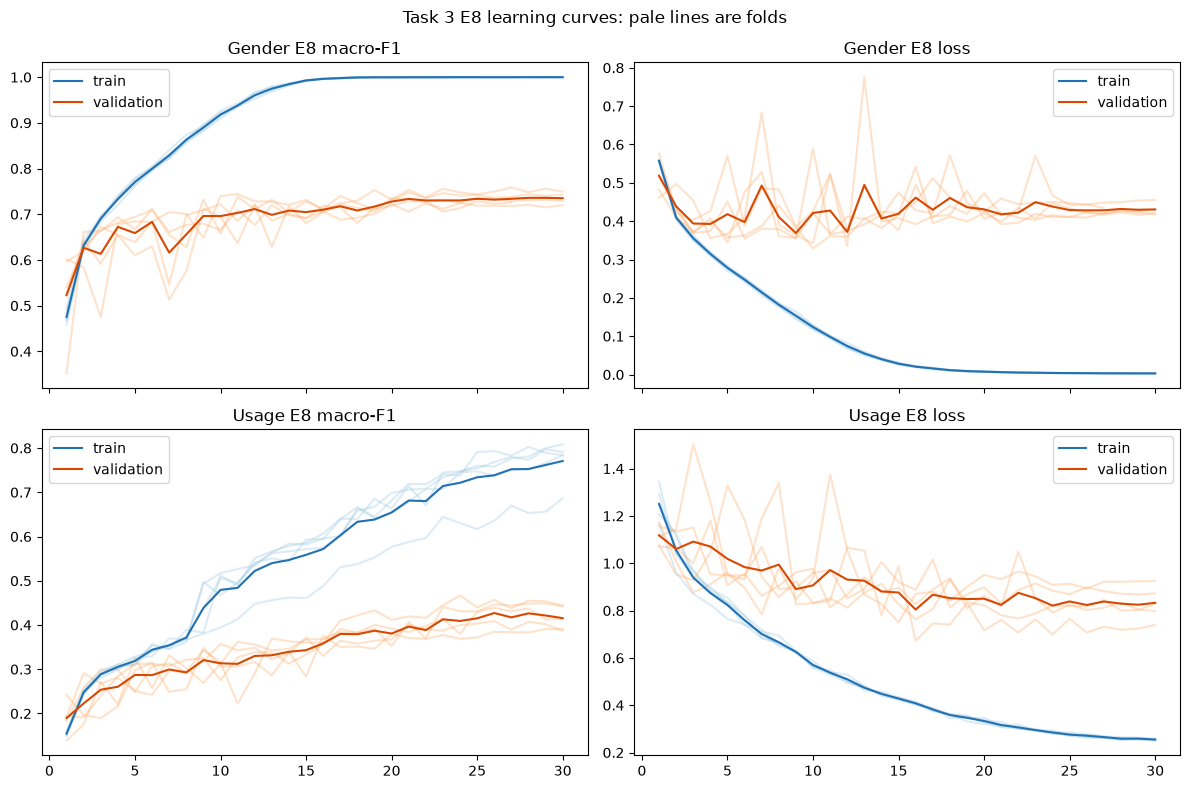

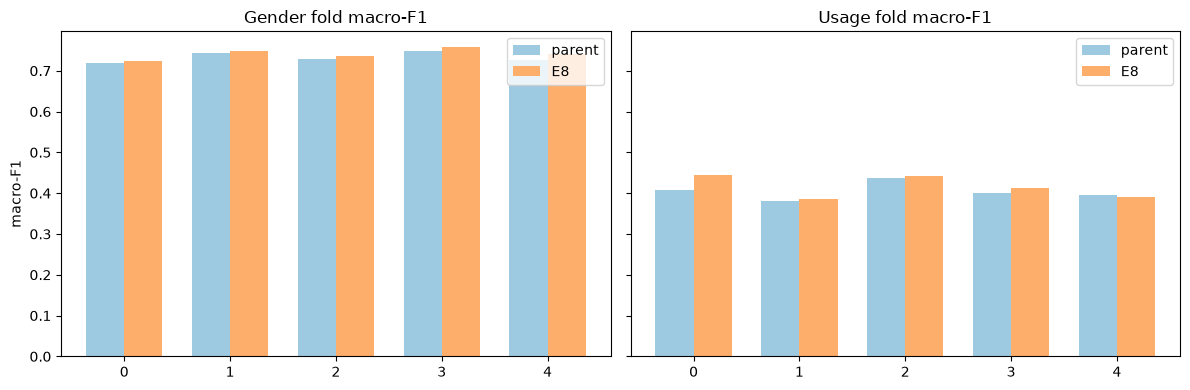

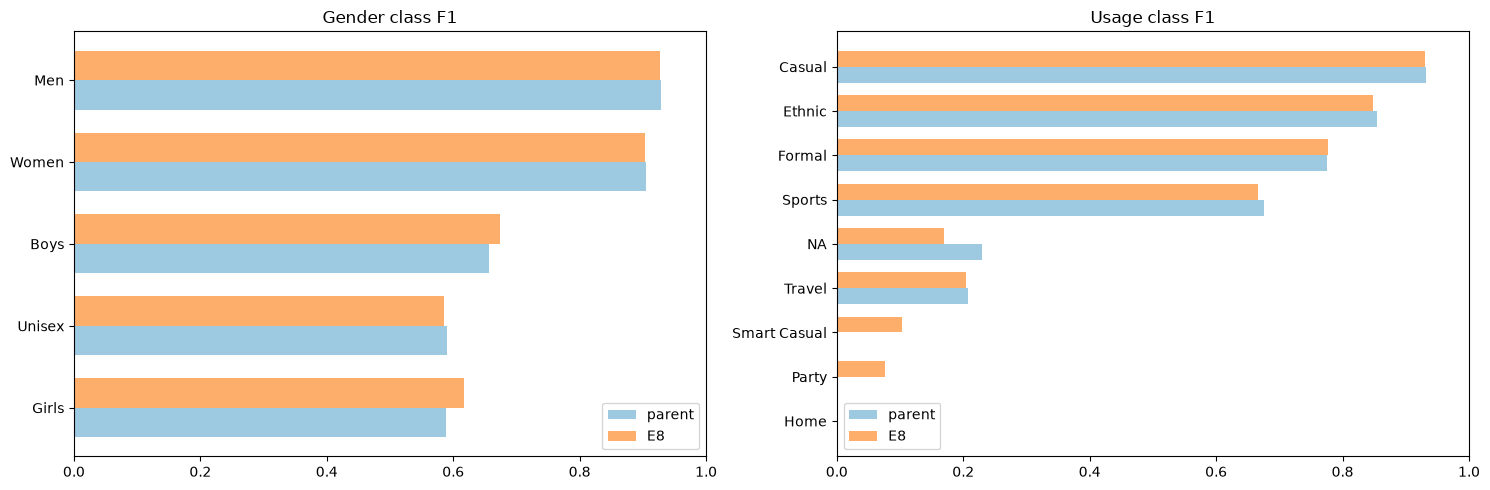

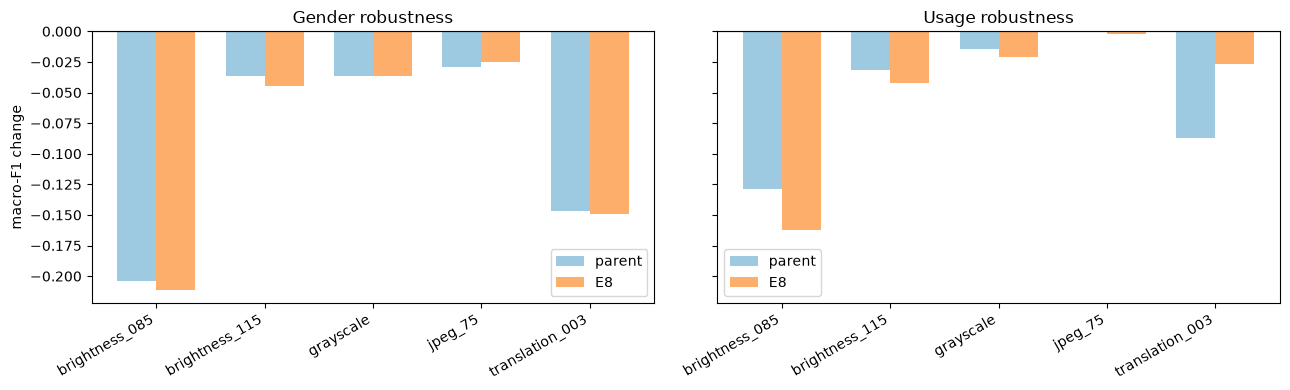

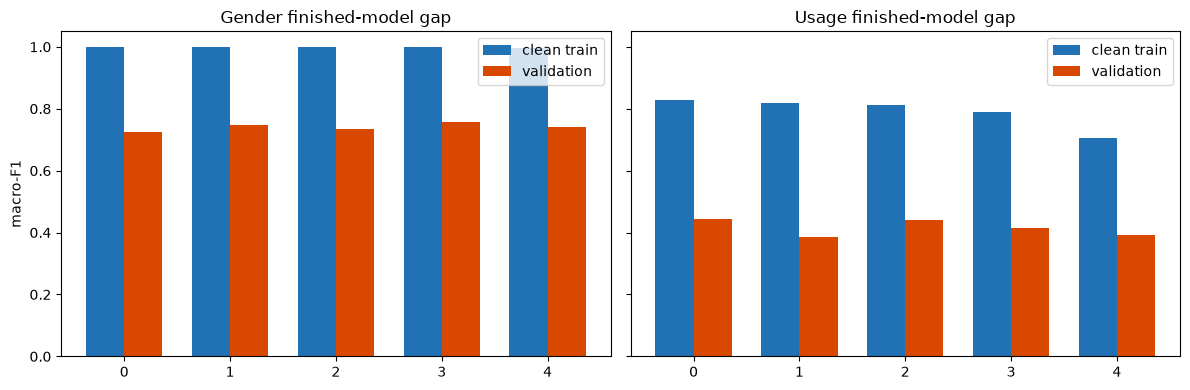

In [4]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

fig, axes = plt.subplots(2, 2, figsize=(12, 8), sharex=True)
for row, target in enumerate(("gender", "usage")):
    history = task3_e8_evidence[target]["history"]
    for _, part in history.groupby("fold"):
        axes[row, 0].plot(part["epoch"], part["train_macro_f1"], color="#9ecae1", alpha=0.35)
        axes[row, 0].plot(part["epoch"], part["validation_macro_f1"], color="#fdae6b", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["train_loss"], color="#9ecae1", alpha=0.35)
        axes[row, 1].plot(part["epoch"], part["validation_loss"], color="#fdae6b", alpha=0.35)
    mean_history = history.groupby("epoch").mean(numeric_only=True)
    axes[row, 0].plot(mean_history.index, mean_history["train_macro_f1"], color="#2171b5", label="train")
    axes[row, 0].plot(mean_history.index, mean_history["validation_macro_f1"], color="#d94801", label="validation")
    axes[row, 1].plot(mean_history.index, mean_history["train_loss"], color="#2171b5", label="train")
    axes[row, 1].plot(mean_history.index, mean_history["validation_loss"], color="#d94801", label="validation")
    axes[row, 0].set_title(f"{target.title()} E8 macro-F1")
    axes[row, 1].set_title(f"{target.title()} E8 loss")
    axes[row, 0].legend()
    axes[row, 1].legend()
fig.suptitle("Task 3 E8 learning curves: pale lines are folds")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e8_learning_curves.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e8_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_macro_f1"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e8_macro_f1"], 0.36, label="E8", color="#fdae6b")
    axis.set_xticks(x, part["fold"])
    axis.set_title(f"{target.title()} fold macro-F1")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e8_fold_macro_f1.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    report = e8_class_comparison.query("target == @target").sort_values("parent_f1")
    y = np.arange(len(report))
    axis.barh(y - 0.18, report["parent_f1"], 0.36, label="parent", color="#9ecae1")
    axis.barh(y + 0.18, report["e8_f1"], 0.36, label="E8", color="#fdae6b")
    axis.set_yticks(y, report["class_name"].astype(str))
    axis.set_xlim(0, 1)
    axis.set_title(f"{target.title()} class F1")
    axis.legend()
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e8_per_class_f1_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(13, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e8_robustness_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["parent_change"], 0.36, label="parent", color="#9ecae1")
    axis.bar(x + 0.18, part["e8_change"], 0.36, label="E8", color="#fdae6b")
    axis.axhline(0, color="black", linewidth=0.8)
    axis.set_xticks(x, part["corruption"], rotation=30, ha="right")
    axis.set_title(f"{target.title()} robustness")
    axis.legend()
axes[0].set_ylabel("macro-F1 change")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e8_robustness_comparison.png", dpi=180, bbox_inches="tight")
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(12, 4), sharey=True)
for axis, target in zip(axes, ("gender", "usage"), strict=True):
    part = e8_fold_comparison.query("target == @target")
    x = np.arange(len(part))
    axis.bar(x - 0.18, part["final_train_eval_macro_f1"], 0.36, label="clean train", color="#2171b5")
    axis.bar(x + 0.18, part["e8_macro_f1"], 0.36, label="validation", color="#d94801")
    axis.set_xticks(x, part["fold"])
    axis.set_title(f"{target.title()} finished-model gap")
    axis.legend()
axes[0].set_ylabel("macro-F1")
fig.tight_layout()
fig.savefig(FIGURE_DIR / "e8_finished_model_gap.png", dpi=180, bbox_inches="tight")
plt.show()


### E8 result: useful improvements, but neither child clears every frozen gate

| Target | Parent macro-F1 | E8 macro-F1 | Change | Paired family 95% interval | Decision |
|---|---:|---:|---:|---|---|
| Gender | E6 0.7335 | 0.7412 | +0.0077 | +0.0010 to +0.0147 | strongest Gender score; reject as finalist because the score and gap gates fail |
| Usage | E2 0.4082 | 0.4194 | +0.0112 | -0.0138 to +0.0377 | reject: improvement is not reliable and minority/no-harm gates fail |

#### Gender E8 — checkpoint choice helps, but does not cure overfitting

Restoring the best checkpoint improved all five folds over E6. The family bootstrap is fully positive, so the +0.0077 gain is reliable for this seed. Boys F1 rose by 0.0182 and Girls by 0.0279. NLL improved from 0.4325 to 0.4145, ECE-15 from 0.0642 to 0.0591, and high-confidence errors fell from 726 to 595. All robustness and cost guards passed.

The frozen finalist score was 0.7435, so 0.7412 misses it by 0.0023. More importantly, clean training macro-F1 is still about 0.998-1.000 in every fold. The mean train-validation gap only fell from 0.2666 to 0.2582, not to 0.2466. Four folds trained through epoch 30 and restored epochs 20-27; only fold 4 stopped early and restored epoch 17. Checkpoint choice removes a small avoidable loss, but the model still memorises training families. Unisex F1 also fell by 0.0046. E8 is the strongest Gender benchmark, but it is not eligible for confirmation seeds under the frozen all-gates rule.

#### Usage E8 — translation fixes alignment sensitivity, not the class problem

Translation improved four of five folds, pooled macro-F1 by 0.0112, macro-F1 without Home by 0.0126, NLL from 0.3428 to 0.3292, and ECE-15 from 0.0331 to 0.0079. The clean train-validation gap fell to 0.3750. Translation corruption improved by 0.0600 to only -0.0269, and wrong predictions at confidence at least 0.99 fell from 278 to 64. Exact catalogue alignment and overconfident memorisation were real problems.

The clean gain is not reliable across product families: the paired interval against E2 crosses zero, and the interval against E3 is -0.0239 to +0.0318. The main score misses 0.4262, and the no-Home score misses 0.4782. NA F1 fell from 0.2299 to 0.1690. The apparent rare-tail gain includes only one correct Party row and six correct Smart Casual rows. Fold 0 supplies most of the gain, fold 4 regresses, and dark-image robustness is 0.0330 worse than E2. Translation taught position tolerance, but it did not create stable rare-class boundaries or resolve conflicting labels.

#### Decision and remaining problem

Do not run confirmation seeds and do not stack E8 automatically. Keep E8 Gender as the strongest observed score but retain the frozen rejection. Keep E2 as the accepted Usage parent and E3 as the strongest earlier Usage score. The next hypotheses must target the measured causes: family-level memorisation and weak or ambiguous audience evidence for Gender; extreme support imbalance, conflicting labels, and ArticleType shortcut errors for Usage. A new architecture is justified only if it directly attacks one of those causes and is trained from scratch on the fixed folds.

![E8 learning curves](../results/figures/task3/e8_learning_curves.png)

![E8 fold comparison](../results/figures/task3/e8_fold_macro_f1.png)

![E8 class comparison](../results/figures/task3/e8_per_class_f1_comparison.png)

![E8 robustness](../results/figures/task3/e8_robustness_comparison.png)

![E8 finished-model gaps](../results/figures/task3/e8_finished_model_gap.png)


## 22. E9 pre-run audits and conditional hypotheses

E8 is still the strongest observed Gender score at 0.7412. E9 starts by reproducing the real saved evidence before defining two one-factor children. This section creates deterministic evidence and does **not** start training.

### Gender label audit before any Gender E9 run

The conservative semantic rule flags an official `Men` row only when its product name has a strong boy cue, and an official `Women` row only when it has a strong girl cue. Plural or possessive cues (`boys`, `boy's`, `girls`, `girl's`) are direct. Singular `boy` or `girl` needs a second age term such as `kids`, `child`, `baby`, `toddler`, `teen`, or `junior`. An opposite-child cue or explicit adult cue vetoes the rule. `Little` alone is not enough. The rule finds **305** development rows: 168 labelled Men and 137 labelled Women. Fold-training removals are 242, 224, 259, 263, and 232. Validation rows never change.

The automated contract stores the exact 305 IDs and hashes the rule, selected IDs, source-class distribution, validation-fold distribution, 200-family distribution, and 13-ArticleType distribution. It also checks the five training-removal counts against frozen expected values before any E9G call. No human-rating gate is used.

### Gender E9G — E6 GeM with fold-training semantic filtering

**Parent:** the exact five Gender E6 GeM `p=3` folds. The only changed factor is fold-training row selection. Remove the locked semantic-conflict rows from each training complement, fit RGB statistics on the remaining rows, and keep validation untouched. Keep the E6 architecture, ordinary cross-entropy, no augmentation, final-epoch checkpoint, 30 epochs, optimiser, schedule, seed, and folds. Product names and ArticleType never enter the model or inference path.

Prospective gates at seed 2753: pooled macro-F1 at least 0.7462; family-bootstrap lower 95% bound above zero versus E6; at least four of five folds improve and the worst fold change is at least -0.005; mean Boys/Girls F1 at least 0.6503; fewer than 179 clean child-to-adult errors versus E6's verified 229; accuracy at least 0.8862; mean finished-model gap below 0.2532; no meaningful class, corruption, or calibration regression; and peak allocation below 2 GiB. Failure to reduce the 229 clean child-to-adult errors falsifies the filter even if macro-F1 rises.

### Usage E9U — E2 with fold-training usual/exception balance

For each training complement, map every ArticleType to its usual Usage by the fixed label-map order. Ties use that same order and are reported. A training row is `usual` when its label matches the mapping and `exception` otherwise. Give the two groups mean-one factors `N/(2*n_group)`, multiply those factors by E2's effective-number class weight, and divide the summed cross-entropy by the sum of the combined weights. Keep every row. Validation and inference use images only and are unchanged.

The corrected index-safe E2 audit verifies 6.59% error on 29,394 usual rows, 48.05% on 3,359 exception rows, and the ArticleType-usual shortcut in 97.21% of 1,614 wrong exception rows. Nineteen validation rows have zero fold-training ArticleType support and remain an explicit `unsupported` diagnostic. E2 accuracy on 1,232 mixed-label-family rows is 0.6843.

Prospective gates: pooled macro-F1 at least 0.4262; macro-F1 without Home at least 0.4782; positive family-bootstrap lower 95% bounds versus both E2 and E8; at least four of five folds improve; exception error below 45.05%; usual error below 7.59%; wrong-exception shortcut below 92.21%; mixed-label-family accuracy above 0.6743; no meaningful supported-class, robustness, or calibration regression; and peak allocation below 2 GiB. `Home` remains in the official nine-class head, but its single development row can never establish success.

### Lower-priority alternative, not another run

A descriptive fold-prior logit adjustment with `tau=0.065` moves the saved E2 OOF macro-F1 only from about 0.4082 to 0.4095. It uses fold-training priors, but the strength was inspected after E2 and it changes saved probabilities rather than retraining the loss. It is therefore not equivalent to logit-adjusted cross-entropy training, is not eligible model evidence, and stays below the exception-balance run in priority.


In [ ]:
from fashion.train.task3_e9 import write_task3_e9_prerun_evidence

TASK3_E9_PRERUN_DIR = REPO_DIR / "results/evidence/task3/e9_prerun"
task3_e9_prerun = write_task3_e9_prerun_evidence(
    splits_path=REPO_DIR / "data/processed/splits.csv",
    usage_prediction_path=(
        task3_e8_parents["usage"]["aggregate_dir"] / "oof_predictions.csv"
    ),
    output_dir=TASK3_E9_PRERUN_DIR,
)

gender_fold_removals = pd.read_csv(
    TASK3_E9_PRERUN_DIR / "gender_semantic_filter/fold_training_removals.csv"
)
usage_group_summary = pd.read_csv(
    TASK3_E9_PRERUN_DIR / "usage_exception_balance/group_error_summary.csv"
)
usage_fold_contracts = pd.read_csv(
    TASK3_E9_PRERUN_DIR / "usage_exception_balance/fold_training_contracts.csv"
)
display(gender_fold_removals)
display(usage_group_summary.round(4))
display(usage_fold_contracts.round(4))
print("Optimizer steps:", task3_e9_prerun["optimizer_steps"])
print("Gender deterministic contract:", task3_e9_prerun["gender_deterministic_contract"]["verified"])
print("Human-rating gate required:", task3_e9_prerun["gender_deterministic_contract"]["human_rating_gate_required"])
print("Training started:", task3_e9_prerun["training_started"])


In [ ]:
FIGURE_DIR = REPO_DIR / "results/figures/task3"
FIGURE_DIR.mkdir(parents=True, exist_ok=True)

usage_summary = task3_e9_prerun["usage_exception_balance"]
fig, axes = plt.subplots(1, 3, figsize=(15, 4.2))

axes[0].bar(
    gender_fold_removals["validation_fold"].astype(str),
    gender_fold_removals["conflicts_removed_from_training"],
    color="#756bb1",
)
axes[0].set_title("Gender conflicts removed")
axes[0].set_xlabel("validation fold")
axes[0].set_ylabel("training rows")

usage_rates = [
    usage_summary["usual_error_rate"],
    usage_summary["exception_error_rate"],
    usage_summary["wrong_exception_shortcut_rate"],
]
axes[1].bar(["usual error", "exception error", "wrong shortcut"], usage_rates,
            color=["#6baed6", "#fd8d3c", "#e6550d"])
axes[1].set_ylim(0, 1)
axes[1].set_title("E2 fold-safe Usage audit")
axes[1].tick_params(axis="x", rotation=20)

axes[2].plot(
    usage_fold_contracts["validation_fold"],
    usage_fold_contracts["usual_group_factor"],
    marker="o",
    label="usual",
)
axes[2].plot(
    usage_fold_contracts["validation_fold"],
    usage_fold_contracts["exception_group_factor"],
    marker="o",
    label="exception",
)
axes[2].set_title("Prospective training factors")
axes[2].set_xlabel("validation fold")
axes[2].set_ylabel("group factor")
axes[2].legend()

fig.tight_layout()
fig.savefig(FIGURE_DIR / "e9_prerun_audit_summary.png", dpi=180, bbox_inches="tight")
plt.show()


def fixed_macro_f1(true_index, predicted_index, class_count):
    confusion = np.zeros((class_count, class_count), dtype=np.int64)
    np.add.at(confusion, (true_index, predicted_index), 1)
    true_positive = np.diag(confusion)
    denominator = confusion.sum(axis=0) + confusion.sum(axis=1)
    return float(np.divide(
        2 * true_positive,
        denominator,
        out=np.zeros(class_count, dtype=float),
        where=denominator > 0,
    ).mean())


usage_classes = list(label_maps["usage"]["classes"])
usage_map = {name: index for index, name in enumerate(usage_classes)}
usage_oof = pd.read_csv(
    task3_e8_parents["usage"]["aggregate_dir"] / "oof_predictions.csv",
    keep_default_na=False,
).merge(
    usage_development[["id", "usage"]], on="id", validate="one_to_one"
)
probability_columns = [
    f"probability_{index}_{name}" for index, name in enumerate(usage_classes)
]
probabilities = usage_oof[probability_columns].to_numpy(dtype=float)
adjusted_logits = np.log(np.clip(probabilities, 1e-12, 1.0))
for fold in range(5):
    fold_training = usage_development.loc[usage_development["cv_fold"].ne(fold)]
    prior = (
        fold_training["usage"].value_counts().reindex(usage_classes, fill_value=0)
        .to_numpy(dtype=float)
    )
    prior /= prior.sum()
    selected = usage_oof["cv_fold"].eq(fold).to_numpy()
    adjusted_logits[selected] -= 0.065 * np.log(np.clip(prior, 1e-12, 1.0))

true_index = usage_oof["usage"].map(usage_map).to_numpy(dtype=int)
logit_adjustment_check = pd.DataFrame([
    {
        "method": "saved E2 probabilities",
        "macro_f1": fixed_macro_f1(true_index, probabilities.argmax(axis=1), len(usage_classes)),
        "eligible_training_evidence": False,
    },
    {
        "method": "post-hoc fold-prior adjustment, tau=0.065",
        "macro_f1": fixed_macro_f1(true_index, adjusted_logits.argmax(axis=1), len(usage_classes)),
        "eligible_training_evidence": False,
    },
])
display(logit_adjustment_check.round(4))


In [ ]:
gender_contract = task3_e9_prerun["gender_deterministic_contract"]
expected_removals = {"0": 242, "1": 224, "2": 259, "3": 263, "4": 232}
if not gender_contract["verified"] or not all(gender_contract["checks"].values()):
    raise RuntimeError("The deterministic Gender audit did not verify.")
if gender_contract["conflict_rows"] != 305:
    raise RuntimeError("The deterministic Gender conflict count changed.")
if gender_contract["training_removals"] != expected_removals:
    raise RuntimeError("The deterministic Gender fold-removal counts changed.")
if gender_contract["human_rating_gate_required"]:
    raise RuntimeError("A removed human-rating gate was reintroduced.")
display(pd.DataFrame([gender_contract]).drop(columns=["checks"]))
print("Gender E9 deterministic audit: verified")
print("Training started by this notebook section: False")


### E9 pre-run result: evidence pack complete; training remains stopped

The deterministic audit reproduced 305 conservative Gender conflicts, the exact selected-ID hash, the source-class/fold/family/ArticleType distribution hashes, the five requested training-removal counts, five fold-only Usage mappings and weights, and 19 explicit zero-support cases. It also made 18 optional native-resolution qualitative sheets with protected metadata hidden. No formal ratings are required and no model has been trained.

Gender E9G is now fully prepared from the exact E6 GeM `p=3` parents. Its only changed factor is excluding those deterministic rows from each fold's training complement. Validation stays complete and official; names and ArticleType never enter the model or inference. E8 checkpoint selection is not added.

Usage E9U is also fully specified. Notebook `04i_task3_semantic_filter_exception_balance_e9_experiments.ipynb` resolves the exact saved E6 and E2 parent IDs, reproduces the automated contracts, runs no earlier experiment, and trains only Usage E9U then Gender E9G when the user later runs it.

![E9 pre-run audits](../results/figures/task3/e9_prerun_audit_summary.png)


## 23. Sequential experiment and decision ledger

This table grows one approved row at a time. Do not fill a model matrix in advance.

| Hypothesis | Target | Parent run IDs | One changed factor | Child run IDs | Evidence bundle | Decision | Accepted parent |
|---|---|---|---|---|---|---|---|
| Baseline contract | gender | none | primary small CNN | five completed folds | `task3/baseline/gender` | accept as reference, not final | E1 gender |
| Baseline contract | usage | none | primary small CNN | five completed folds | `task3/baseline/usage` | accept as reference, not final | E1 usage |
| E2 brightness | gender | E1 gender fold IDs | brightness augmentation only | five completed registered folds | `task3/experiments/t3_gender_e2_brightness/gender` | reject: macro-F1 fell 0.0129 | E1 gender |
| E2 class-balanced CE | usage | E1 usage fold IDs | loss weights only | five completed registered folds | `task3/experiments/t3_usage_e2_class_balanced_ce/usage` | accept: both frozen gates passed | E2 usage |
| E3 class-balanced CE | gender | E1 gender fold IDs | loss weights only | five completed registered folds | `task3/experiments/t3_gender_e3_class_balanced_ce/gender` | reject: primary and paired gates failed | E1 gender |
| E3 classifier dropout | usage | E2 usage fold IDs | dropout `p=0.20` only | five completed registered folds | `task3/experiments/t3_usage_e3_classifier_dropout/usage` | reject: close, but primary and paired gates failed | E2 usage |
| E4 TinyResNet-18-PM | gender | E1 gender fold IDs | architecture only | five completed registered folds | `task3/experiments/t3_gender_e4_tinyresnet18_pm/gender` | reject: negligible uncertain gain plus calibration, translation, and cost failures | E1 gender |
| E5 CompactBlurCNN | gender | E1 gender fold IDs | compact anti-aliased architecture only | five completed folds | `task3/experiments/t3_gender_e5_compact_blur_cnn/gender` | reject: gap and efficiency improved, but primary, paired, minority, and robustness gates failed | E1 gender |
| E5 label smoothing | usage | E2 usage fold IDs | `epsilon=0.05` label smoothing only | five completed folds | `task3/experiments/t3_usage_e5_label_smoothing/usage` | reject: extreme confidence improved, but primary, paired, fold, and minority gates failed | E2 usage |
| E6 fixed GeM `p=3` | gender | E1 gender fold IDs | global pooling only | five completed registered folds | `task3/experiments/t3_gender_e6_gem_p3/gender` | strongest performance benchmark; predictive gates pass, frozen memory guard fails | E1 gender |
| E6 focal `gamma=1` | usage | E2 usage fold IDs | focal modulation only | five completed registered folds | `task3/experiments/t3_usage_e6_focal_gamma1/usage` | reject: primary, paired, fold-count, and dark-image robustness gates fail | E2 usage |
| E7 TinyHRNet-20 | gender | E1 gender fold IDs | multi-resolution architecture only | five completed registered folds | `task3/experiments/t3_gender_e7_tinyhrnet20/gender` | reject: worse pooled, paired, fold, minority, calibration, gap, and robustness evidence; architecture lane closed | E1 gender |
| E7 TinyConvNeXt-18 | usage | E2 usage fold IDs | large-kernel architecture only | five completed registered folds | `task3/experiments/t3_usage_e7_tinyconvnext18/usage` | reject: underfit, lost all folds, and missed time and memory gates | E2 usage |
| E8G best-checkpoint early stopping | gender | E6 gender fold IDs | checkpoint-selection policy only | five completed registered folds | `task3/experiments/t3_gender_e8_early_stopping/gender` | strongest observed score, but reject as finalist: macro-F1 and gap gates fail | E6 gender performance benchmark |
| E8U two-pixel translation | usage | E2 usage fold IDs | training-only translation augmentation | five completed registered folds | `task3/experiments/t3_usage_e8_translation/usage` | reject: paired, primary, NA, and dark-image no-harm gates fail | E2 usage |
| E9G semantic filter | gender | exact E6 Gender fold IDs | fold-training row selection only | not run | `task3/e9_prerun/gender_semantic_filter` and deterministic contract | predeclared; automated audit verified | E6 Gender performance benchmark |
| E9U exception balance | usage | exact E2 Usage fold IDs | fold-training group weights only | not run | `task3/e9_prerun/usage_exception_balance` | predeclared; run Usage first | E2 usage |

Decision values are `accept`, `reject`, or `stop`. A rejected child's change is not stacked
into the next run. Every number shown here must be generated from registered artifacts.


## 24. Conditional sharing and pretrained comparison

A shared two-head model is not automatic. Open it only when accepted separate parents exist,
their combined measured cost fails a named limit, a matched common backbone is possible, and the
one-point no-harm margin is frozen first. Compare negative transfer separately for gender and
usage. Sharing changes only the task structure.

One ImageNet-pretrained ResNet-18 benchmark may run only after eligible selection is fixed. Mark
`scratch=false` and every submission, official-prediction, and application eligibility field
false. It cannot become a parent or change the eligible winner.


## 25. Implementation order and run registry

The reusable baseline path is now implemented in `src/fashion/train/`:

1. `registry.py` appends one durable row before the first optimiser step and preserves failures;
2. `data.py` enforces the saved folds, target mask, fold-only RGB statistics, and corruptions;
3. `model.py` contains the exact scratch SmallCNN, TinyHRNet, and TinyConvNeXt variants;
4. `metrics.py` keeps the fixed class order, including zero-support classes;
5. `task3_baseline.py` writes curves, OOF predictions, per-class metrics, confusion, failures,
   core robustness, checkpoint, runtime, and cost artifacts;
6. `augmentation.py` contains the rejected brightness-only E2 transform;
7. `loss.py` implements true-class-weighted label smoothing, focal loss, and E9 combined sample weights;
8. `task3_e9.py` owns the deterministic semantic rule, exact selected-ID and distribution checks, fold-only Usage groups, and optional qualitative sheets;
9. `task3_experiments.py` locks child lineage and audits five complete hashed registry rows.

`04a_task3_smallcnn_baseline_training.ipynb` reproduces only the SmallCNN baseline.
`04b_task3_smallcnn_child_experiments.ipynb` loads those saved parents and trains only E2.
`04c_task3_smallcnn_e3_experiments.ipynb` loads the accepted E1/E2 parents and trains only E3.
`04d_task3_tinyresnet18_pm_e4_experiments.ipynb` loads the same accepted parents and trains only E4.
`04e_task3_compactblurcnn_label_smoothing_e5_experiments.ipynb` loads E1/E2 and trains only E5.
`04f_task3_gem_focal_e6_experiments.ipynb` loads E1/E2 and trains only the two E6 children.
`04g_task3_tinyconvnext_tinyhrnet_e7_experiments.ipynb` trains Usage TinyConvNeXt first, then
Gender TinyHRNet, and never retrains E1–E6.
`04h_task3_early_stopping_translation_e8_experiments.ipynb` trains only Gender E8G and Usage E8U.
`04i_task3_semantic_filter_exception_balance_e9_experiments.ipynb` trains only E9: Usage E9U first, then Gender E9G after the deterministic contract check.
This main notebook reads artifacts and builds audits; it does not start training.
Both five-fold runners reject partial fold lists. Lower bounds and the classical
reference remain separate comparison stages and do not alter this primary CNN configuration.

Every Colab training execution appends through `fashion.train.registry` to the persistent Drive
`task3/results/runs.csv` before its first optimiser step, then mirrors it into the runtime clone.
The E6-E8 notebooks audit the five final rows and their hashes after each target. Cells do not
contain a second training implementation.


## 26. Finalist judgement and decision log

Confirm only the accepted final parent for each target, plus a shared candidate only if its cost
gate opened and it passed. Use all five folds and three fixed seeds with every method choice frozen.

| Final decision | Accepted chain | Rejected children and reasons | Seed evidence | Class/failure evidence | Robustness/cost | Limitation | Date/owner |
|---|---|---|---|---|---|---|---|
| Gender | TODO | TODO | TODO | TODO | TODO | TODO | TODO |
| Usage | TODO | TODO | TODO | TODO | TODO | TODO | TODO |
| Separate or shared system | TODO | TODO | TODO | TODO | TODO | TODO | TODO |

Do not rewrite earlier decisions after holdout access.


## 27. Handoff to final evaluation

Before Notebook 06, provide:

- accepted parent-child chain and rejected hypotheses: TODO(owner)
- frozen winning eligible run ID(s): TODO(owner)
- frozen preprocessing, model, loss, optimiser, schedule, and seed rules: TODO(owner)
- frozen metrics, thresholds, and five-fold/three-seed evidence: TODO(owner)
- final all-development scratch-refit procedure: TODO(owner)
- expected checkpoint, calibration, registry, and official-output paths: TODO(owner)
- shared-model gate result or recorded reason it was not opened: TODO(owner)
- unresolved risks, weak classes, and honest limitations: TODO(owner)

**Handoff status: NOT READY — owner must complete every item above.**
